# Entraîner un réseau de neurones artificiels (partie 2)

CSI 4106 - automne 2026

Marcel Turcotte  
Version: août 9, 2026 12h46

# Préambule

## Message du Jour

![](https://media.nature.com/lw767/magazine-assets/d41586-025-03135-z/d41586-025-03135-z_51543916.jpg?as=webp)

[‘Am I redundant?’: how AI changed my career in
bioinformatics](https://www.nature.com/articles/d41586-025-03135-z),
Nature News, 2025-10-13.

Bien que relativement peu d’étudiants envisagent une carrière dans la
recherche, particulièrement en bioinformatique, l’article communique
efficacement plusieurs messages clés. Il est intéressant de noter que
même les titulaires d’un doctorat peuvent se sentir menacés par
l’avènement de l’intelligence artificielle. L’article illustre en outre
comment l’IA ne supprime pas les emplois, mais les transforme. Dans de
nombreux domaines, cette transformation redéfinit les rôles vers ceux de
supervision.

## Résultats d’apprentissage

- **Algorithme de Rétropropagation** :
  - **Discuter** des passes avant et arrière, en soulignant le calcul
    des gradients à l’aide de dérivées partielles pour mettre à jour les
    poids.
- **Problème de Gradient Évanescent** :
  - **Exposer** le problème et présenter des stratégies d’atténuation,
    telles que l’utilisation de fonctions d’activation comme ReLU ou
    l’initialisation des poids avec une attention particulière.

Lors du dernier cours, nous avons mis en œuvre un réseau neuronal à
propagation avant pour illustrer son fonctionnement. Pour isoler notre
compréhension conceptuelle des réseaux neuronaux de leurs méthodes
d’entraînement, nous avons utilisé un algorithme d’entraînement de base
par force brute. Aujourd’hui, nous nous concentrerons sur l’algorithme
de rétropropagation, un élément essentiel dans les techniques
d’apprentissage profond.

# Rétropropagation

------------------------------------------------------------------------

![](https://imgs.xkcd.com/comics/machine_learning_2x.png)

**Attribution :** [xkcd.com/1838](https://xkcd.com/1838)

## Rétropropagation

**Apprentissage de représentations par rétropropagation des erreurs**

*David E. Rumelhart, <u>Geoffrey E. Hinton</u> & Ronald J. Williams*

Nous décrivons une nouvelle procédure d’apprentissage, la
rétropropagation, pour les réseaux d’unités semblables à des neurones.
La procédure **ajuste à plusieurs reprises les poids** des connexions
dans le réseau afin de **minimiser une mesure de la différence entre le
vecteur de sortie réel du réseau et le vecteur de sortie souhaité**. En
conséquence des ajustements de poids, les unités internes ‘**cachées**’
qui ne font pas partie de l’entrée ou de la sortie en viennent à
**représenter des attributs importants du domaine de la tâche**, et les
régularités de la tâche sont capturées par les interactions de ces
unités. La **capacité à créer de nouveaux attributs utiles** distingue
la rétropropagation des méthodes antérieures, plus simples, telles que
la procédure de convergence du perceptron.

Rumelhart et al. (1986); Texte traduit de l’anglais ci-dessus par
ChatGPT.

Je présente ici le résumé de la publication fondatrice de Nature où
Hinton et ses collègues ont introduit l’algorithme de rétropropagation.
Ce résumé est à la fois élégant et informatif, capturant efficacement
les principes fondamentaux des réseaux de neurones modernes : le concept
de fonction de perte, l’ajustement itératif des poids via l’algorithme
de descente de gradient, et le rôle crucial des couches cachées dans la
génération d’attributs utiles dépendantes des tâches.

Nature est une revue prestigieuse, et elle publie rarement du contenu
lié à l’informatique.

Au moment de cette publication, Hinton était affilié à l’Université
Carnegie Mellon. Pour rappel, Hinton a reçu le prix Nobel de physique en
2024 pour ses contributions au développement des méthodes fondamentales
de l’apprentissage automatique moderne.

Le résumé souligne la raison d’être des couches cachées dans les réseaux
de neurones. Les couches cachées initiales apprennent des
représentations simples directement à partir des données d’entrée,
tandis que les couches suivantes identifient des associations parmi ces
représentations. Chaque couche s’appuie sur la connaissance des couches
précédentes, culminant dans la sortie finale du réseau.

## Avant la rétropropagation

- Des limitations, telles que **l’incapacité à résoudre la tâche de
  classification XOR**, ont essentiellement **stoppé** la recherche sur
  les réseaux neuronaux.

- Le perceptron était **limité à une seule couche**, et il n’existait
  **aucune méthode connue pour entraîner un perceptron multi-couches**.

- Les perceptrons à une seule couche sont limités à résoudre des tâches
  de classification qui sont **linéairement séparables**.

## Rétropropagation : contributions

- Le modèle utilise **l’erreur quadratique moyenne** comme **fonction de
  perte**.

- La **descente de gradient** est utilisée pour minimiser la **perte**.

- Une **fonction d’activation sigmoïde** est utilisée au lieu d’une
  fonction de seuil, car sa **dérivée** fournit des informations
  précieuses pour la descente de gradient.

- Montre comment mettre à jour les **poids internes** en utilisant un
  algorithme en **deux passes** consistant en une passe **avant** et une
  passe **arrière**.

- **Permet l’entraînement des perceptrons multi-couches.**

## Idée Conceptuelle

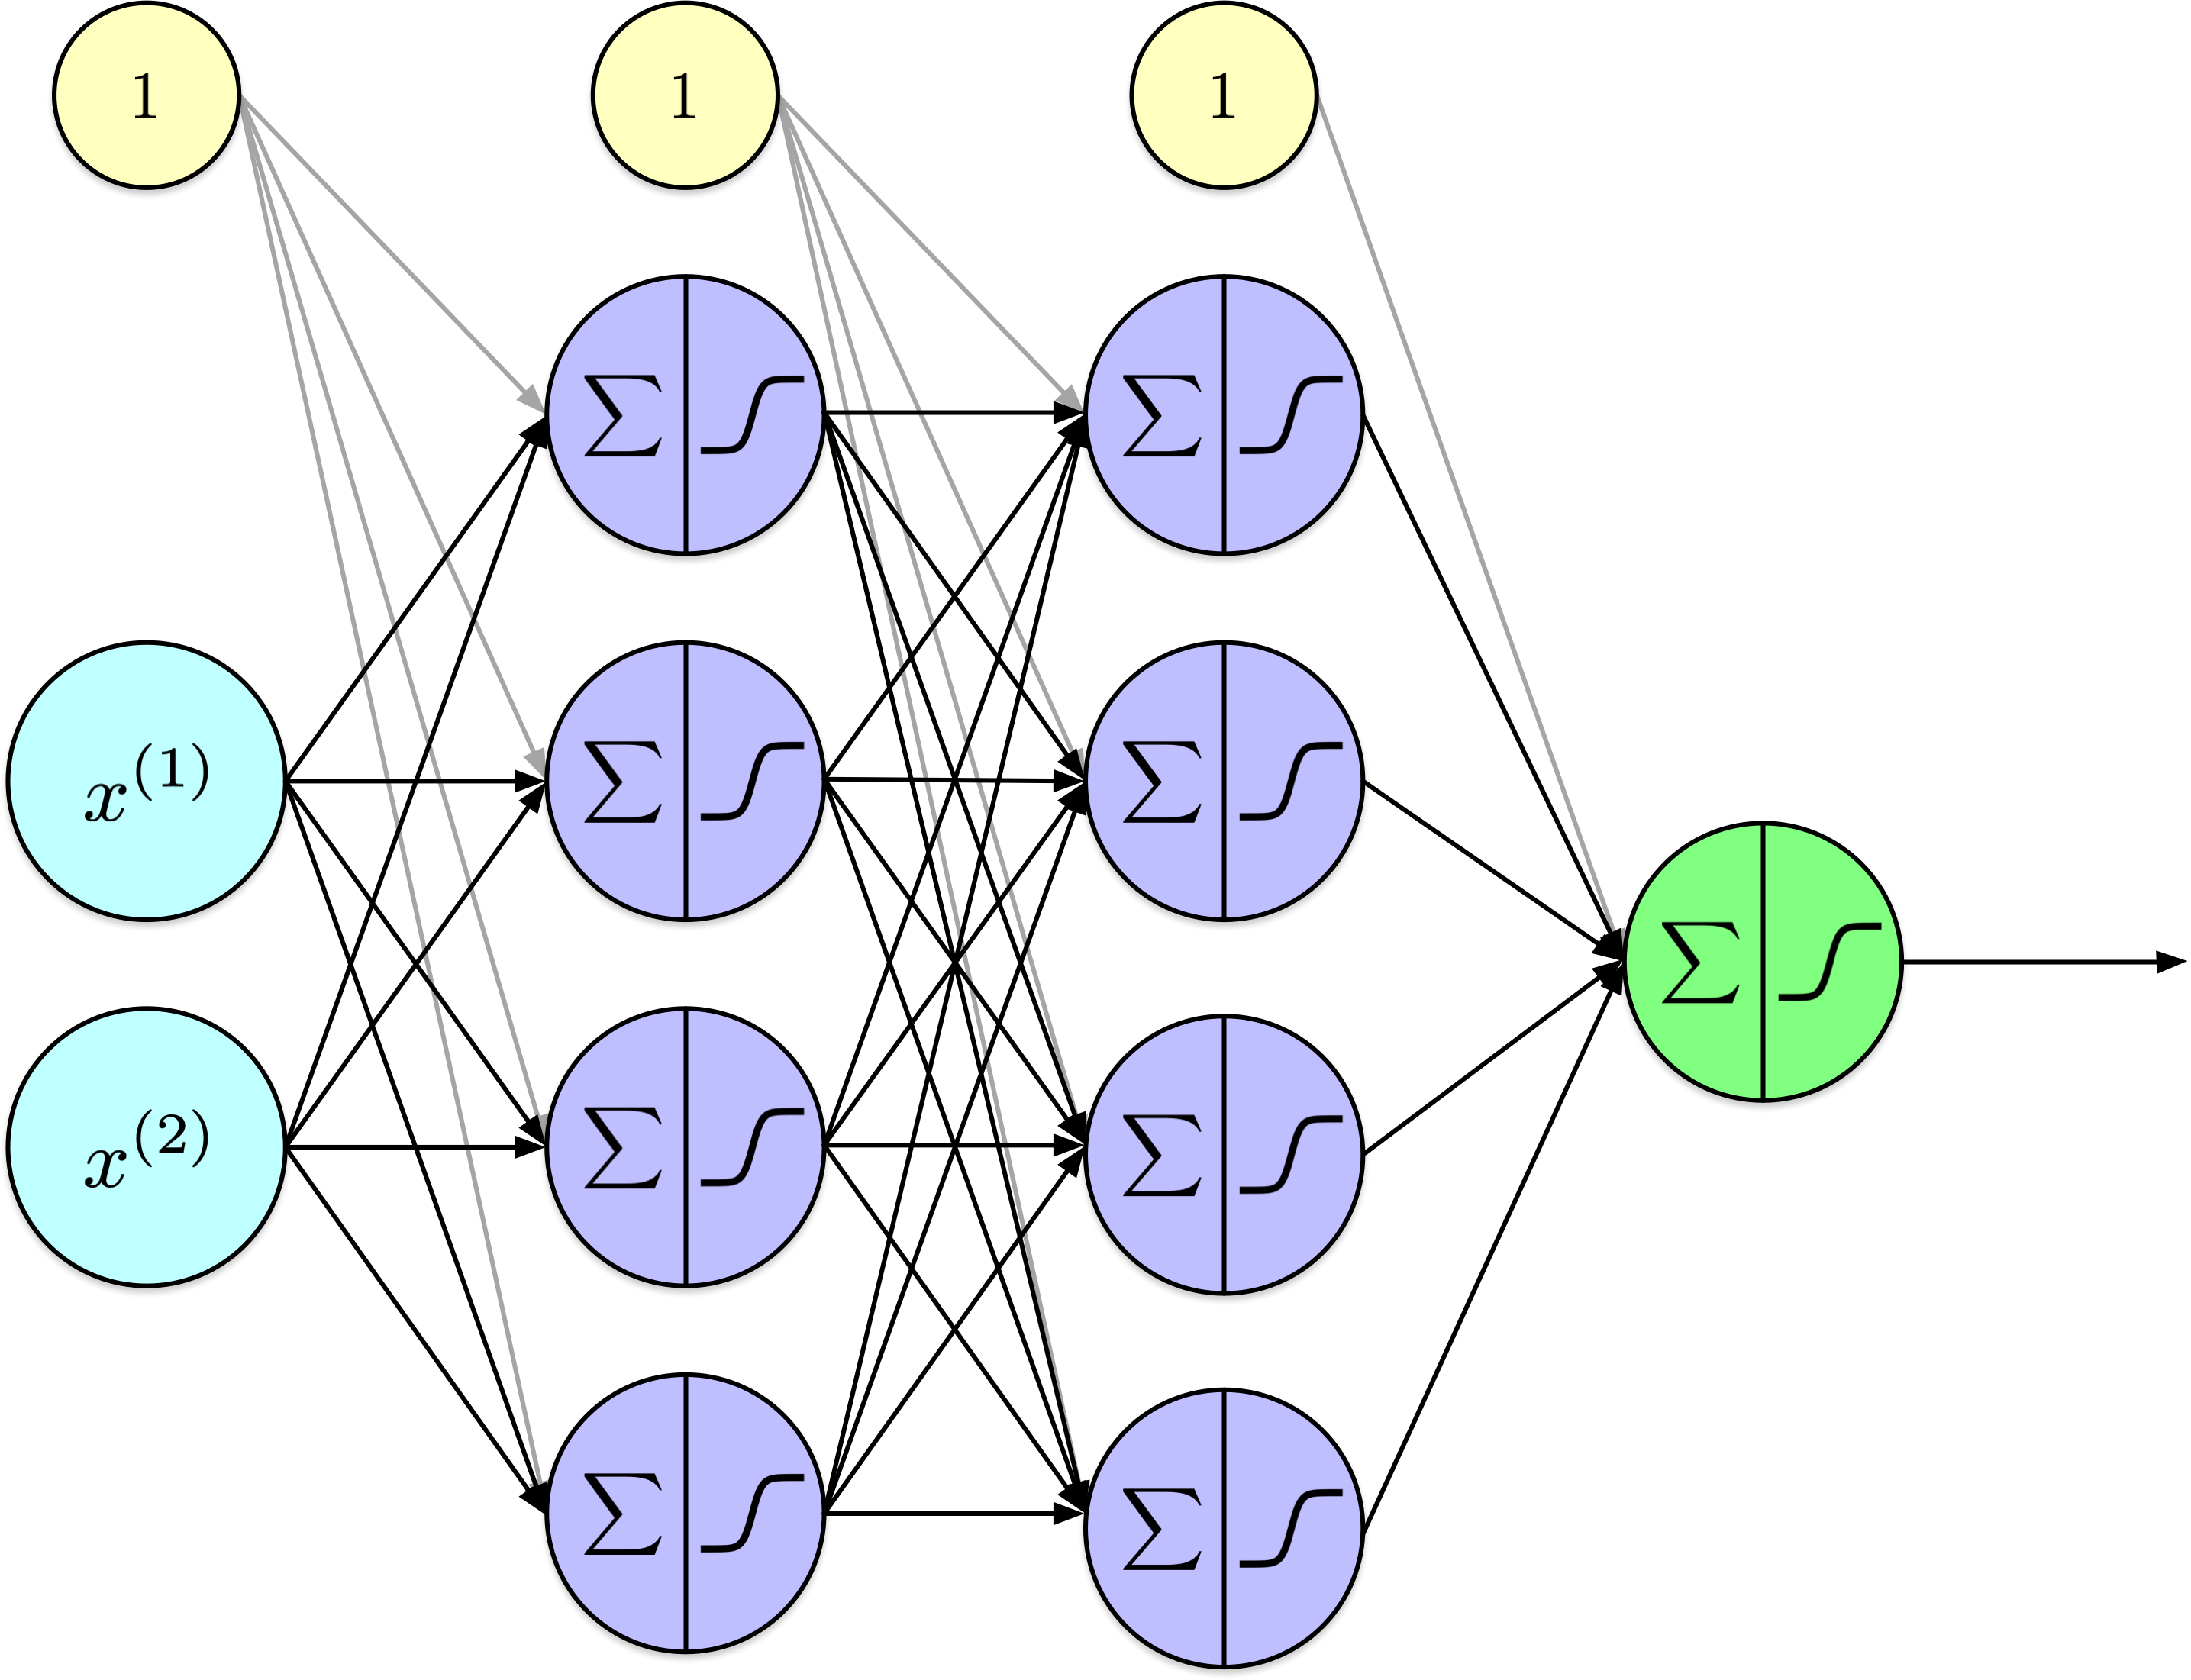

$J(\theta) = - \sum_{i=1}^{N} \left[ y_i \log \hat{y_i} + (1-y_i) \log (1 - \hat{y_i}) \right]$

Étant donné un réseau et des paramètres qui ont été initialisés
aléatoirement, nous pouvons générer des prédictions ($\hat{y_i}$) ;
cependant, pour toute tâche non triviale, ces prédictions initiales sont
susceptibles d’être inexactes en raison de la nature aléatoire de
l’initialisation des paramètres.

Dans le contexte d’un problème de classification binaire, quel niveau
d’exactitude (*accuracy*) pourrait-on anticiper ?

Correctement, on s’attendrait à une exactitude (*accuracy*) d’environ 50
%, en supposant que le jeu de données est équilibré.

Pour évaluer les performances du modèle, nous utilisons une fonction de
perte, ici l’entropie croisée binaire (également connue sous le nom de
vraisemblance logarithmique négative). Cette fonction de perte agrège la
perte sur l’ensemble des exemples d’entraînement, avec le terme
intérieur de la somme calculant la perte pour chaque exemple individuel.

Dans le calcul de la perte,
$\hat{y_i} = h(x_i) = \phi_k( \ldots \phi_2(\phi_1(x)) \ldots )$, où
$\phi_l(Z) = \phi(W_lZ_l + b_l)$ et $\phi$ sans indice est la fonction
d’activation, sigmoïde, ReLU, etc.

## Idée Conceptuelle (suite)

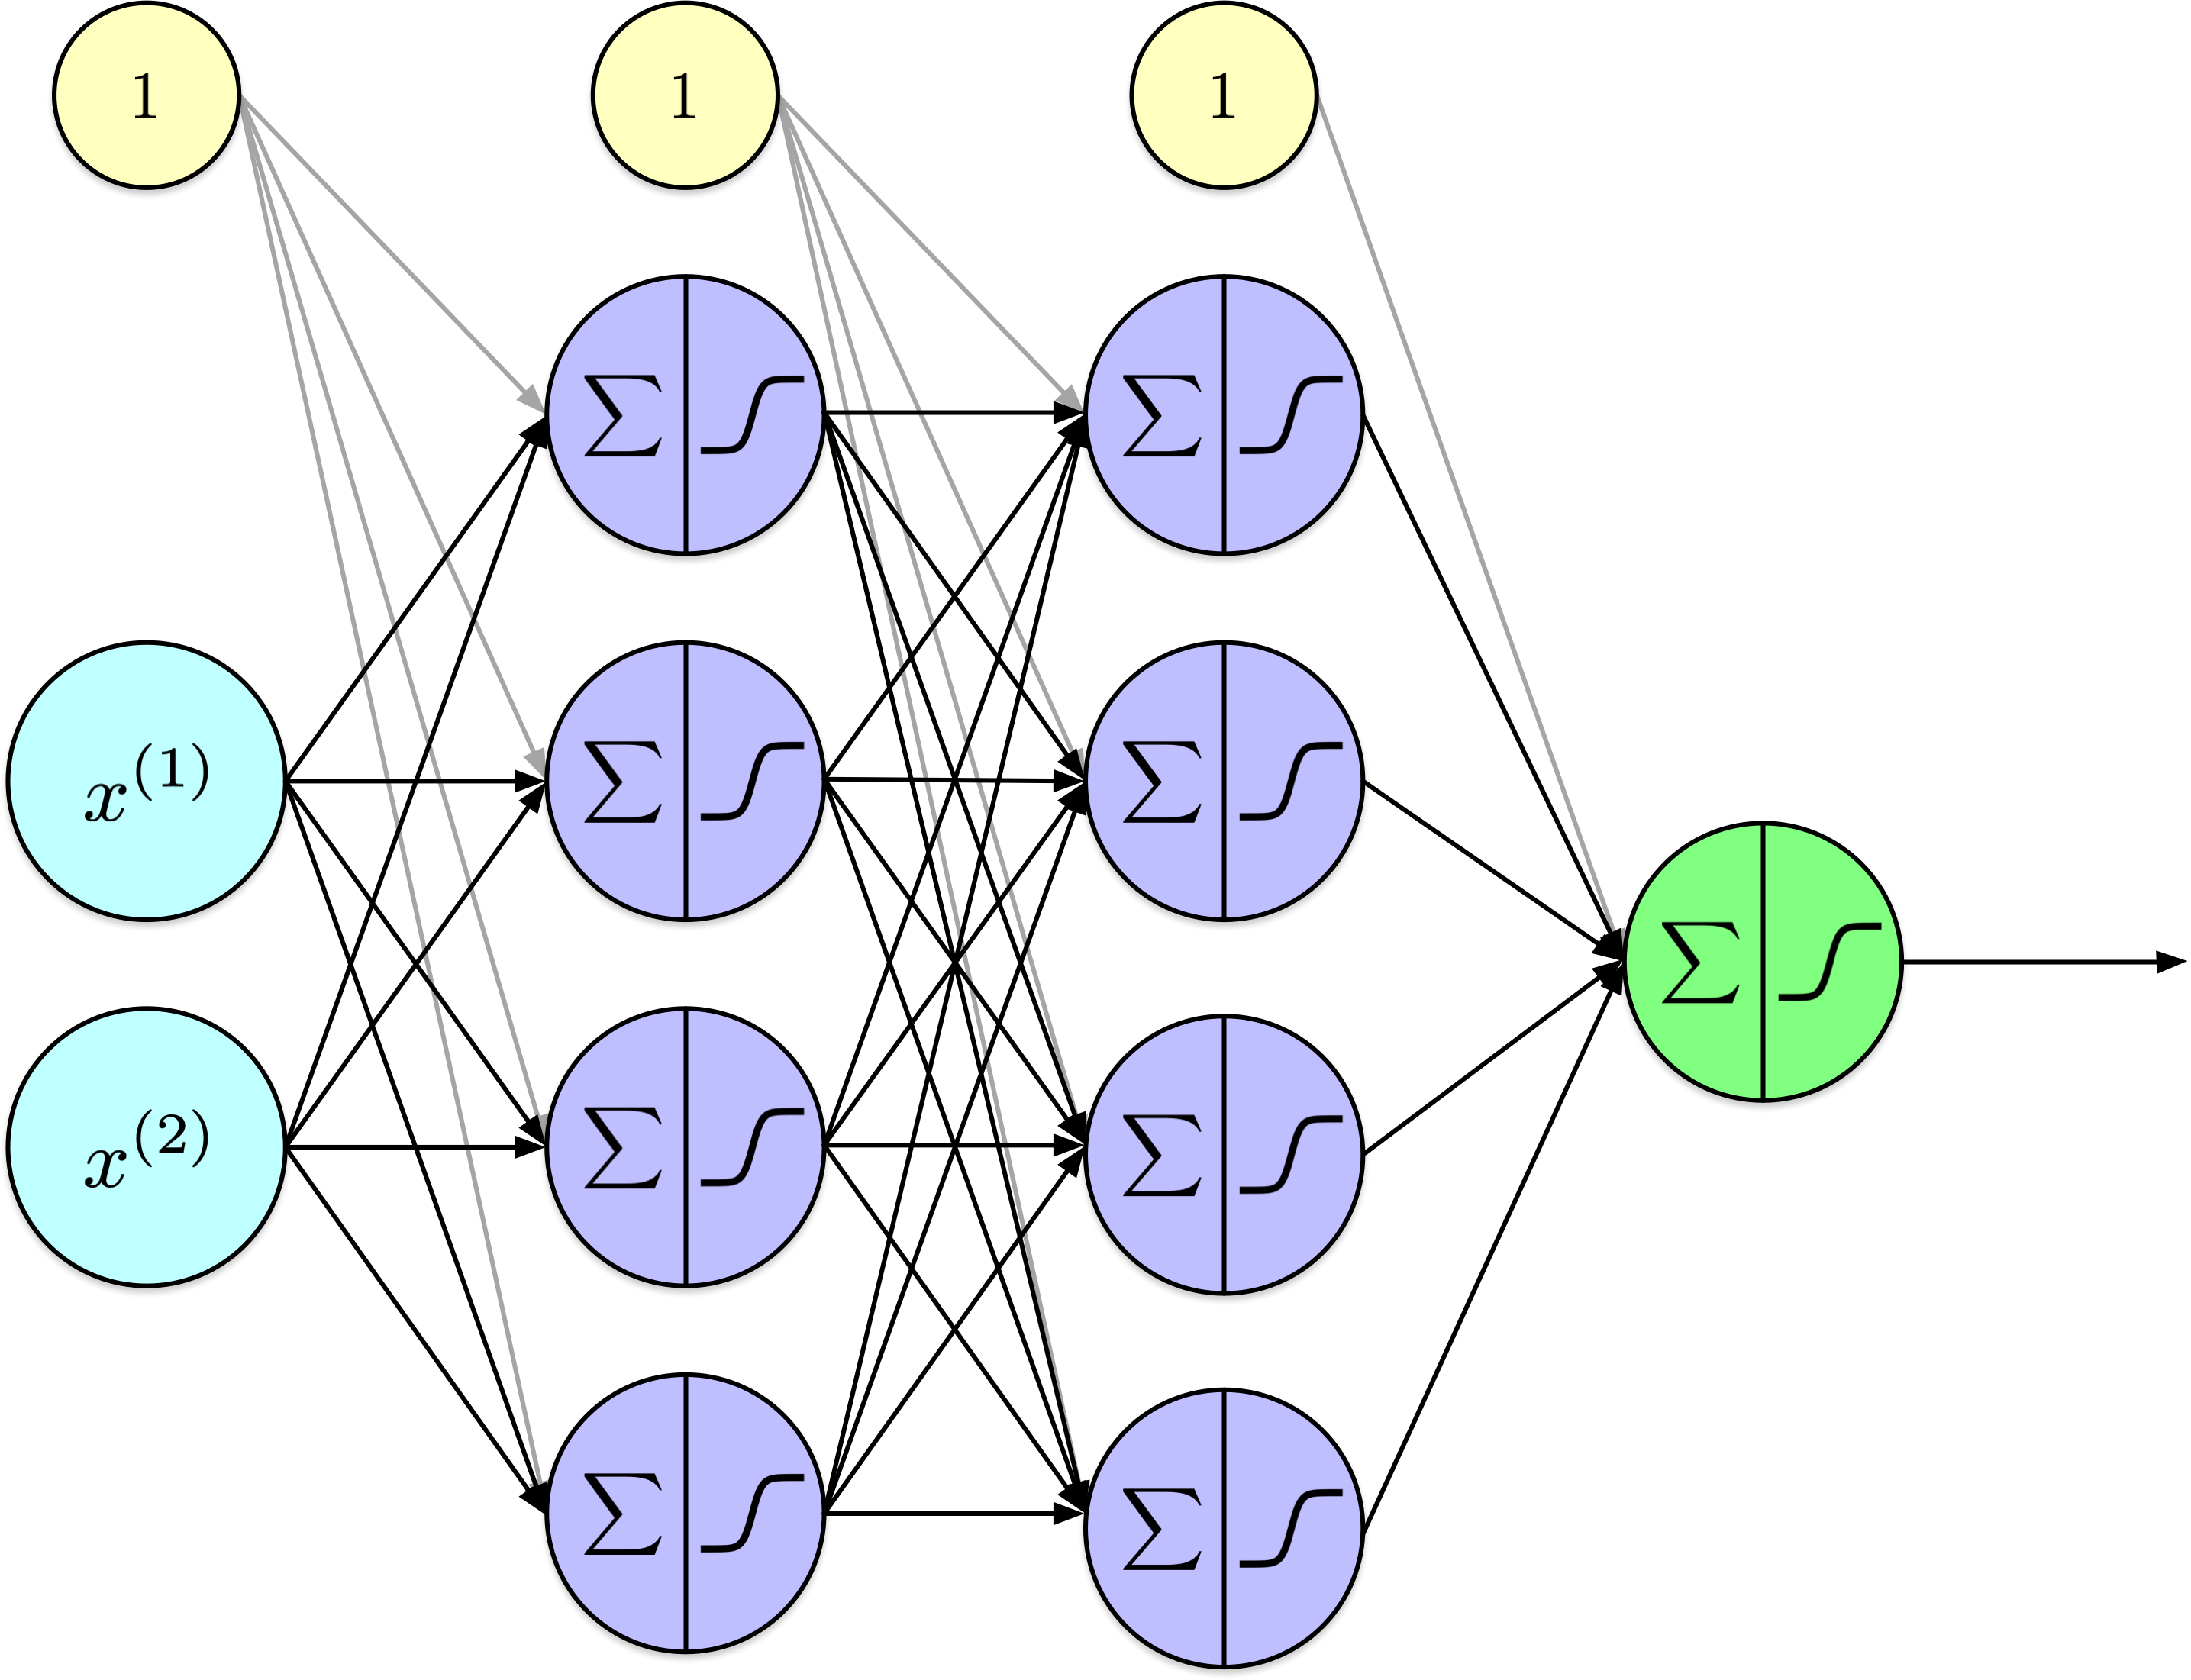

$\frac {\partial}{\partial \theta_k}J(\theta)$, pour tout $k$, où les
$\theta_k$ sont `W[l][i,j]` et `b[l][j]`.

Dans cette notation, l’indice `l` désigne les couches de traitement au
sein du modèle. L’indice `i` se réfère aux unités individuelles au sein
de la couche précédente, notée `l-1`, tandis que l’indice `j` correspond
aux unités au sein de la couche actuelle `l`.

Combien de paramètres sont présents dans le modèle ?

Le modèle se compose de trois matrices de poids. Les dimensions de ces
matrices sont $2 \times 4$, $4 \times 4$, et $4 \times 1$, contenant
respectivement 8, 16 et 4 poids. Cela donne un total de 28 paramètres de
poids.

De plus, il y a trois tableaux pour les termes de biais, contenant
respectivement 4, 4 et 1 biais, ce qui fait un total de 9 paramètres de
biais.

En tout, le modèle comprend 37 paramètres, ce qui est relativement petit
en comparaison avec des modèles plus complexes. Par exemple, le modèle
Keras discuté dans le cours précédent avait 266,610 paramètres. Dans
l’apprentissage automatique contemporain, il n’est pas rare que les
modèles contiennent des millions voire des milliards de paramètres.

## Idée Conceptuelle (suite)

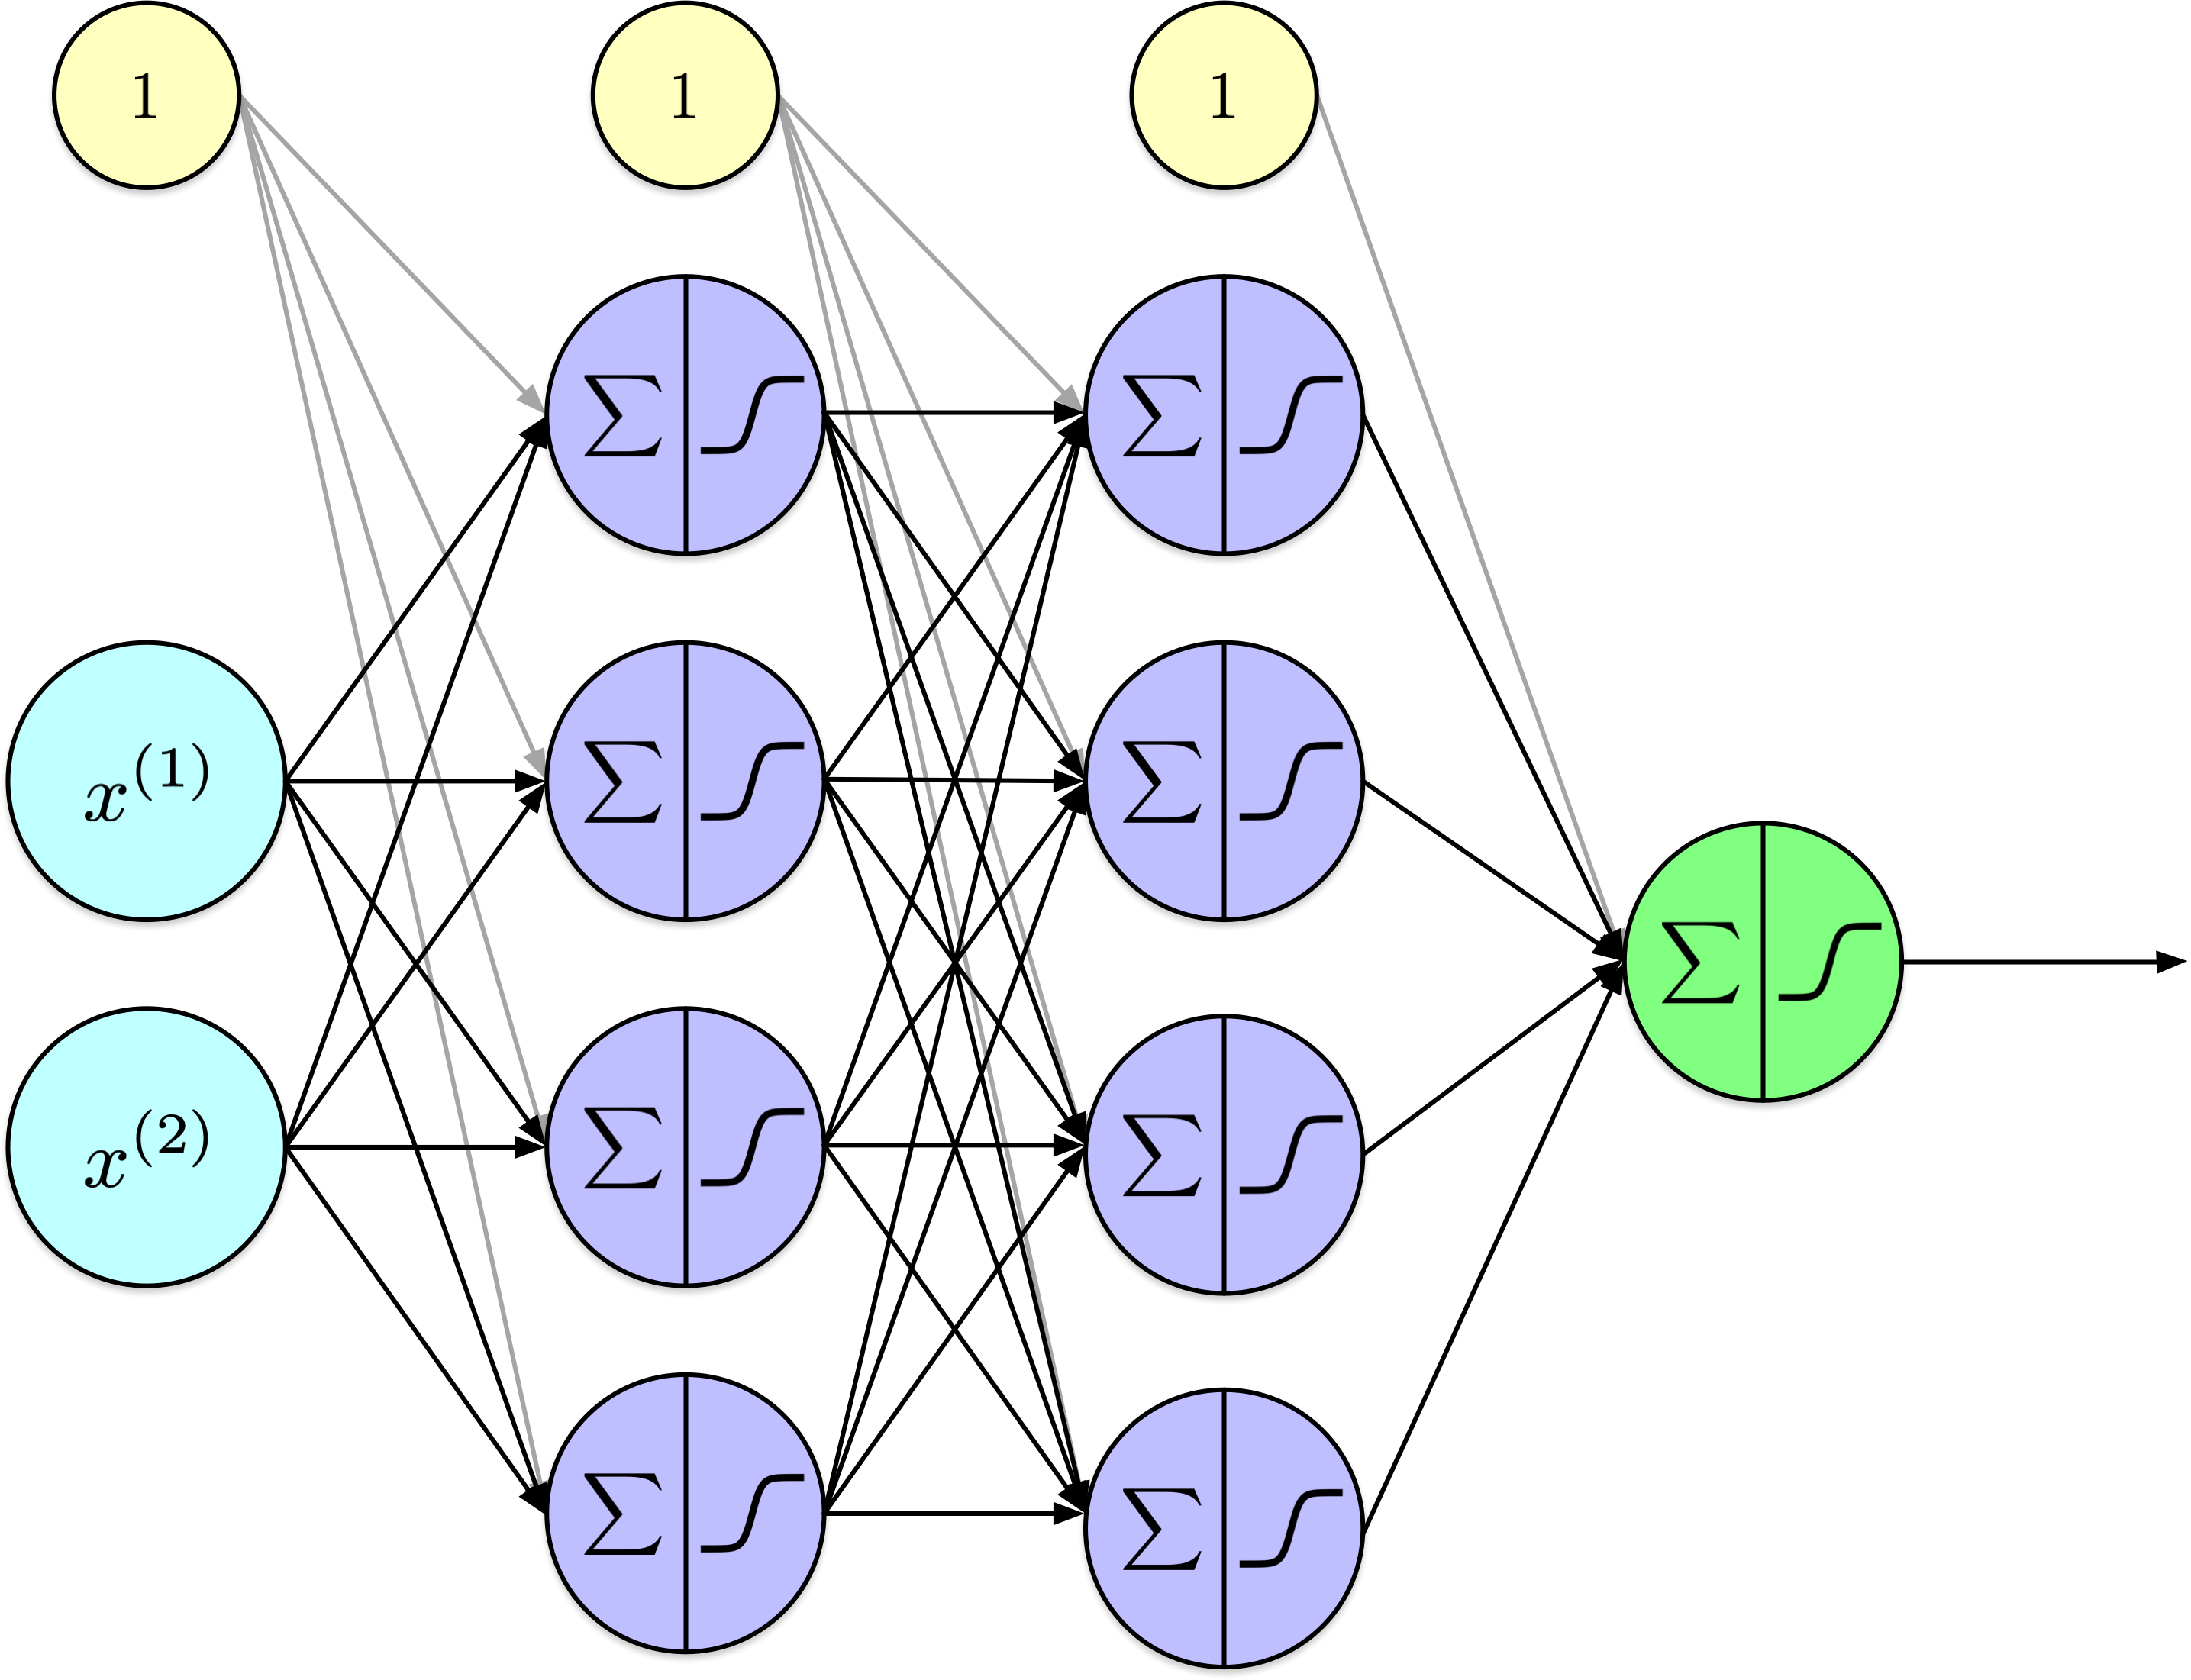

Pour un nombre fixe d’époques :
$\theta = \theta - \alpha \nabla_\theta J(\theta)$

Des critères d’arrêt alternatifs sont fréquemment utilisés dans les
algorithmes d’apprentissage. Par exemple, le processus peut s’arrêter
une fois que la perte d’apprentissage atteint un seuil suffisamment bas
ou lorsque la perte de validation a augmenté sur un nombre prédéfini
d’époques.

Les paramètres du modèle sont mis à jour simultanément, et ces mises à
jour peuvent être calculées efficacement en parallèle.

Ce processus est connu sous le nom de descente de gradient. Comme
discuté précédemment, lorsque les mises à jour des paramètres sont
effectuées en utilisant l’ensemble du jeu de données, la méthode est
appelée **descente de gradient par lot**. À l’inverse, lorsque les mises
à jour sont faites en utilisant un seul exemple d’apprentissage, cela
est appelé **descente de gradient stochastique**. Enfin, lorsqu’un petit
sous-ensemble d’exemples, connu sous le nom de lot (mini-batch), est
utilisé pour les mises à jour des paramètres, la méthode est appelée
**descente de gradient par mini-lots**.

Notre tâche actuelle consiste à déterminer les dérivées partielles de la
fonction de perte par rapport à chacun des 37 paramètres de notre
modèle.

## Rétropropagation

- **Rétropropagation** (*backprop*) est un algorithme pour **calculer
  méthodiquement** les **dérivées partielles** de la fonction de perte
  d’un réseau de neurones par rapport à chaque paramètre de **poids** et
  de **biais**.

- **Rétropropagation** applique la **règle de la chaîne** (*chain rule*)
  du calcul différentiel **récursivement** pour calculer
  $\frac{\partial J}{\partial w_{i,j}^{(\ell)}}$ pour tous les
  paramètres du réseau $w_{i,j}^{(\ell)}$ de manière efficace, en
  utilisant des quantités intermédiaires du passage avant, où
  $w_{i,j}^{(\ell)}$ désigne le paramètre $w_{i,j}$ de la couche $\ell$.

## Règle de la chaîne

Étant donné,

$$
  h(x) = f(g(x))
$$

en utilisant la notation de **Lagrange**, nous avons

$$
  h^\prime(x) = f^\prime(g(x)) g^\prime(x)
$$

ou de manière équivalente en utilisant la notation de **Leibniz**

$$
  \frac{dz}{dx} = \frac{dz}{dy} \cdot \frac{dy}{dx} 
$$

La **règle de la chaîne** est un concept fondamental en calcul utilisé
pour déterminer la dérivée d’une **fonction composée**. Plus
précisément, si une fonction $h$ est définie comme la composition de
deux fonctions différentiables, $f$ et $g$, la règle de la chaîne
fournit une méthode pour calculer $h^\prime$.

Conceptuellement, la règle de la chaîne affirme que si vous connaissez
le taux de variation instantané de $z$ par rapport à $y$, et le taux de
variation de $y$ par rapport à $x$, vous pouvez trouver le taux de
variation de $z$ par rapport à $x$. Cela est réalisé en multipliant ces
deux taux de variation.

Vous voyez maintenant le lien avec la notation compacte des couches,
$\hat{y} = \phi_k( \ldots \phi_2(\phi_1(X)) \ldots )$, où
$\phi_l(Z) = \phi(W_lZ_l + b_l)$, introduite lors du dernier cours.

## Application récursive

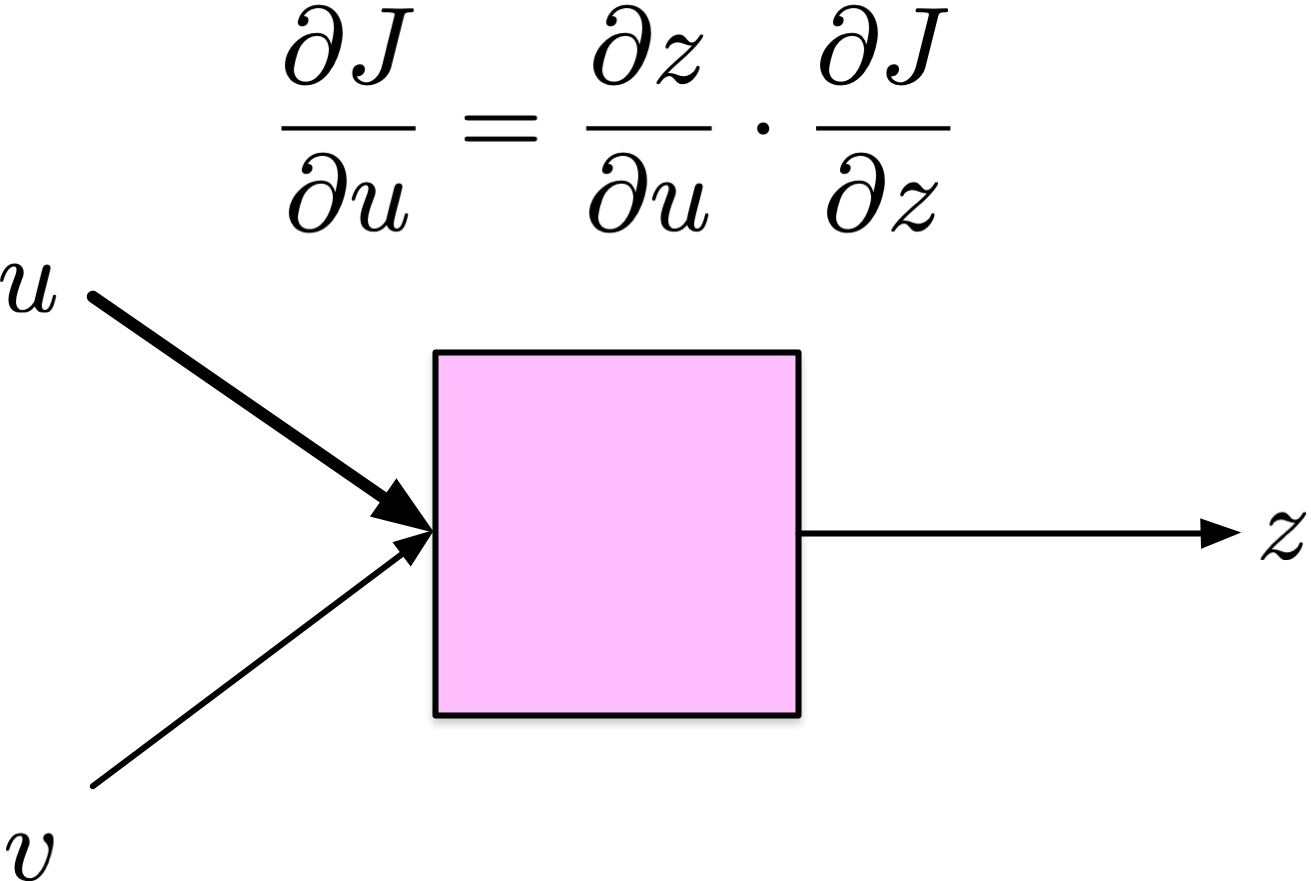

Où $u$ est un paramètre du modèle, un de ces $w_{i,j}^{(\ell)}$ et
$b_{j}^{(\ell)}$.

La rétropropagation simplifie le processus de calcul en le décomposant
en une série d’étapes élémentaires, où la règle de la chaîne est
appliquée méticuleusement à chaque étape.

Considérons une fonction représentée par un cadre rose, paramétrée par
$u$, qui produit une sortie $z$. Cette sortie $z$ sert d’entrée à une
autre fonction, aboutissant finalement à une entrée pour la fonction de
perte $J$.

L’expression $\frac{\partial J}{\partial u}$ désigne la dérivée
partielle de $J$ par rapport à $u$. Cette dérivée quantifie la
sensibilité de la perte $J$ aux variations du paramètre $u$, indiquant
si $u$ doit être augmenté ou diminué, et de quelle ampleur, pour
minimiser la perte.

Selon la règle de la chaîne, si $\frac{\partial J}{\partial z}$ est déjà
connu, alors $\frac{\partial J}{\partial u}$ peut être calculé comme
$\frac{\partial z}{\partial u} \cdot \frac{\partial J}{\partial z}$.

## Graphe computationnel

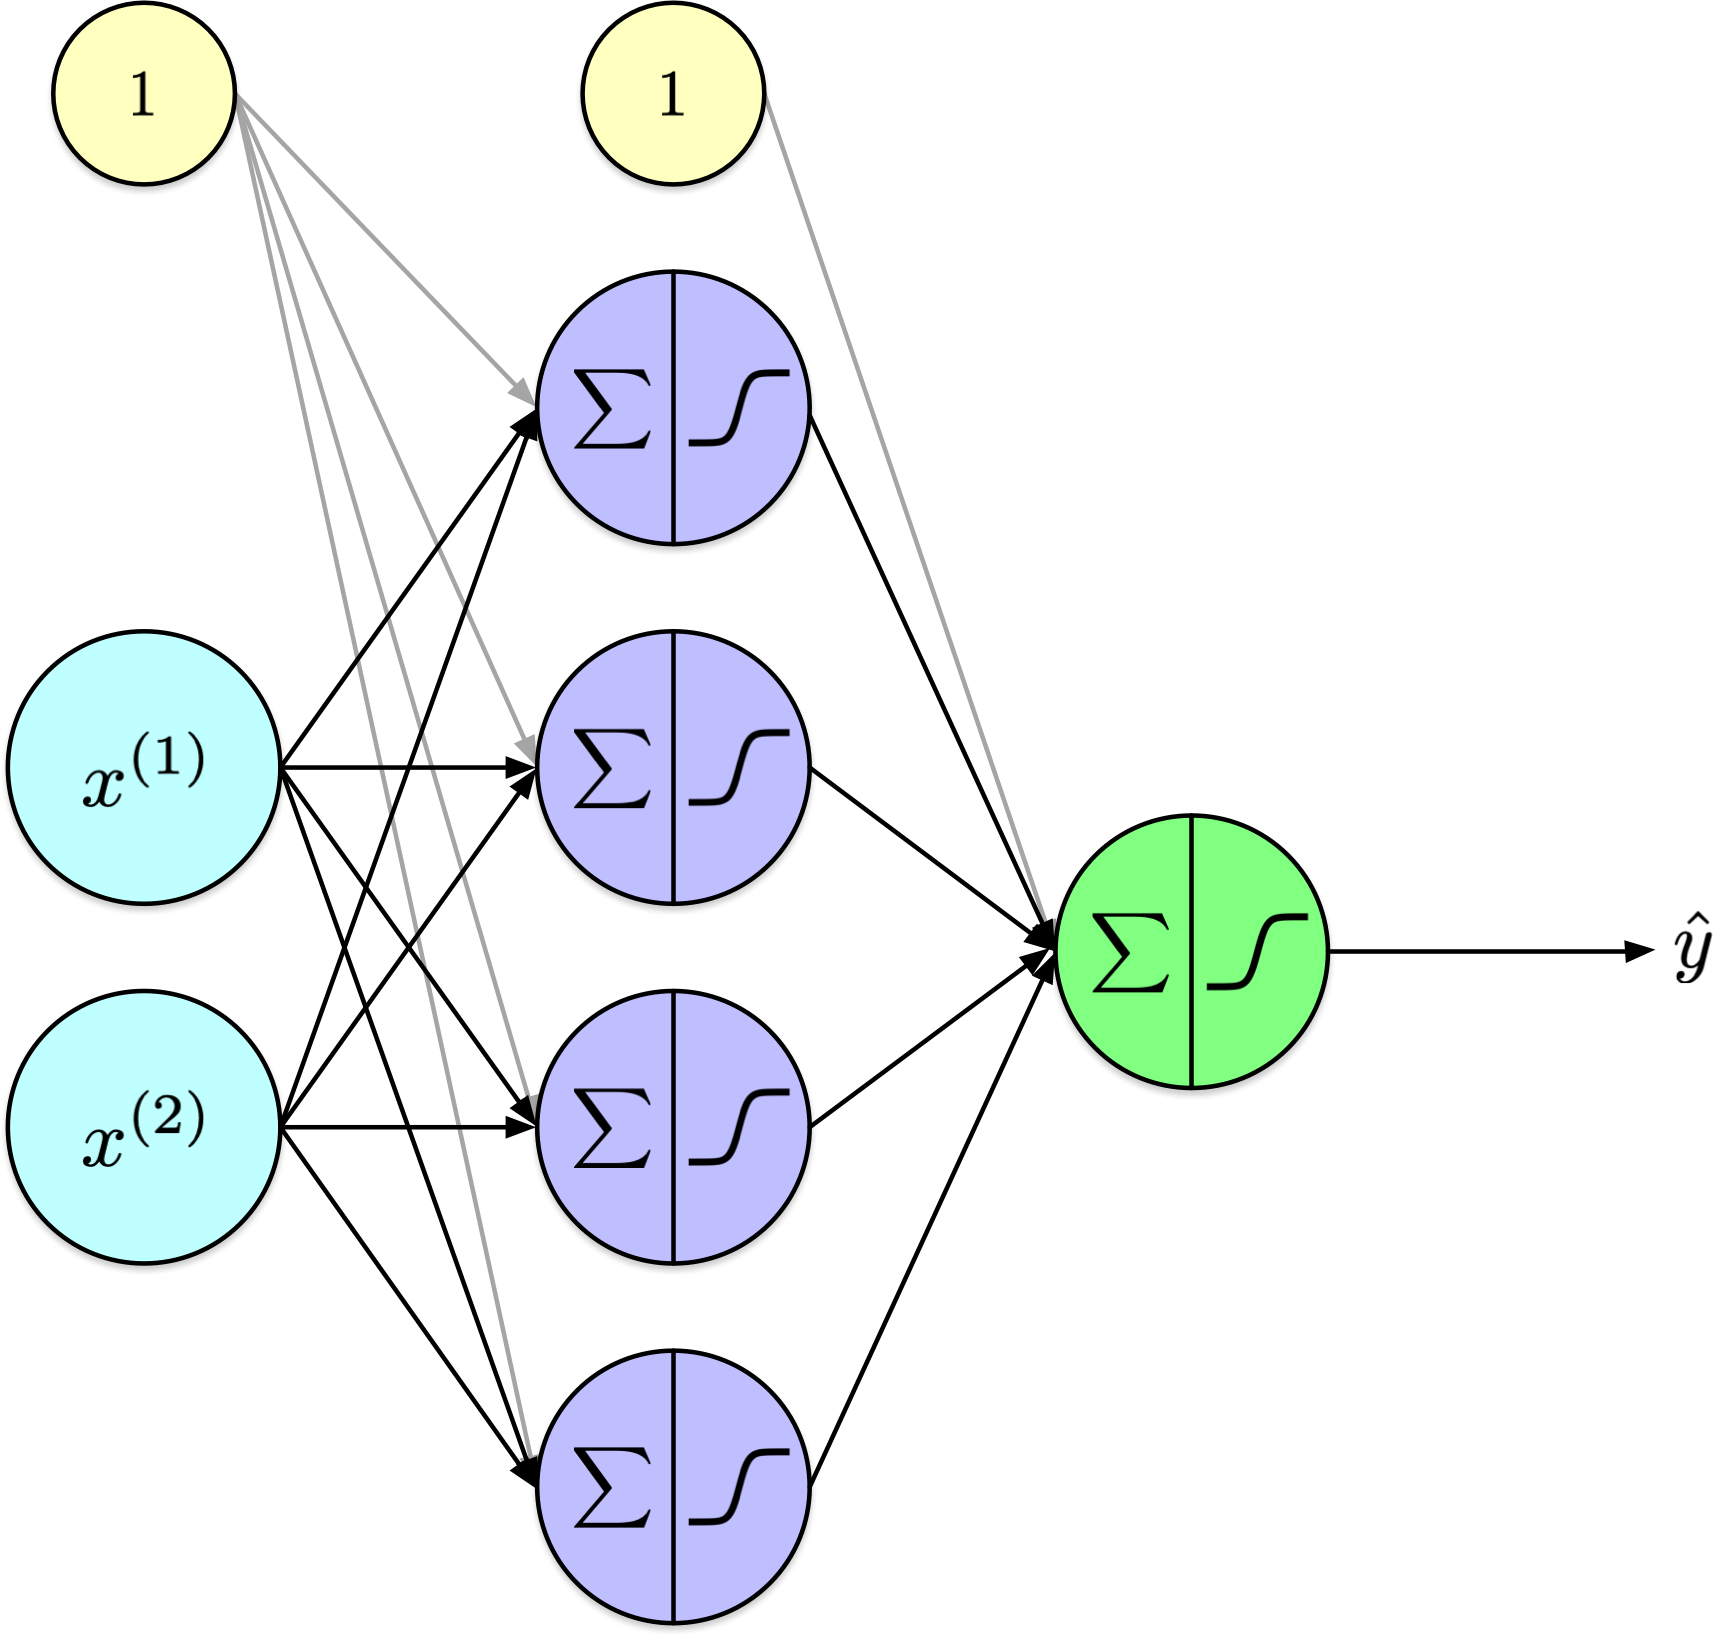

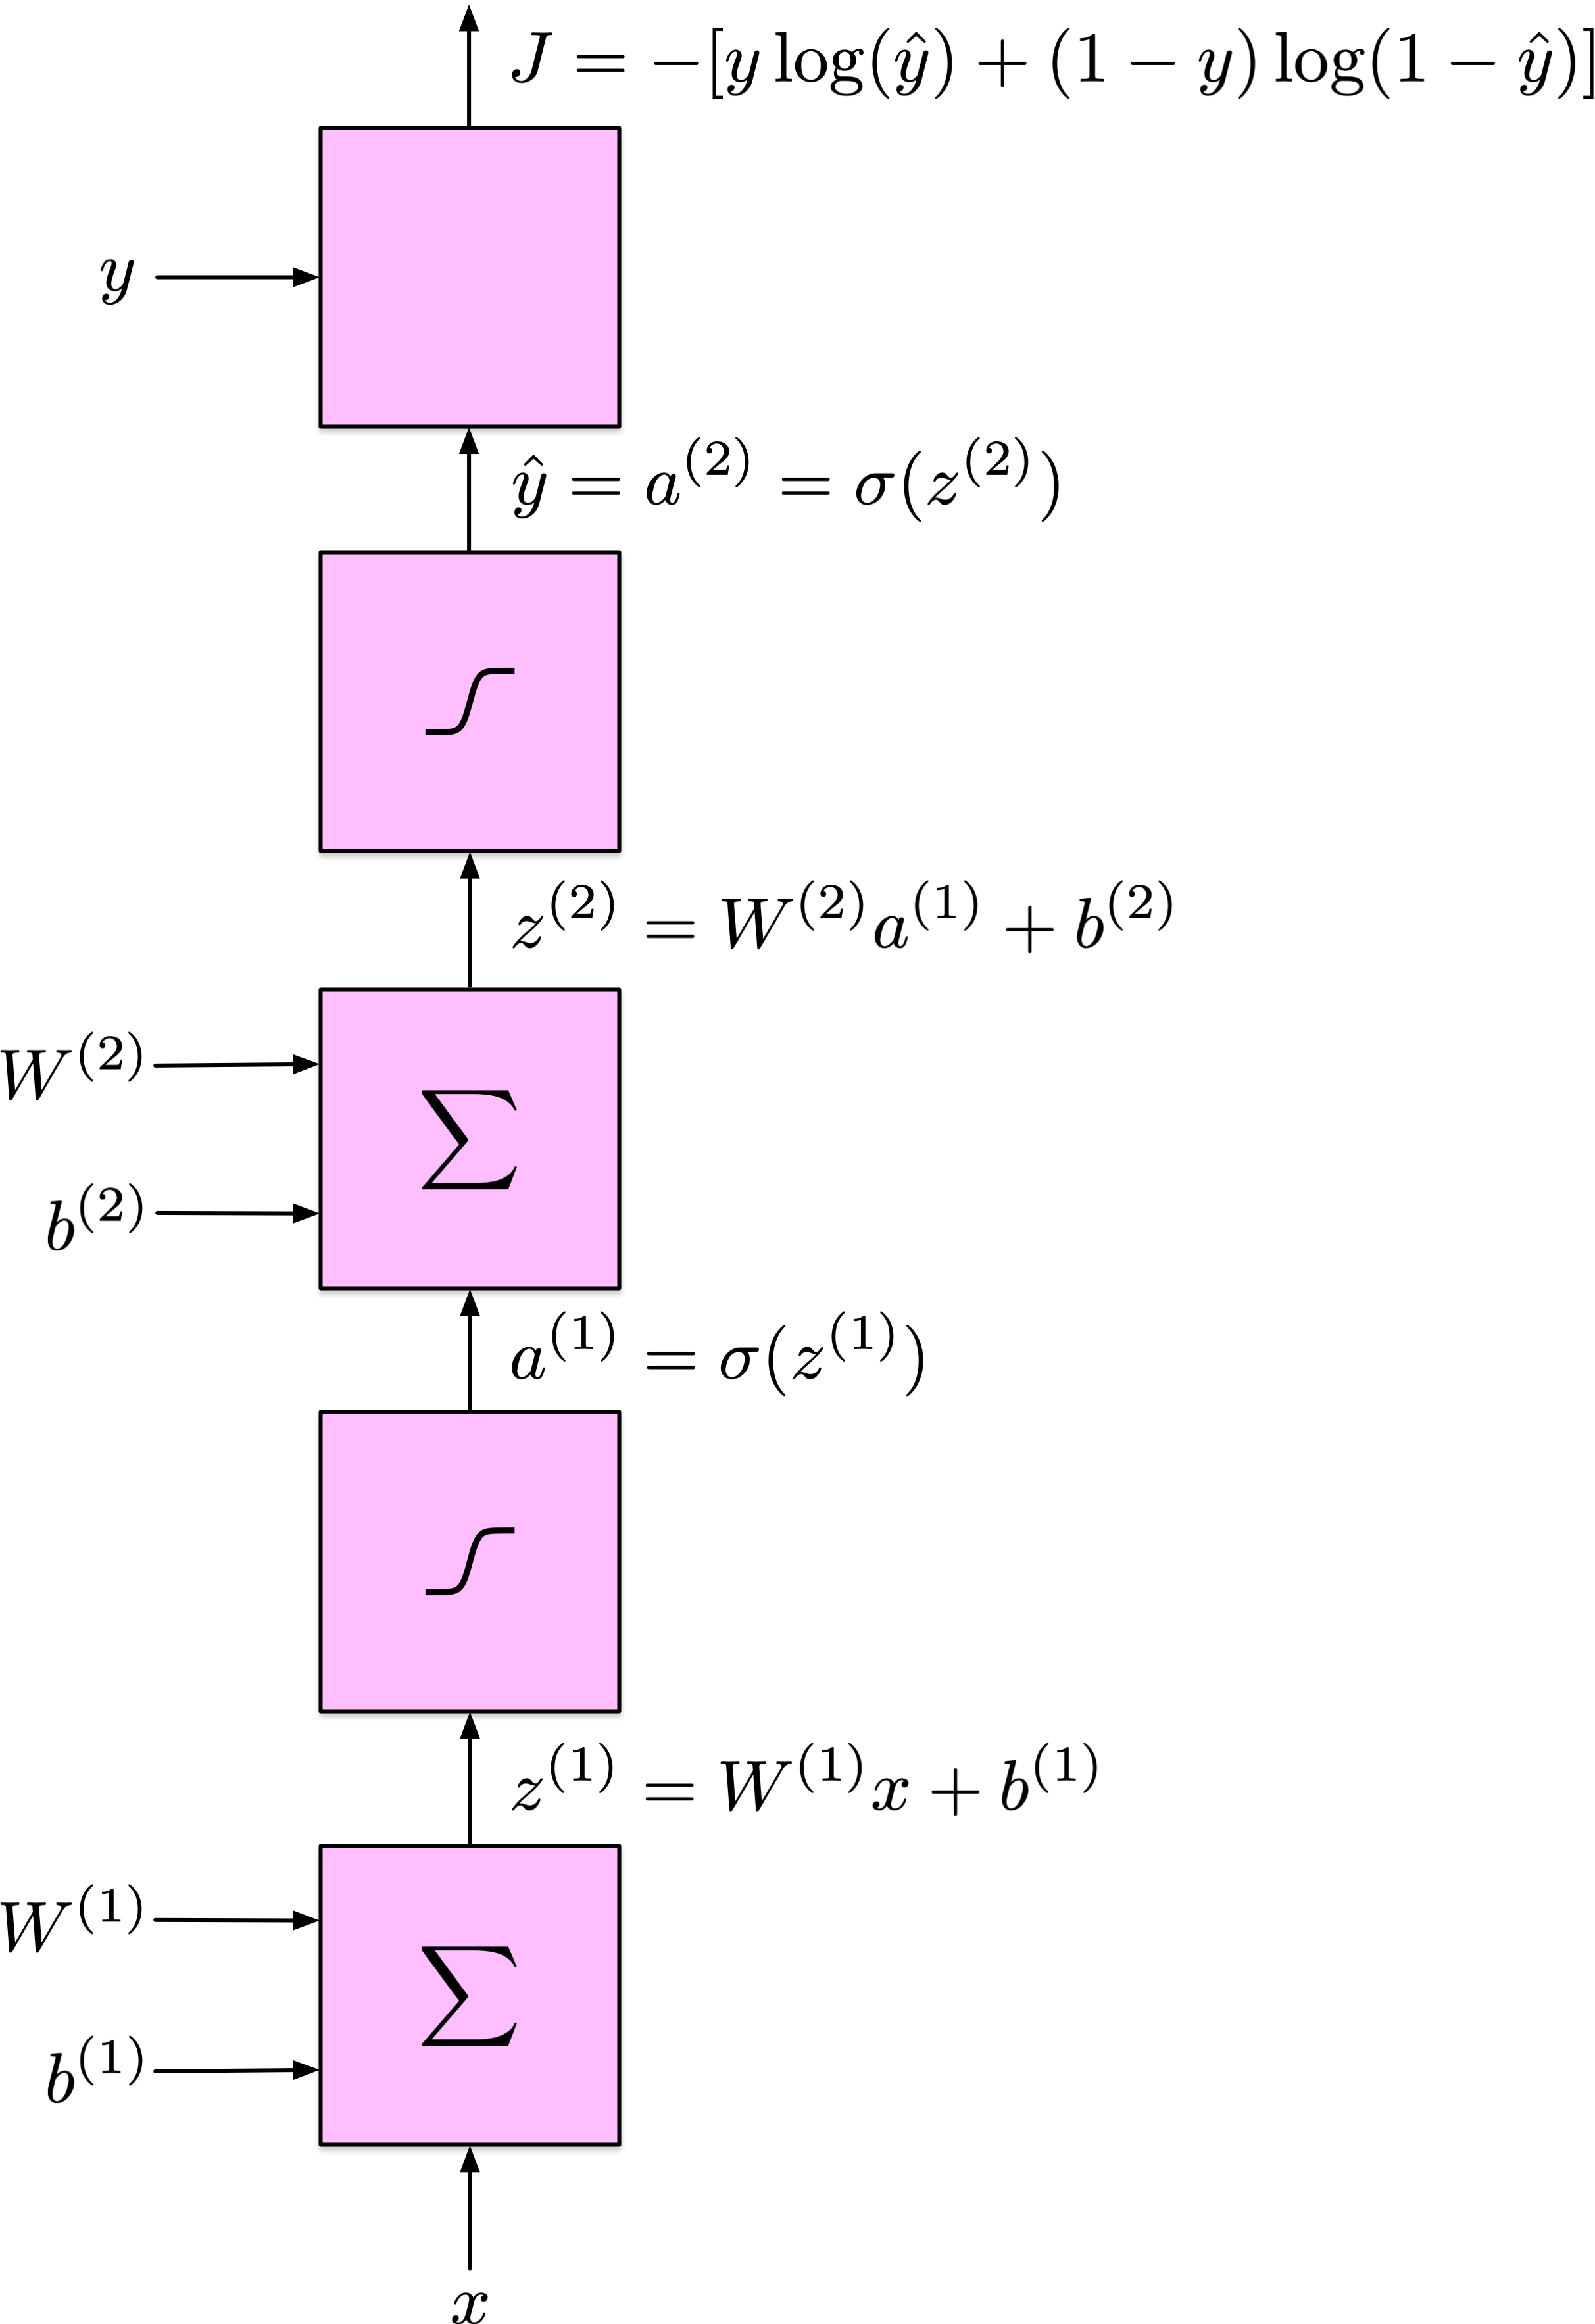

Un **perceptron à deux couches** et son **graphe computationnel**
associé.

Le réseau illustré à droite est plus général que celui à gauche. À
droite, $x$ est un vecteur, et les boîtes roses représentent des
opérations sur les vecteurs. Par conséquent, chaque couche peut
accueillir un nombre arbitrairement grand d’unités.

$W^{(l)}$ fait référence aux matrices de poids, $b^{(l)}$ aux vecteurs
de biais, $z^{(l)}$ aux vecteurs de pré-activation, et $a^{(l)}$ aux
vecteurs d’activation, chacun associé à la couche $l$.

À des fins d’illustration, la représentation à droite montre la perte
associée à un seul exemple. Pour calculer la perte sur l’ensemble du jeu
de données d’entraînement, il faut agréger ces pertes individuelles et
diviser ensuite la somme par le nombre total d’exemples, ce qui donne la
perte moyenne.

## Entrée scalaire; un nœud caché

Soit

$$
J = -\Bigl[y \,\log(\hat y) + (1-y)\,\log(1-\hat y)\Bigr]
$$

$$
  \hat y = a_2 = \sigma(z_2),
  \quad
  z_2 = w_2 \cdot a_1 + b_2
$$

$$
  a_1 = \sigma(z_1),
  \quad
  z_1 = w_1 \cdot x + b_1
$$

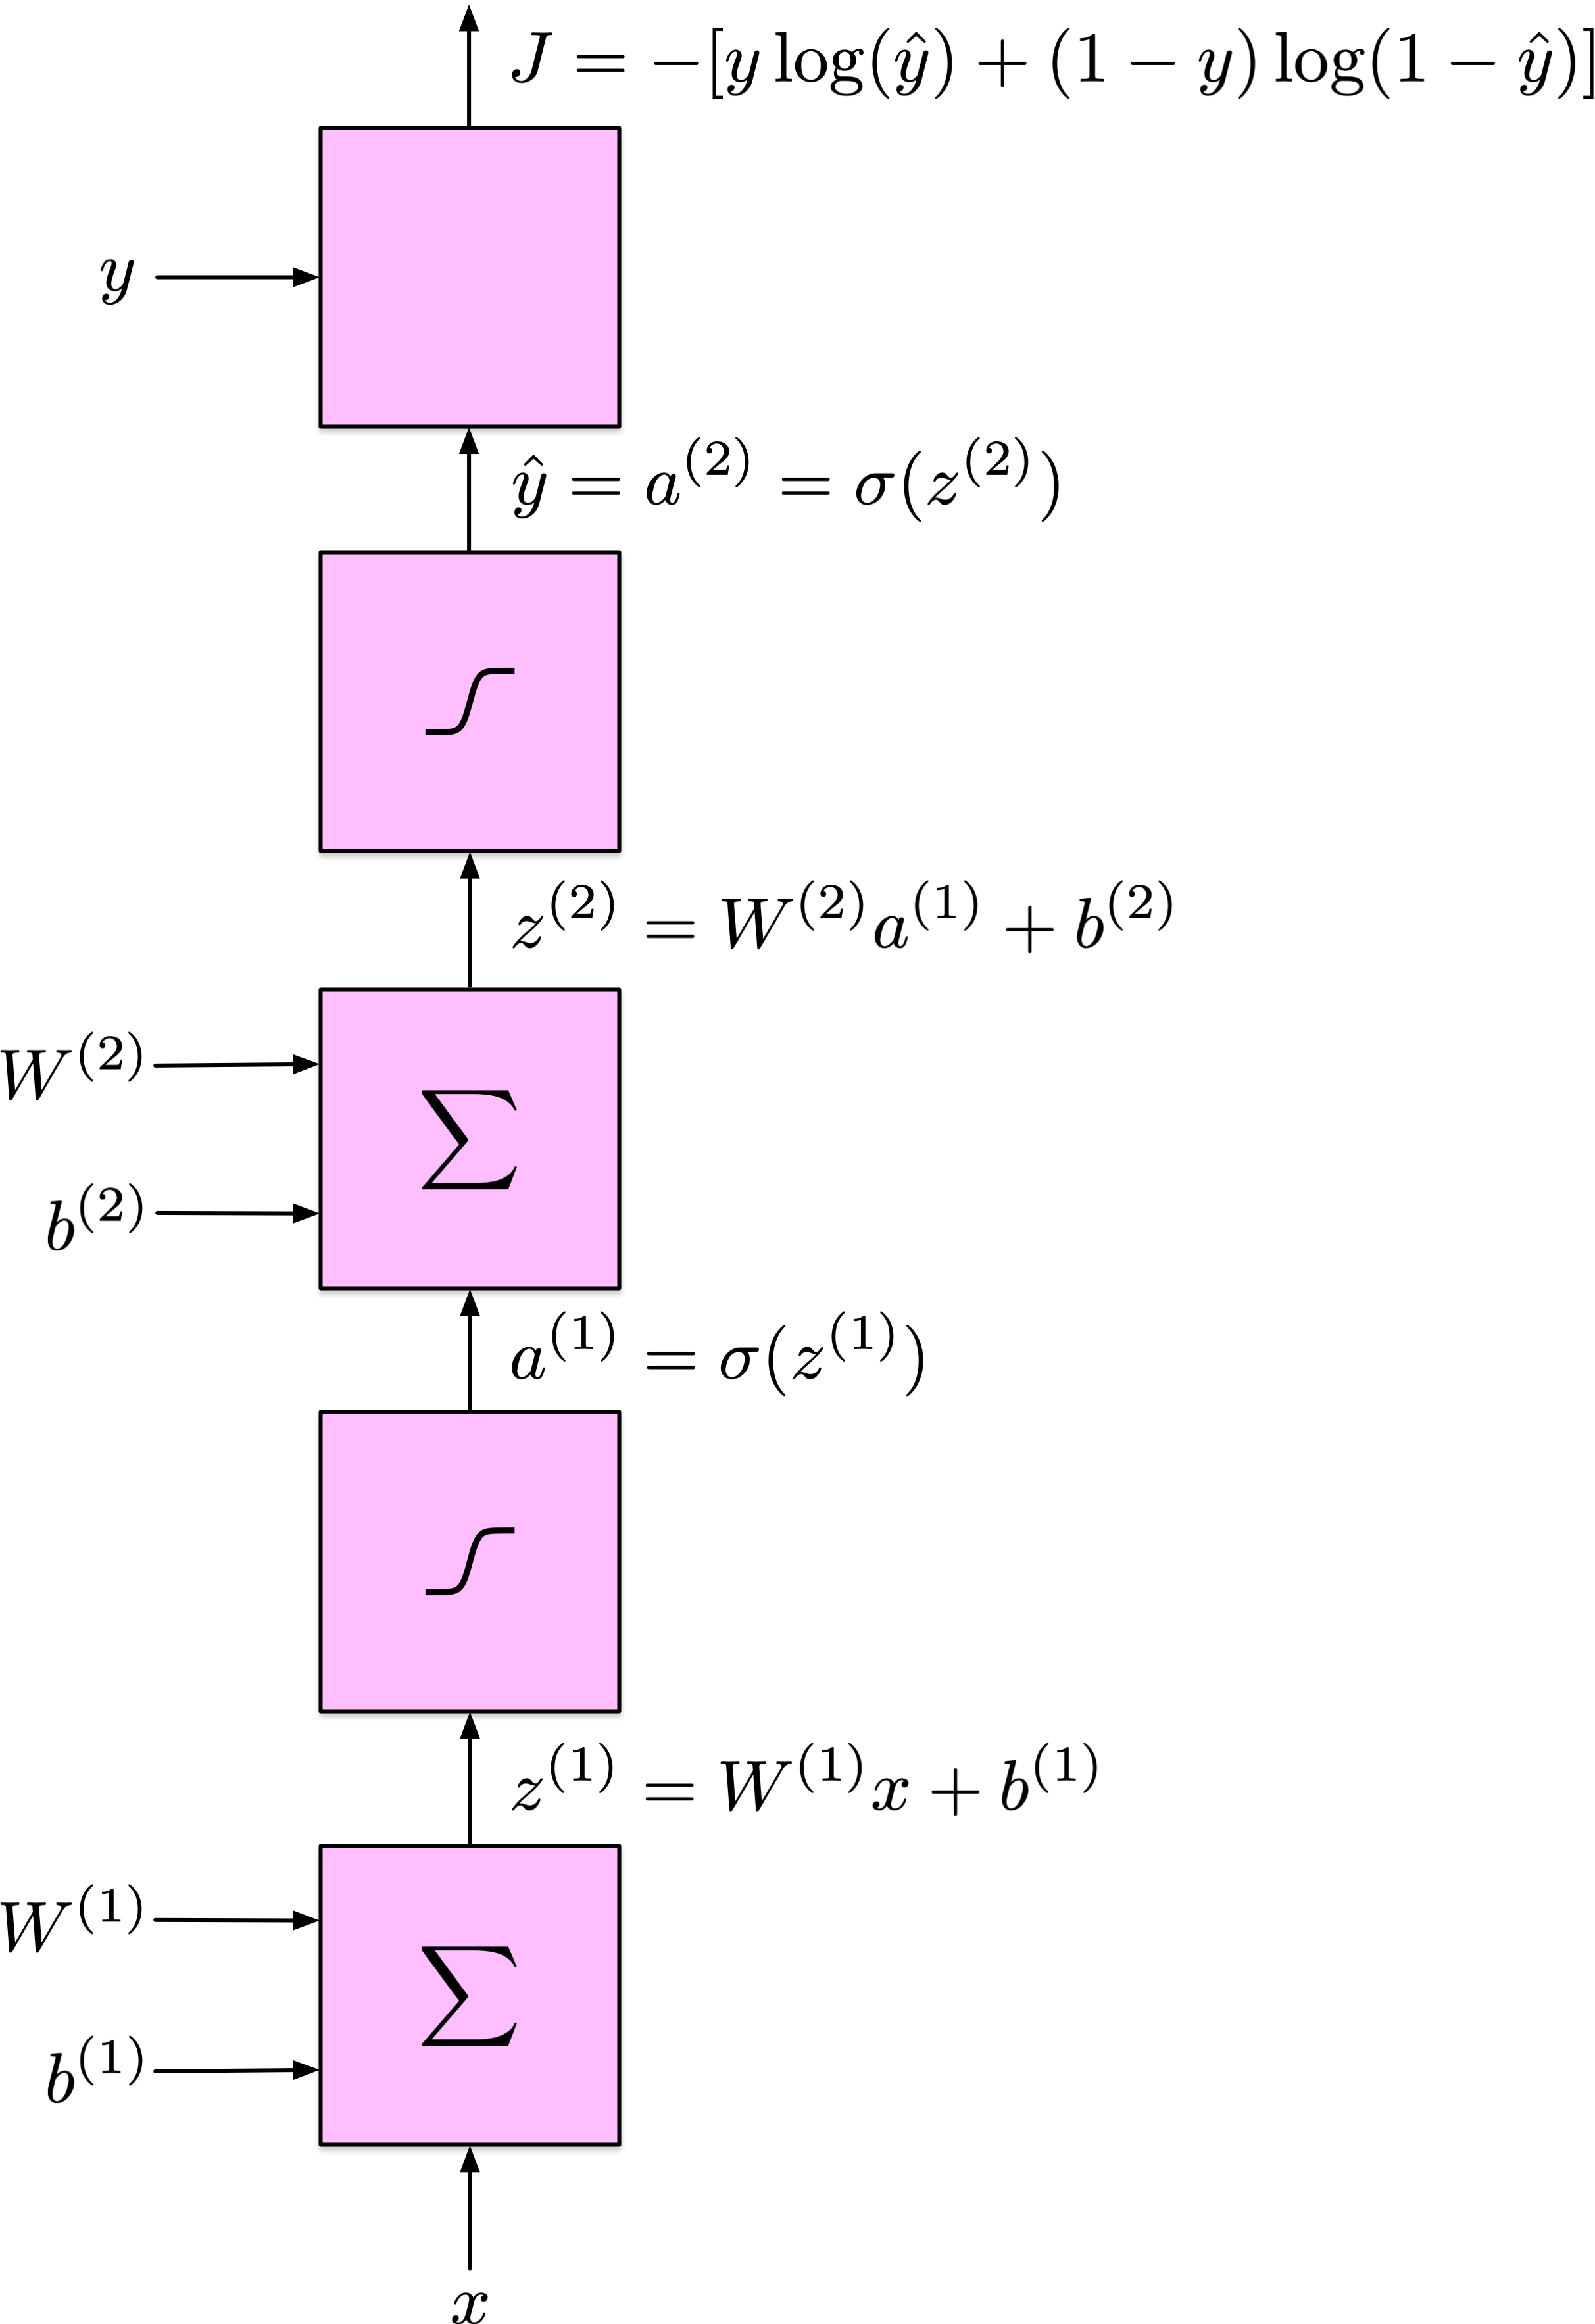

La partie gauche présente les équations pour un réseau neuronal de base
avec une entrée scalaire, notée $x$, et un seul nœud caché. Chaque
couche de ce réseau est caractérisée par un poids, et donc une notation
simplifiée avec un seul indice est utilisée.

À l’inverse, la partie droite illustre le réseau en utilisant la
notation vectorielle. Dans ce contexte, $W^{(\ell)}$ représente la
matrice de poids pour la couche $\ell$. Les dimensions de cette matrice
sont définies comme $\text{entrée} \times \text{sortie}$, où **entrée**
se réfère au nombre d’activations de la couche précédente, et **sortie**
indique le nombre de nœuds dans la couche actuelle.

Dans cette discussion, nous nous concentrerons sur les équations
scalaires pour améliorer la clarté et la simplicité. Bien que notre
attention soit portée sur les formes scalaires, les principes s’étendent
au cas plus général en utilisant le calcul vectoriel.

## Dérivées

$$
\frac{\partial J}{\partial \hat{y}}
$$

$$
  \frac{\partial \hat{y}}{\partial z_2}
$$

$$
  \frac{\partial z_2}{\partial w_2},
  \quad
  \frac{\partial z_2}{\partial b_2},
  \quad
  \frac{\partial z_2}{\partial a_1},
$$

$$
  \frac{\partial a_1}{\partial z_1},
$$

$$
  \frac{\partial z_1}{\partial w_1},
  \quad
  \frac{\partial z_1}{\partial b_1},
  \quad
  \frac{\partial z_1}{\partial x},
$$

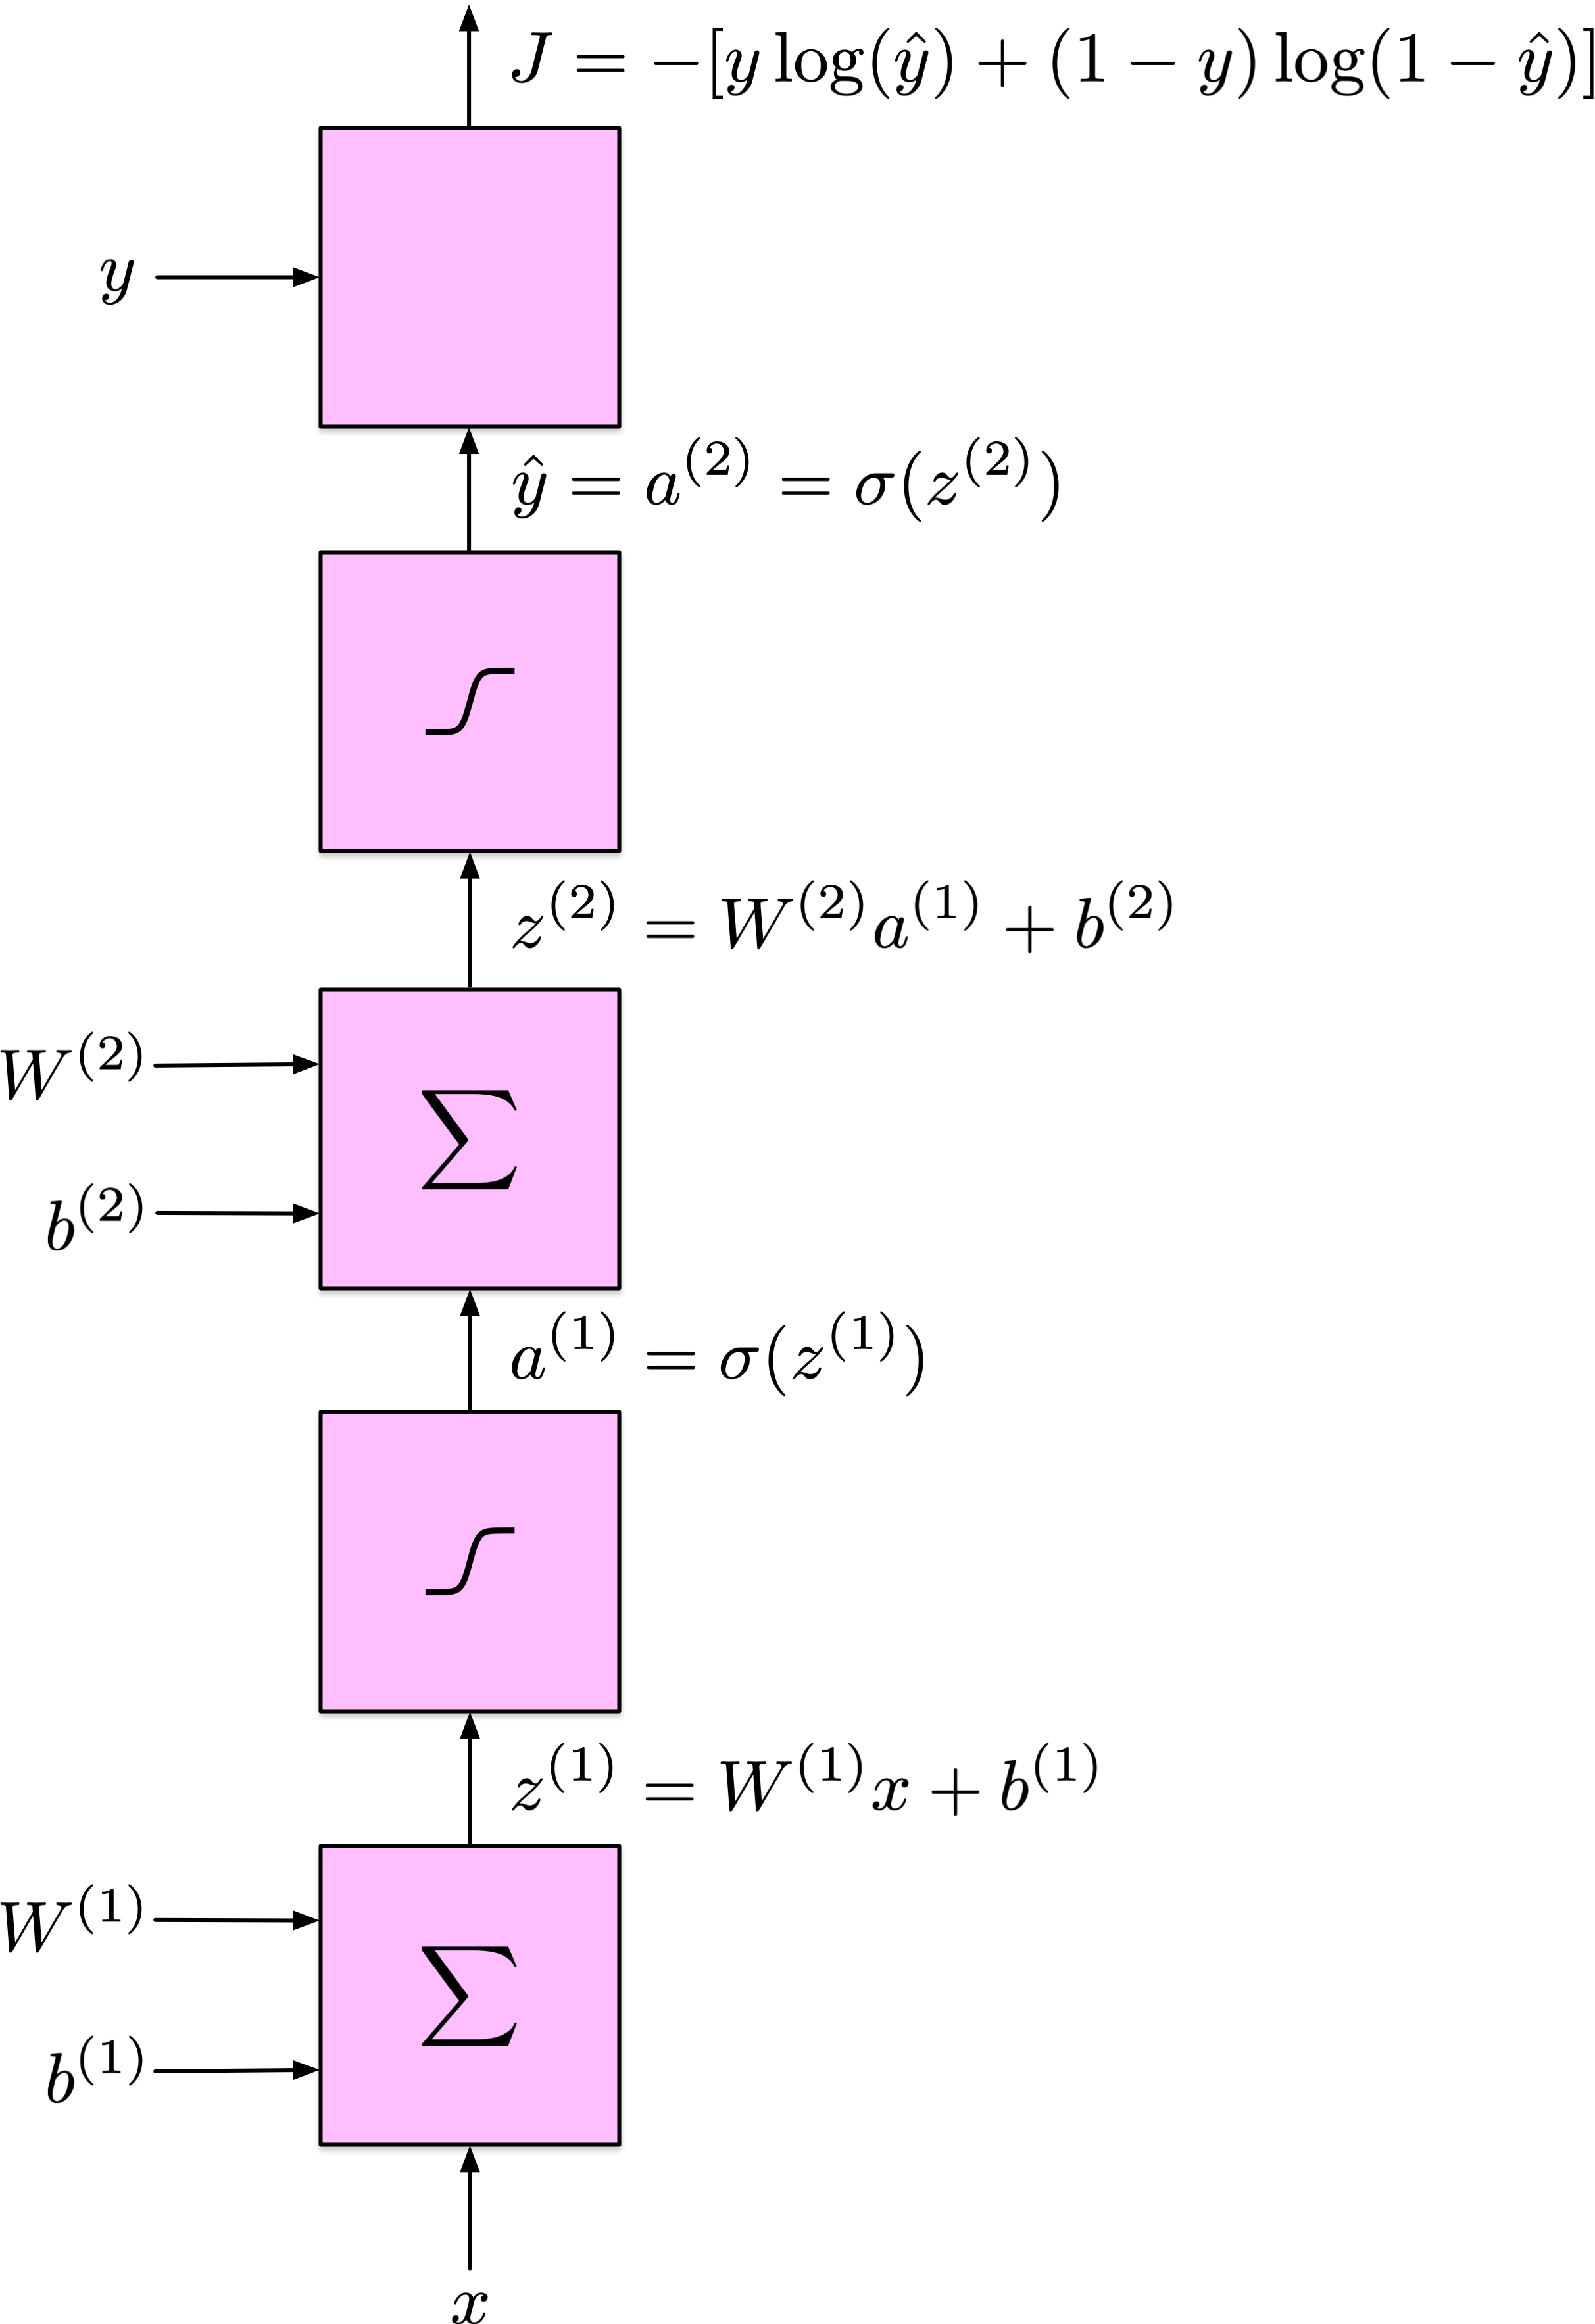

## Dérivées

Dérivée de la perte par rapport à $\hat{y}$ :

$$
  \frac{\partial J}{\partial \hat{y}} = -\left(\frac{y}{\hat{y}}-\frac{1-y}{1-\hat{y}}\right)
$$

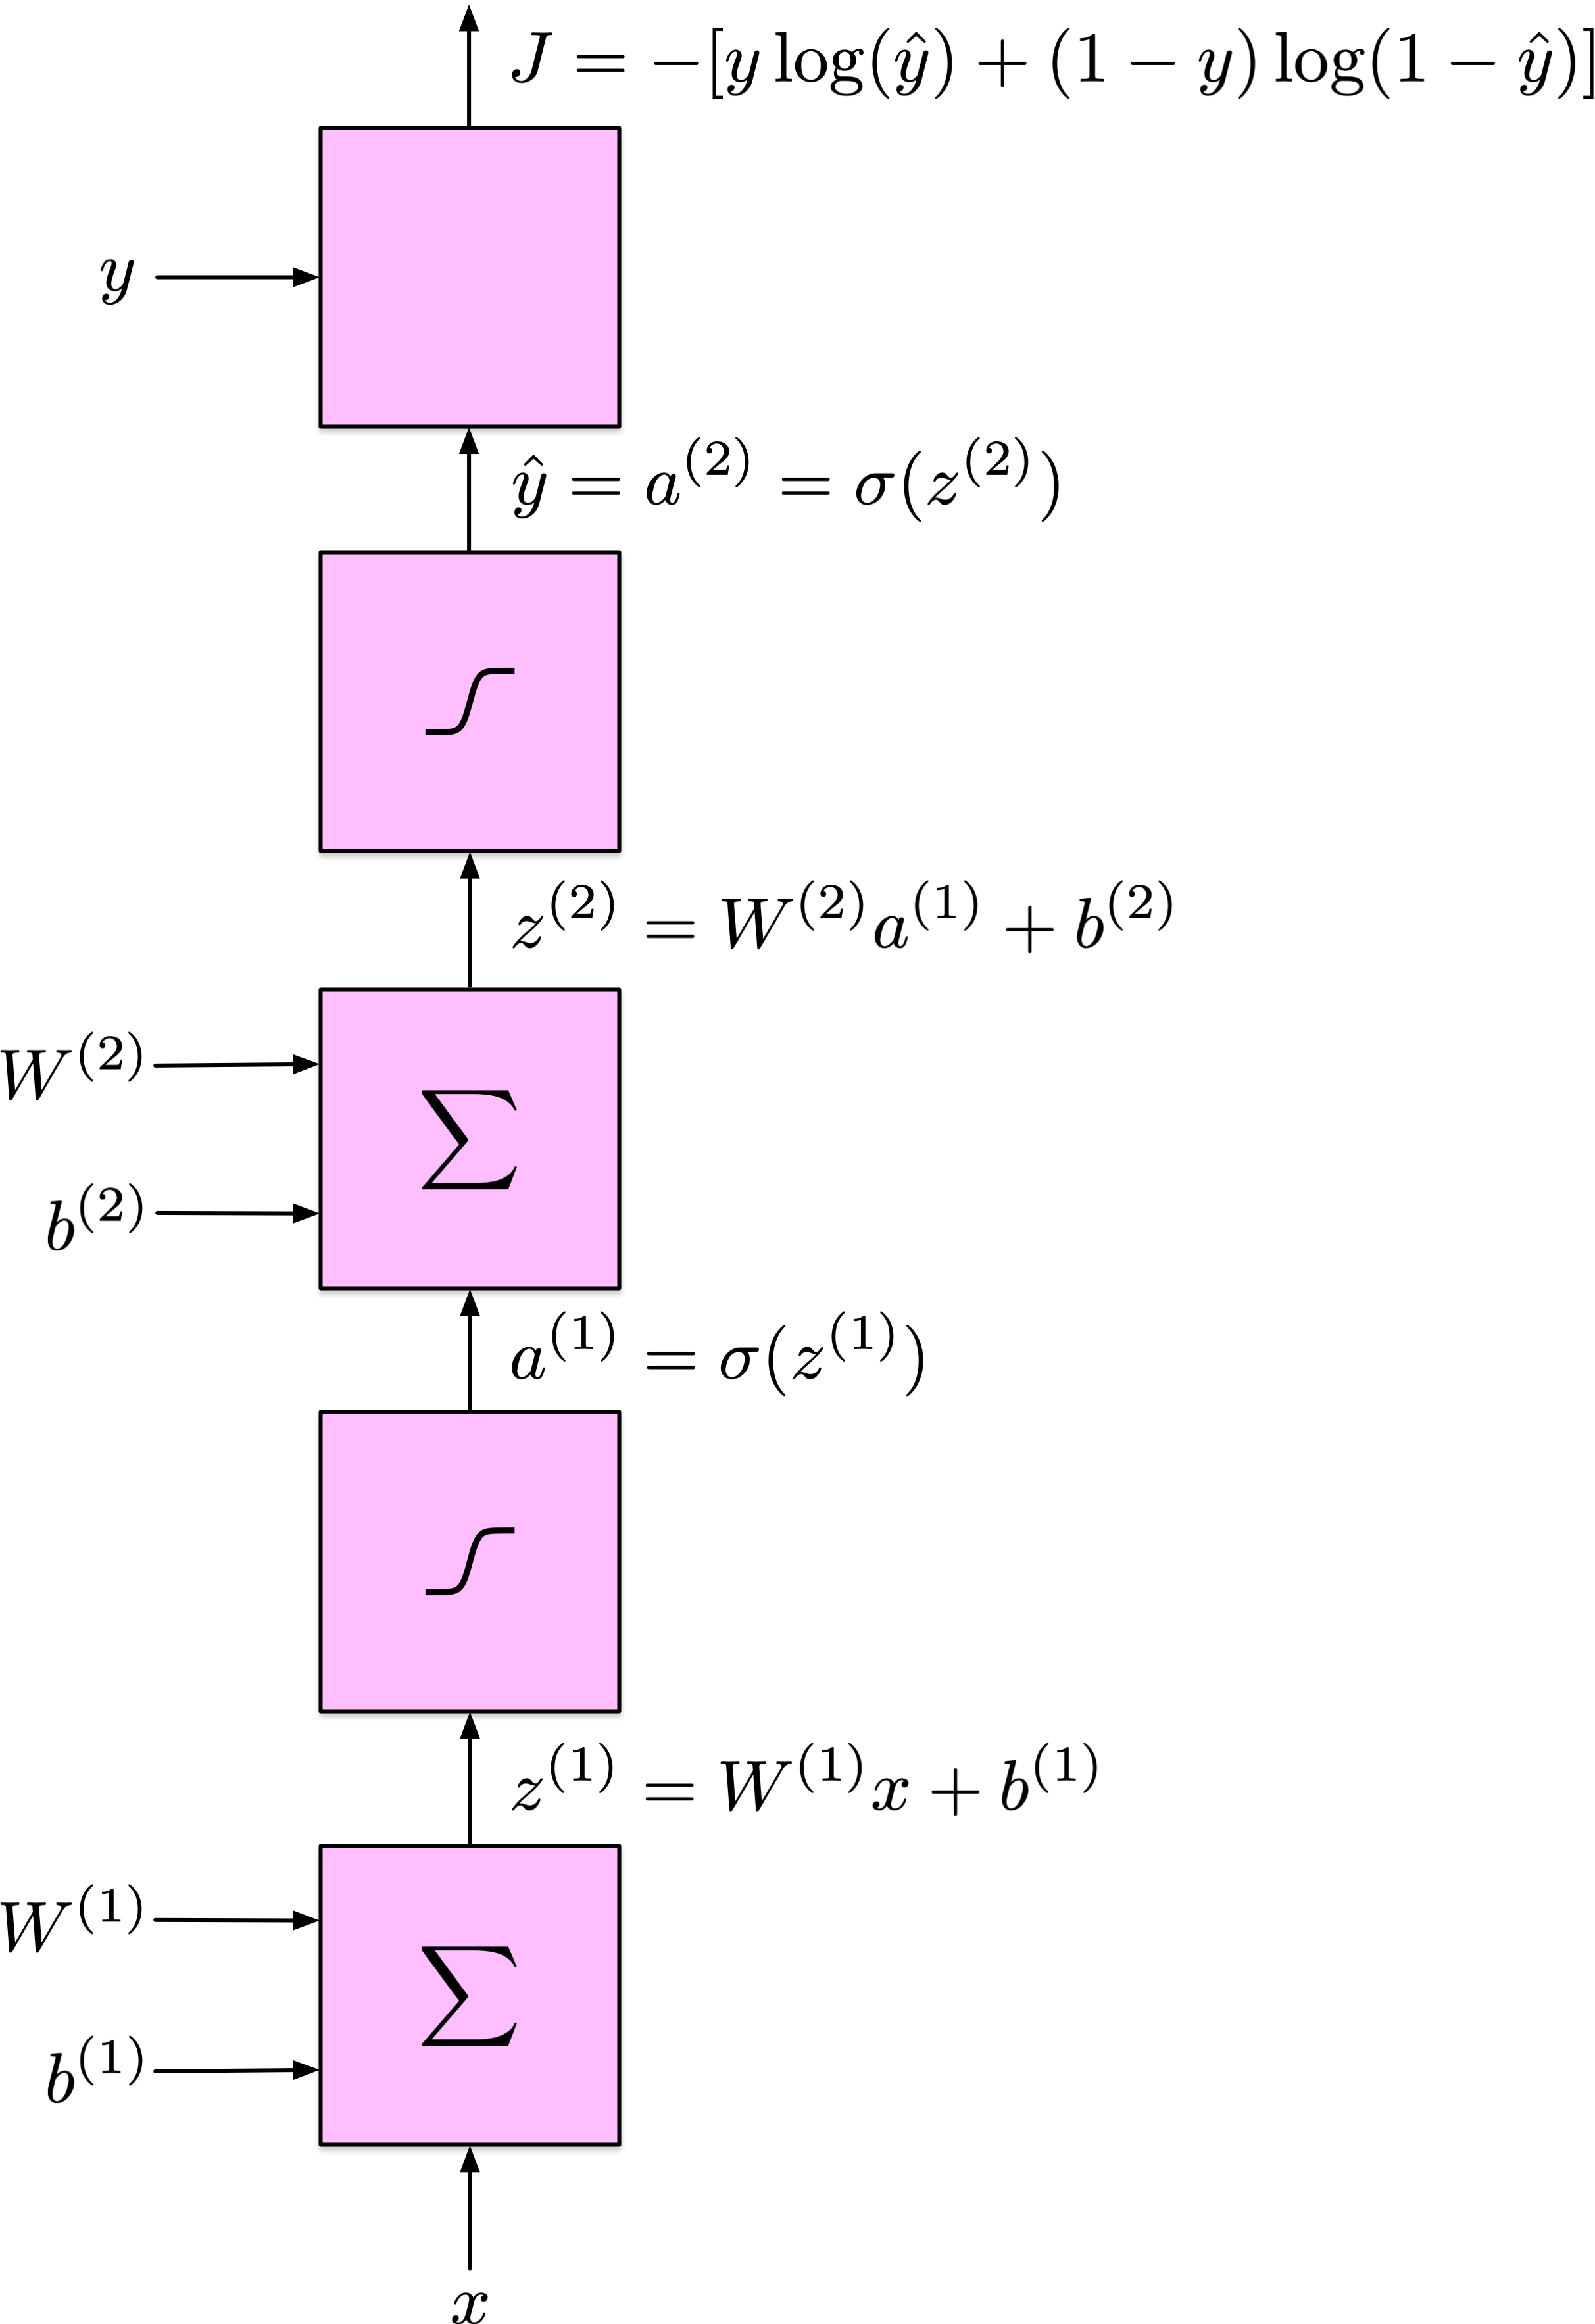

## Dérivées

Dérivée de $\hat{y}$ par rapport à $z_2$:

$$
  \frac{\partial \hat{y}}{\partial z_2}=\sigma^{\prime}\left(z_2\right)=\hat{y}(1-\hat{y})
$$

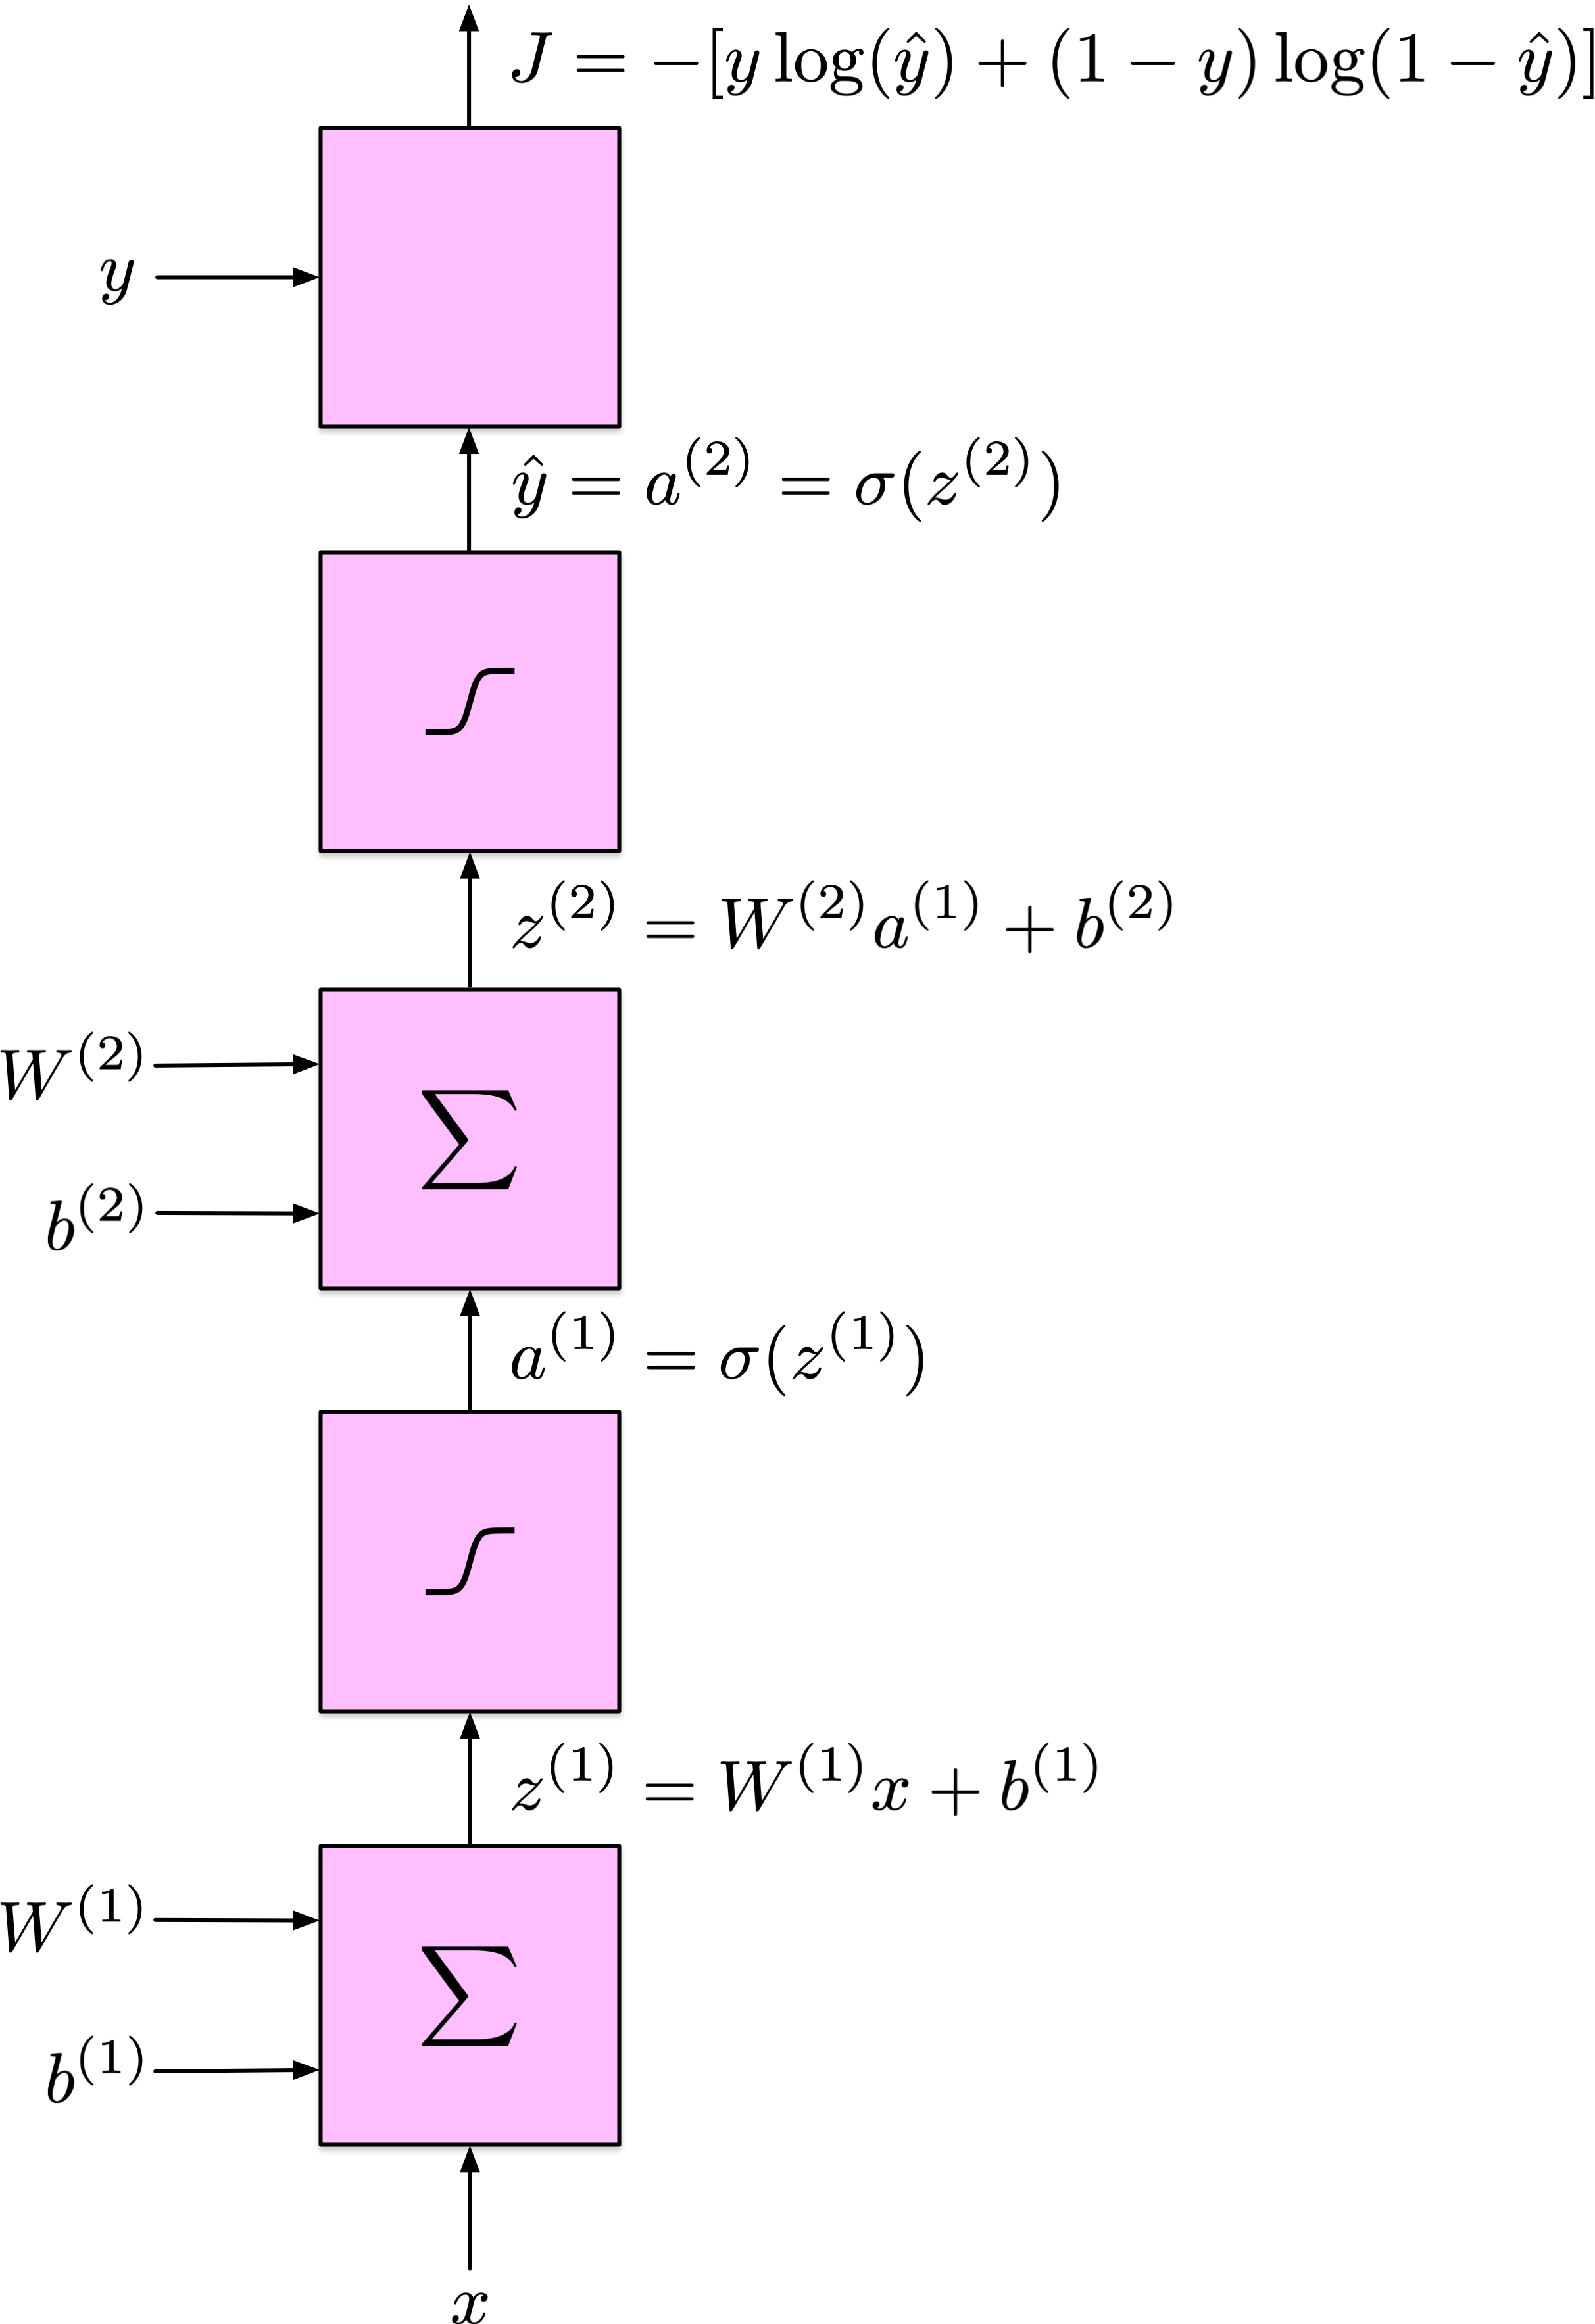

## Dérivées

Dérivée $z_2 = w_2 a_1 + b_2$:

$$
  \frac{\partial z_2}{\partial w_2}=a_1, \quad \frac{\partial z_2}{\partial b_2}=1, \quad \frac{\partial z_2}{\partial a_1}=w_2
$$

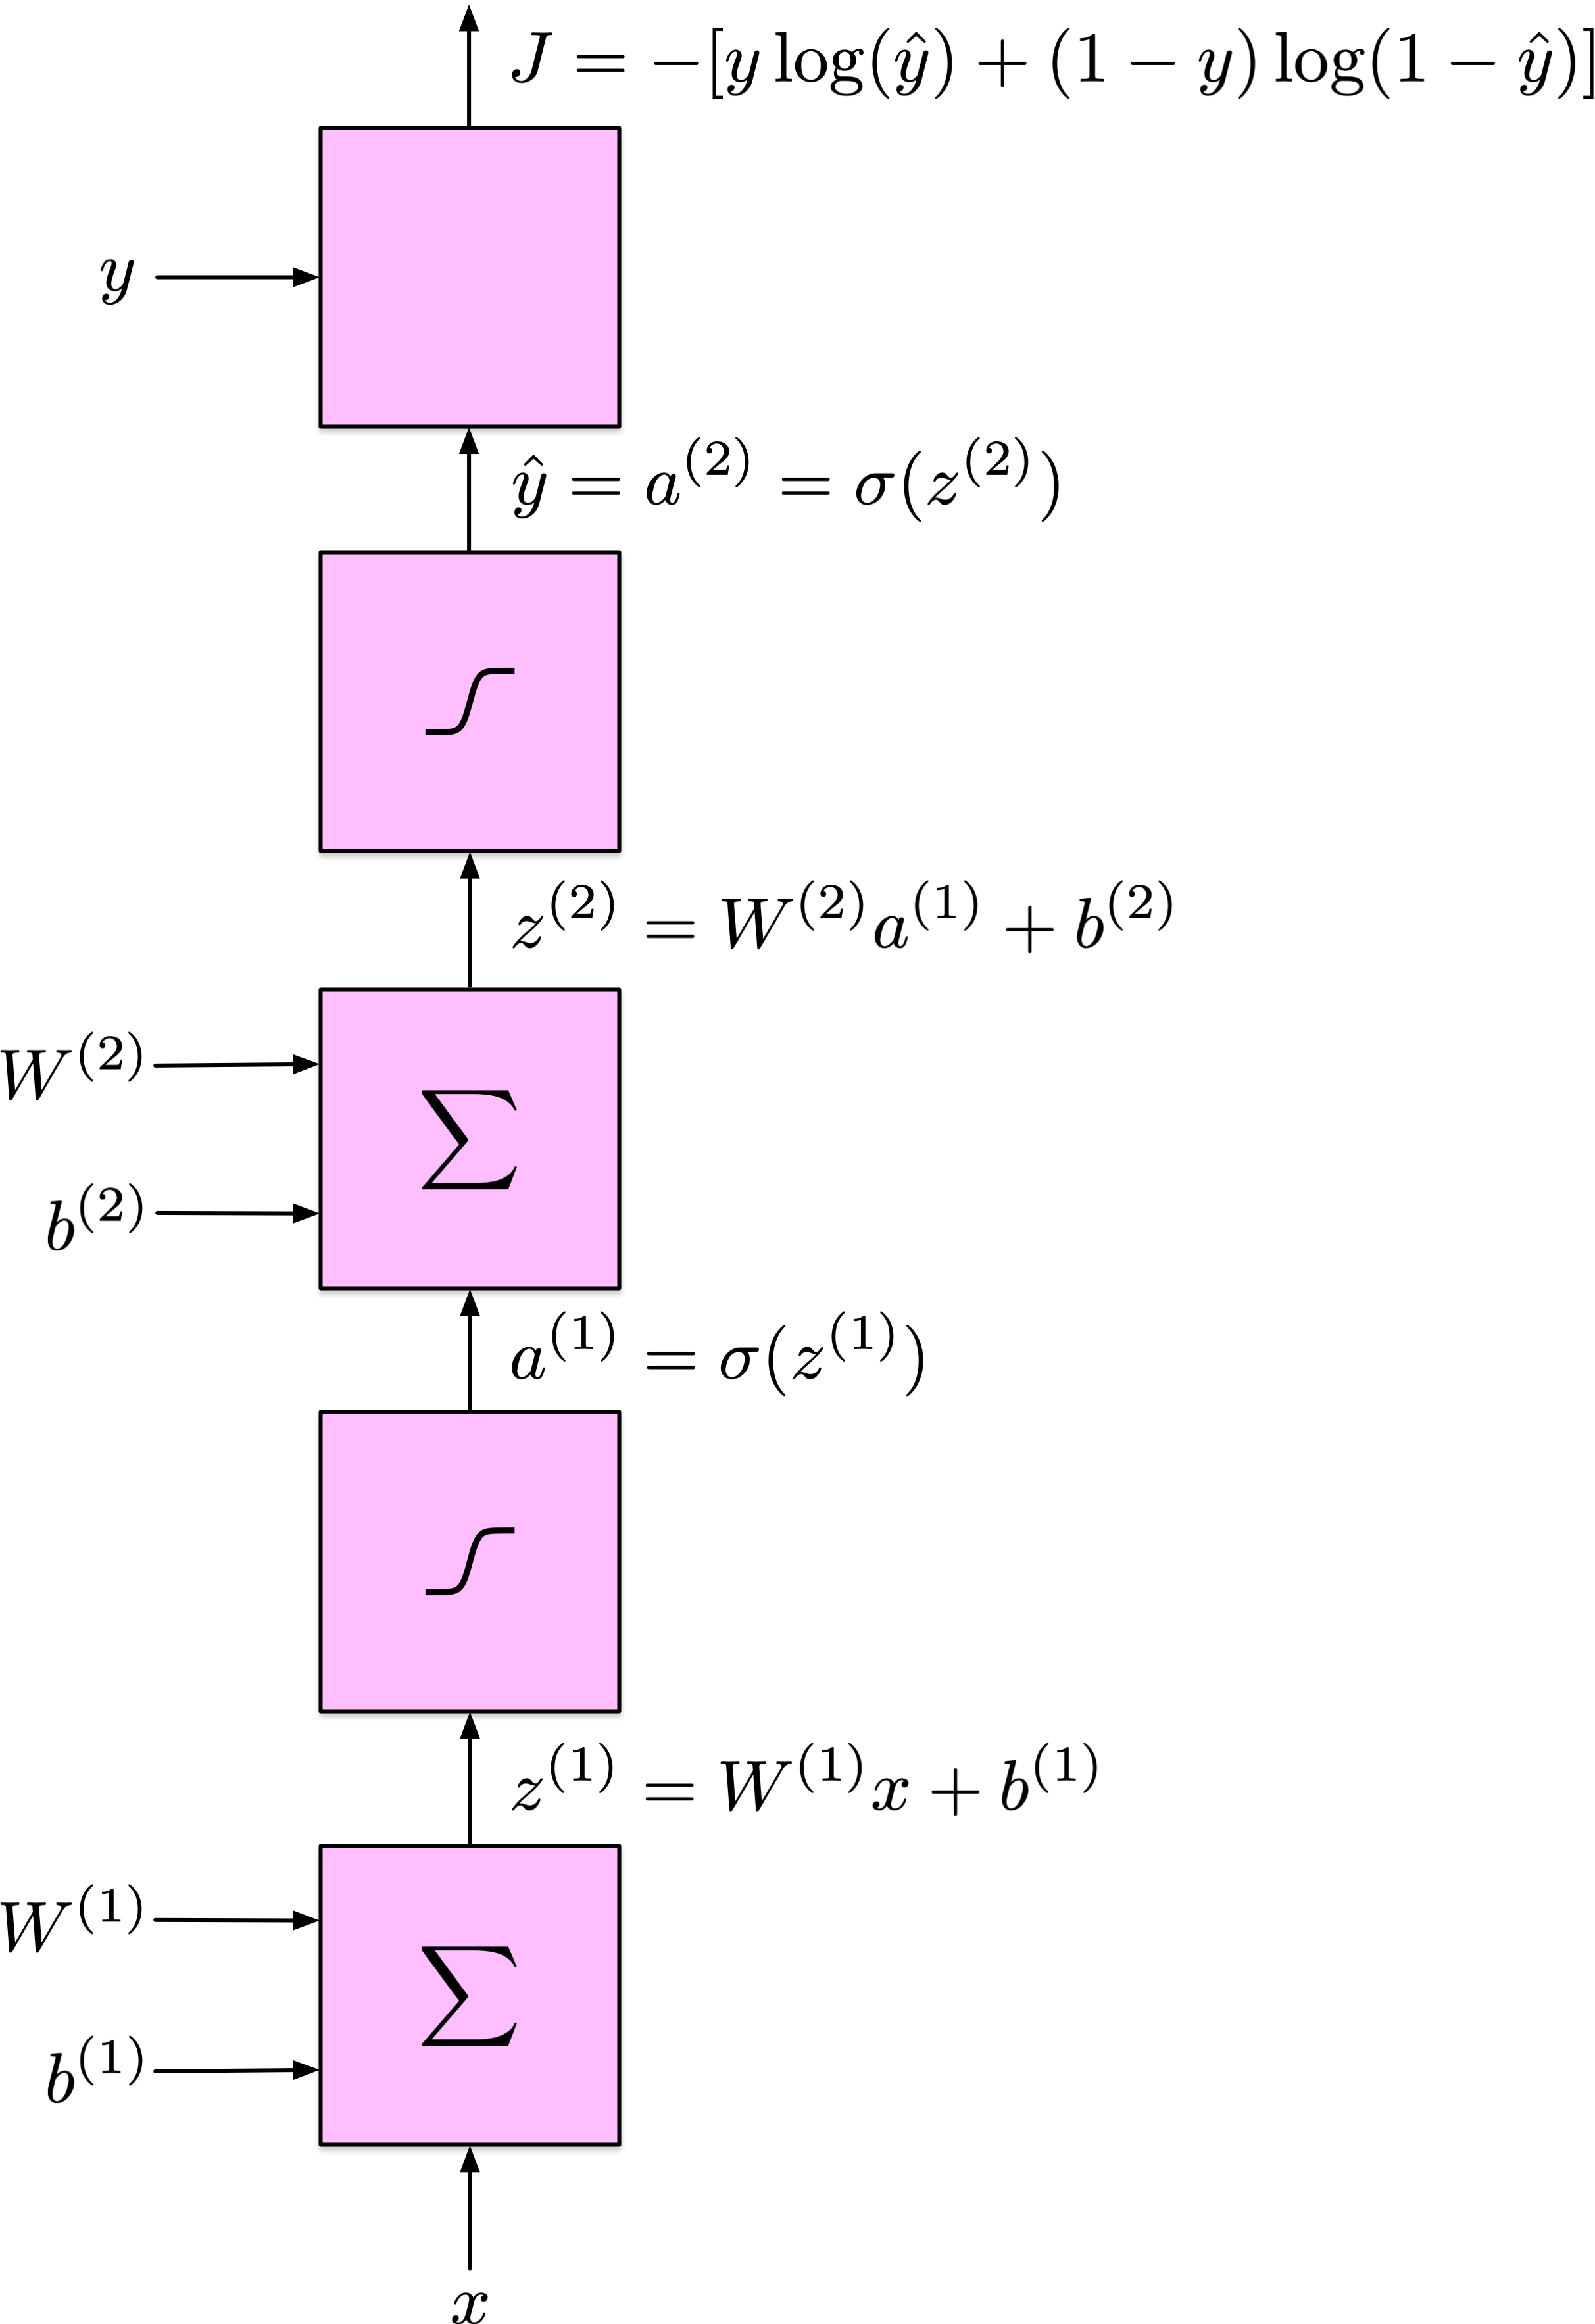

## Dérivées

Dérivée $a_1 = \sigma(z_1)$ :

$$
  \frac{\partial a_1}{\partial z_1}=\sigma^{\prime}\left(z_1\right)=a_1\left(1-a_1\right)
$$

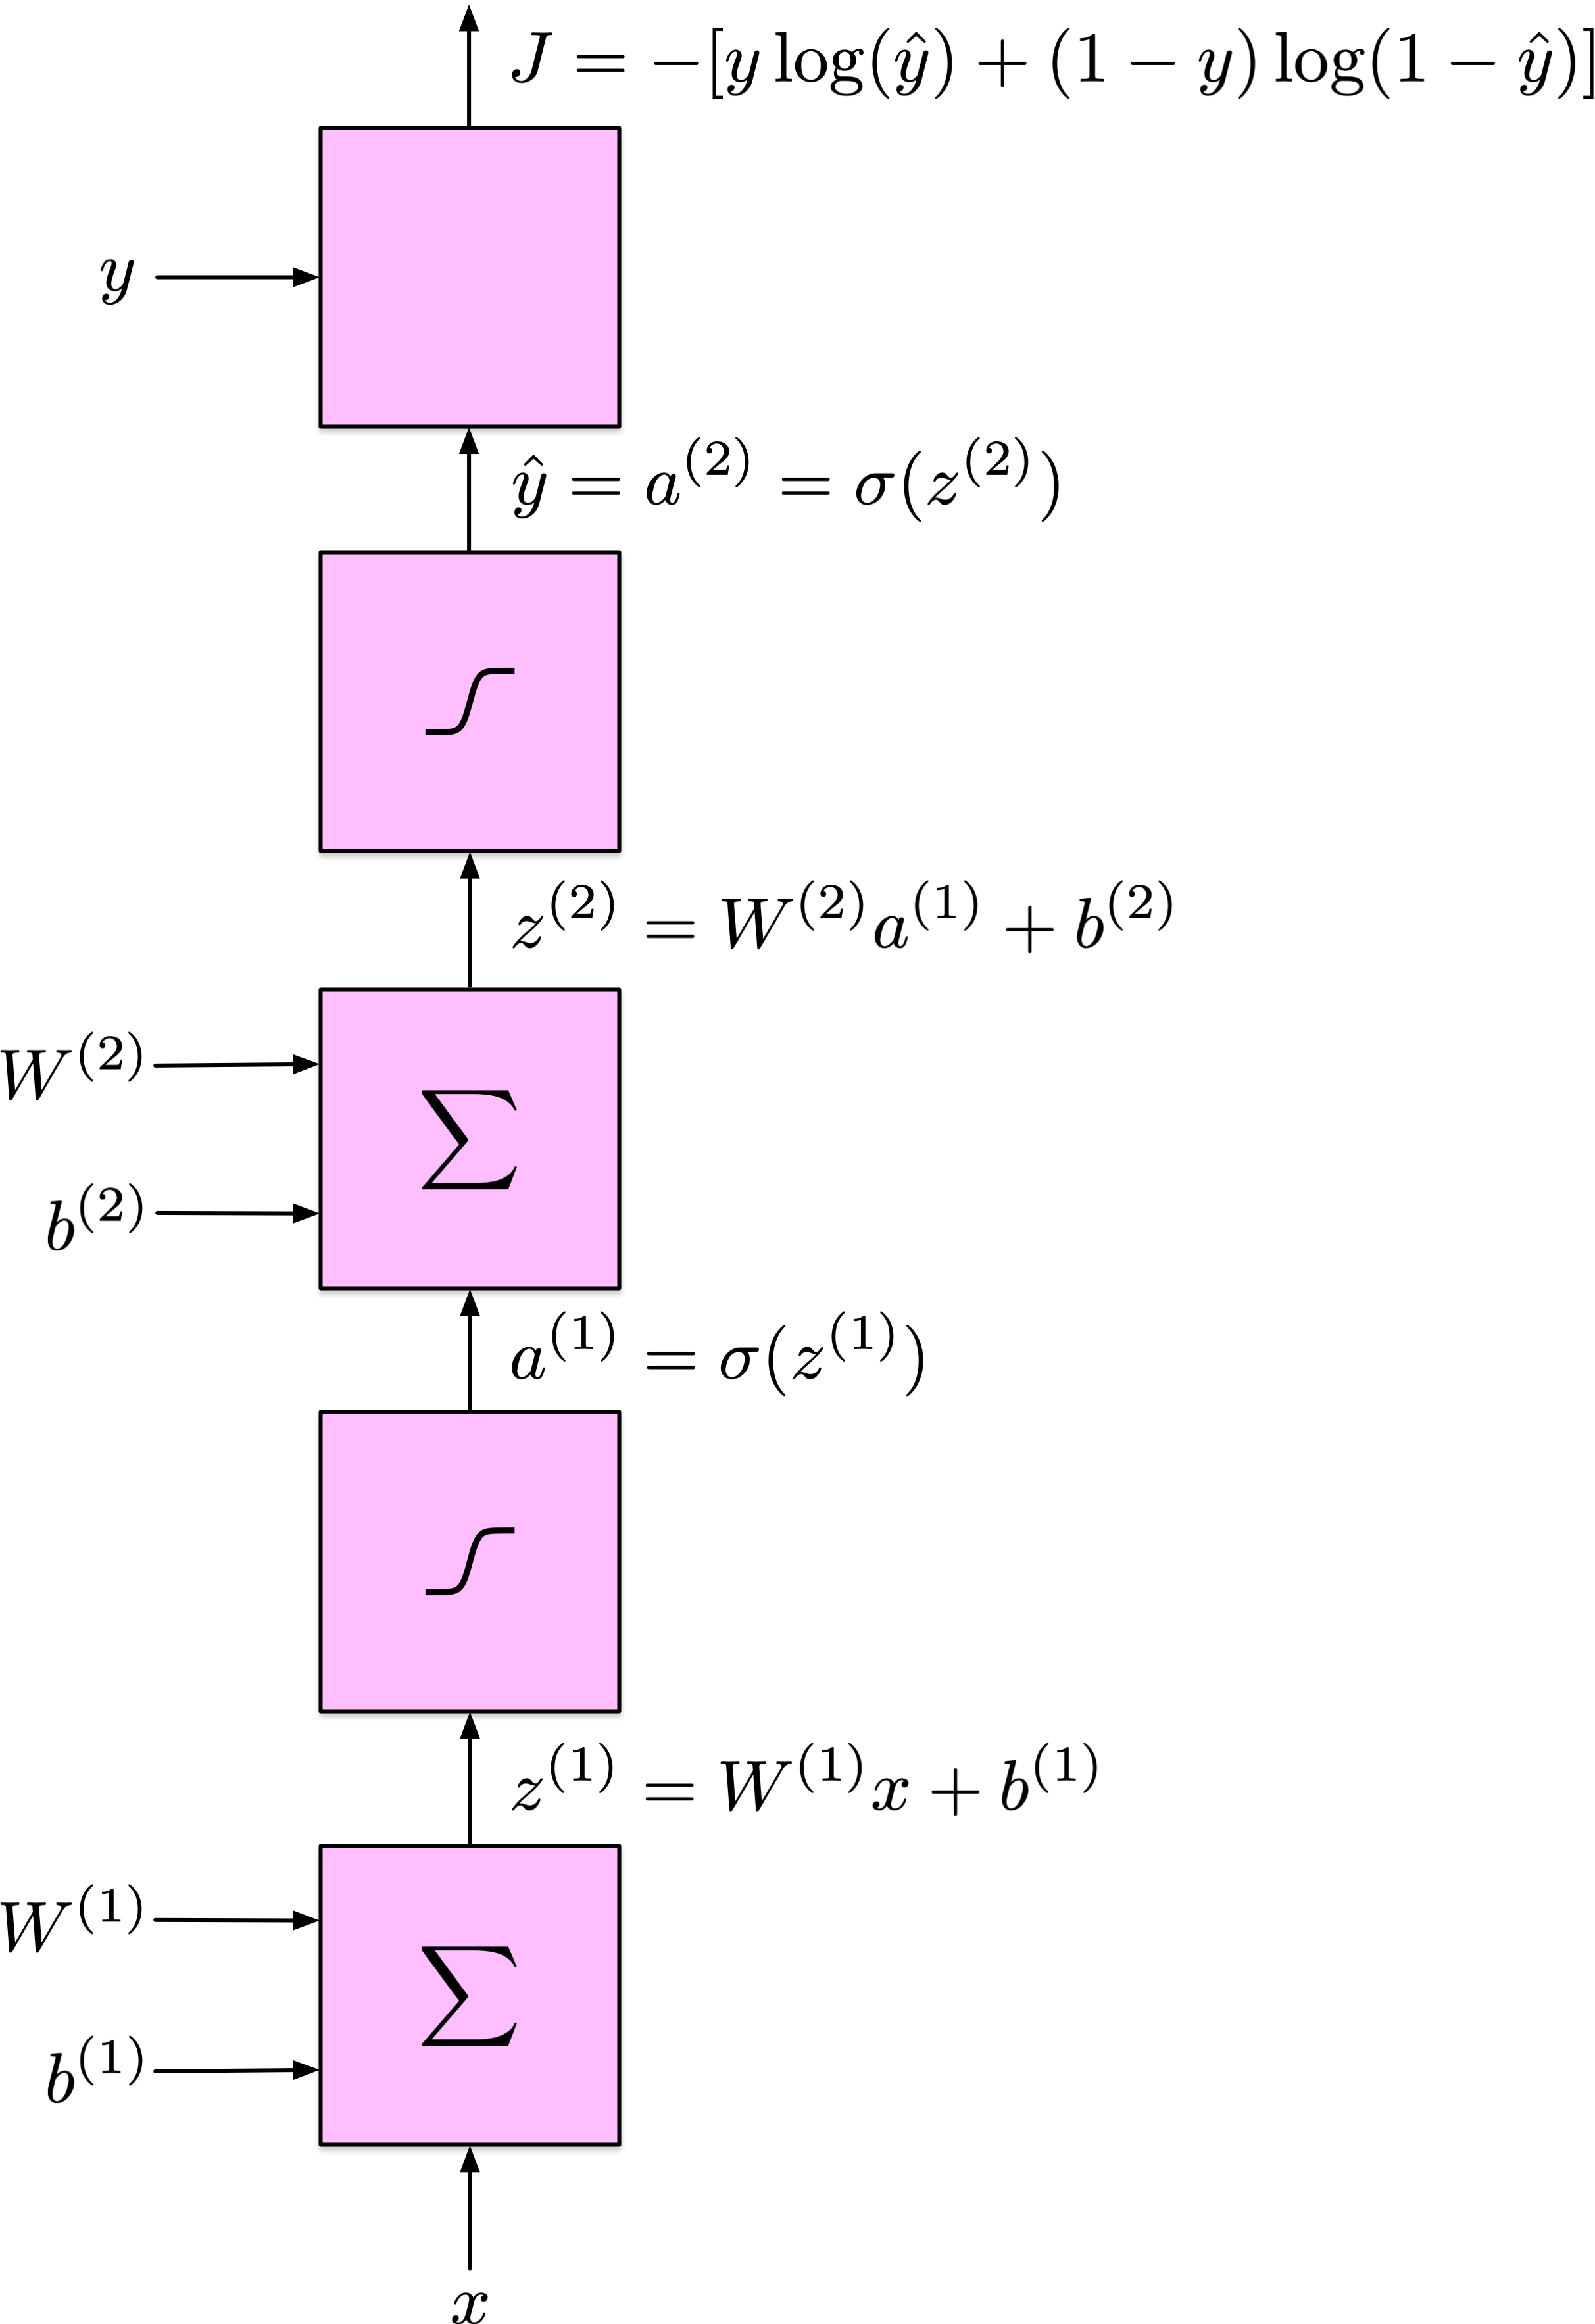

## Dérivées

Dérivée $z_1 = w_1 x + b_1$ :

$$
    \frac{\partial z_1}{\partial w_1}=x, \quad \frac{\partial z_1}{\partial b_1}=1, \quad \frac{\partial z_1}{\partial x} = w_1
$$

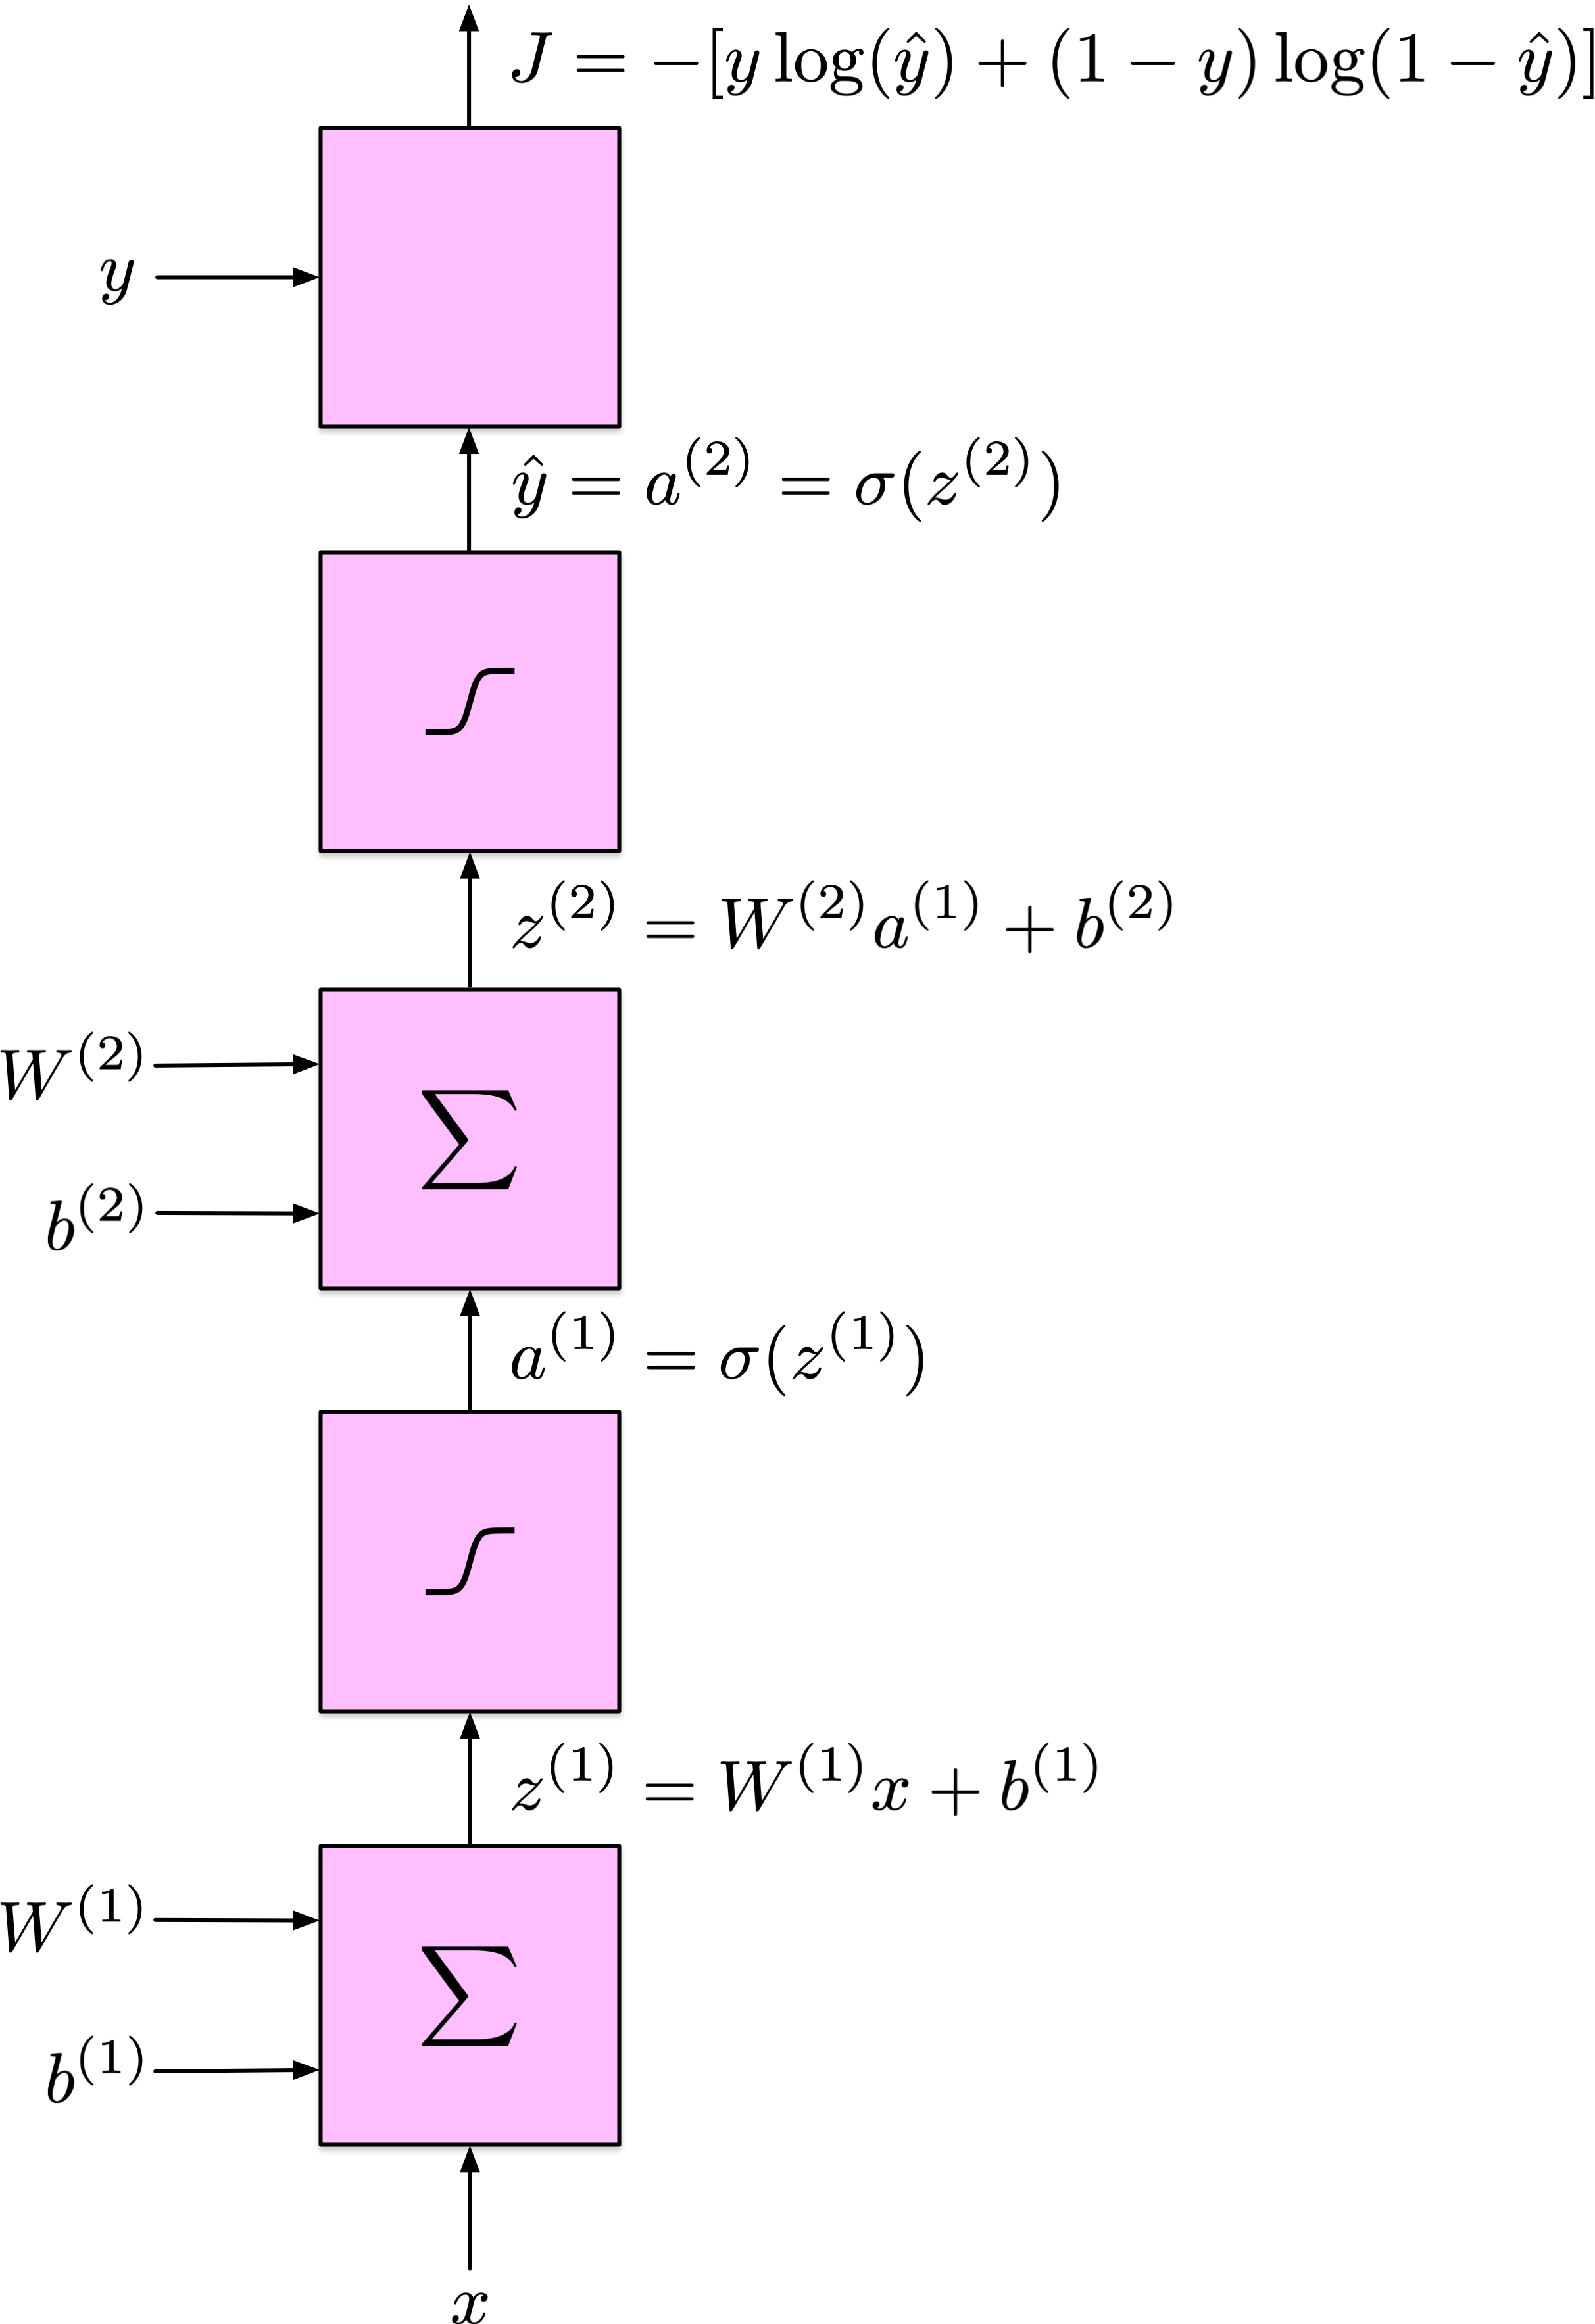

## Dérivées combinées

Pour $w_2$ :

$$
    \frac{\partial J}{\partial w_2}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial w_2}=\left[-\left(\frac{y}{\hat{y}}-\frac{1-y}{1-\hat{y}}\right)\right] \cdot(\hat{y}(1-\hat{y})) \cdot a_1
$$

Se simplifie en :

$$
  \frac{\partial J}{\partial w_2}=(\hat{y}-y) a_1
$$

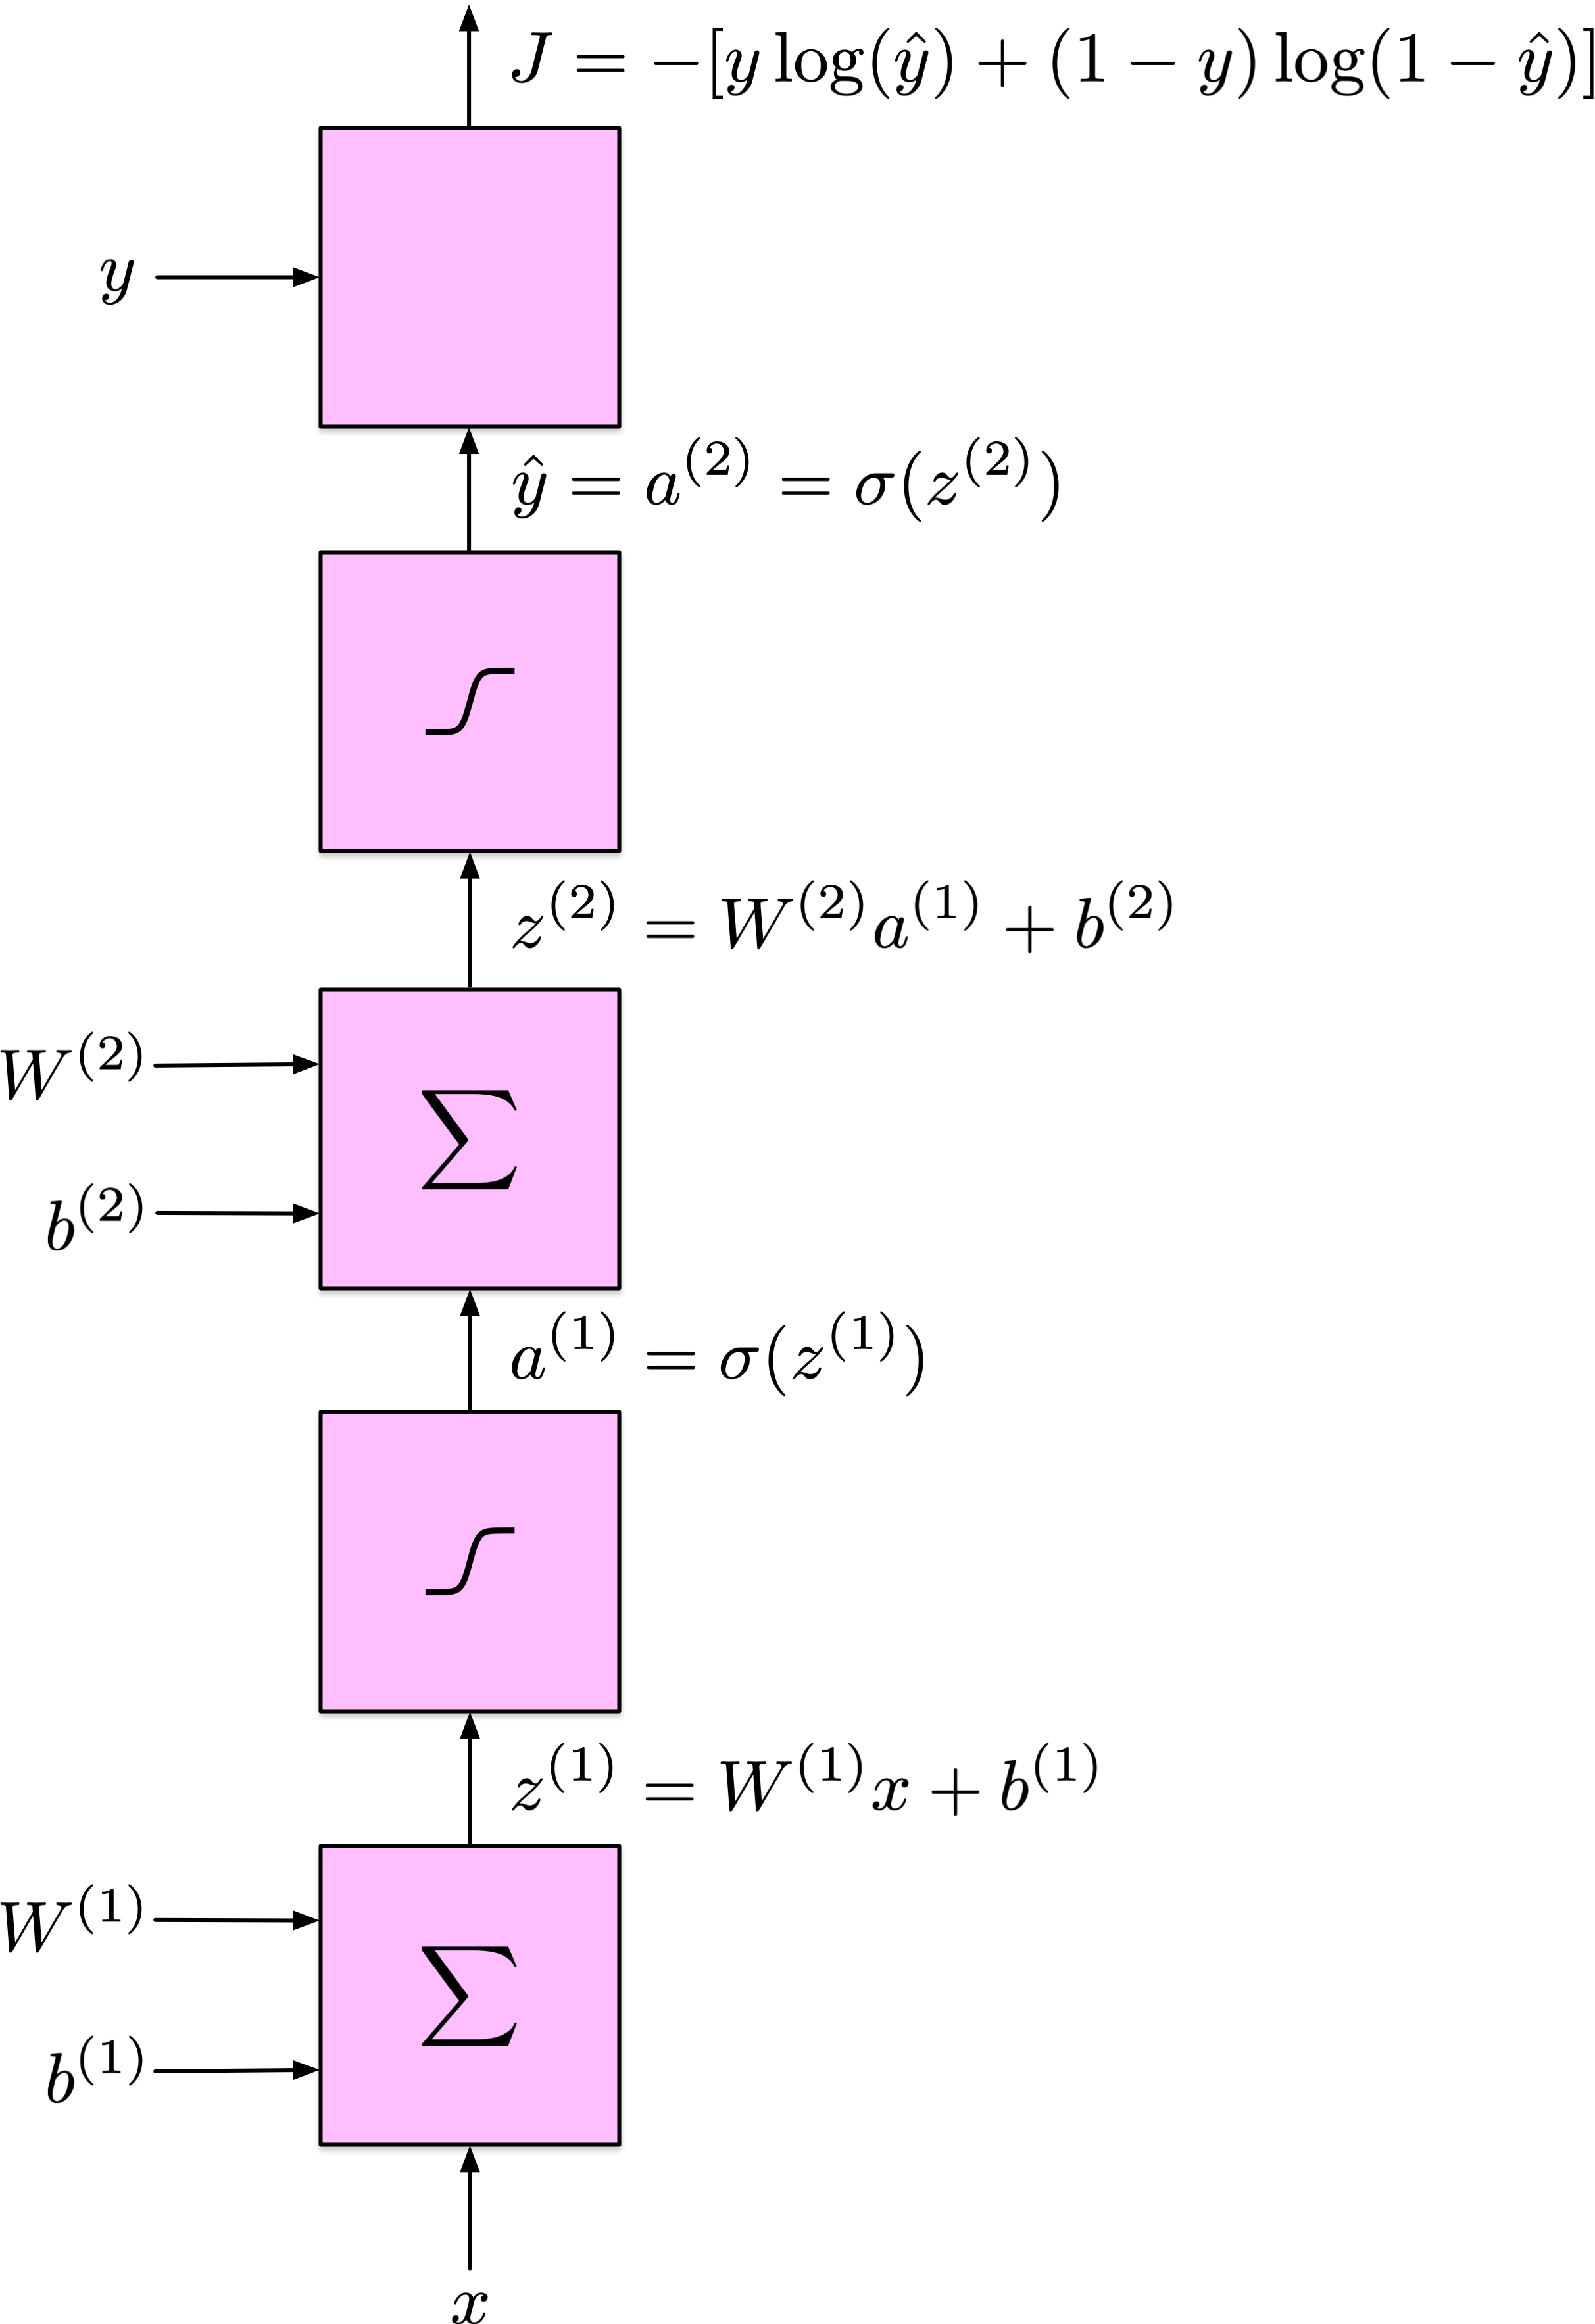

## Dérivées combinées

Pour $b_2$ :

$$
    \frac{\partial J}{\partial b_2}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial b_2}=(\hat{y}-y) \cdot 1=\hat{y}-y
$$

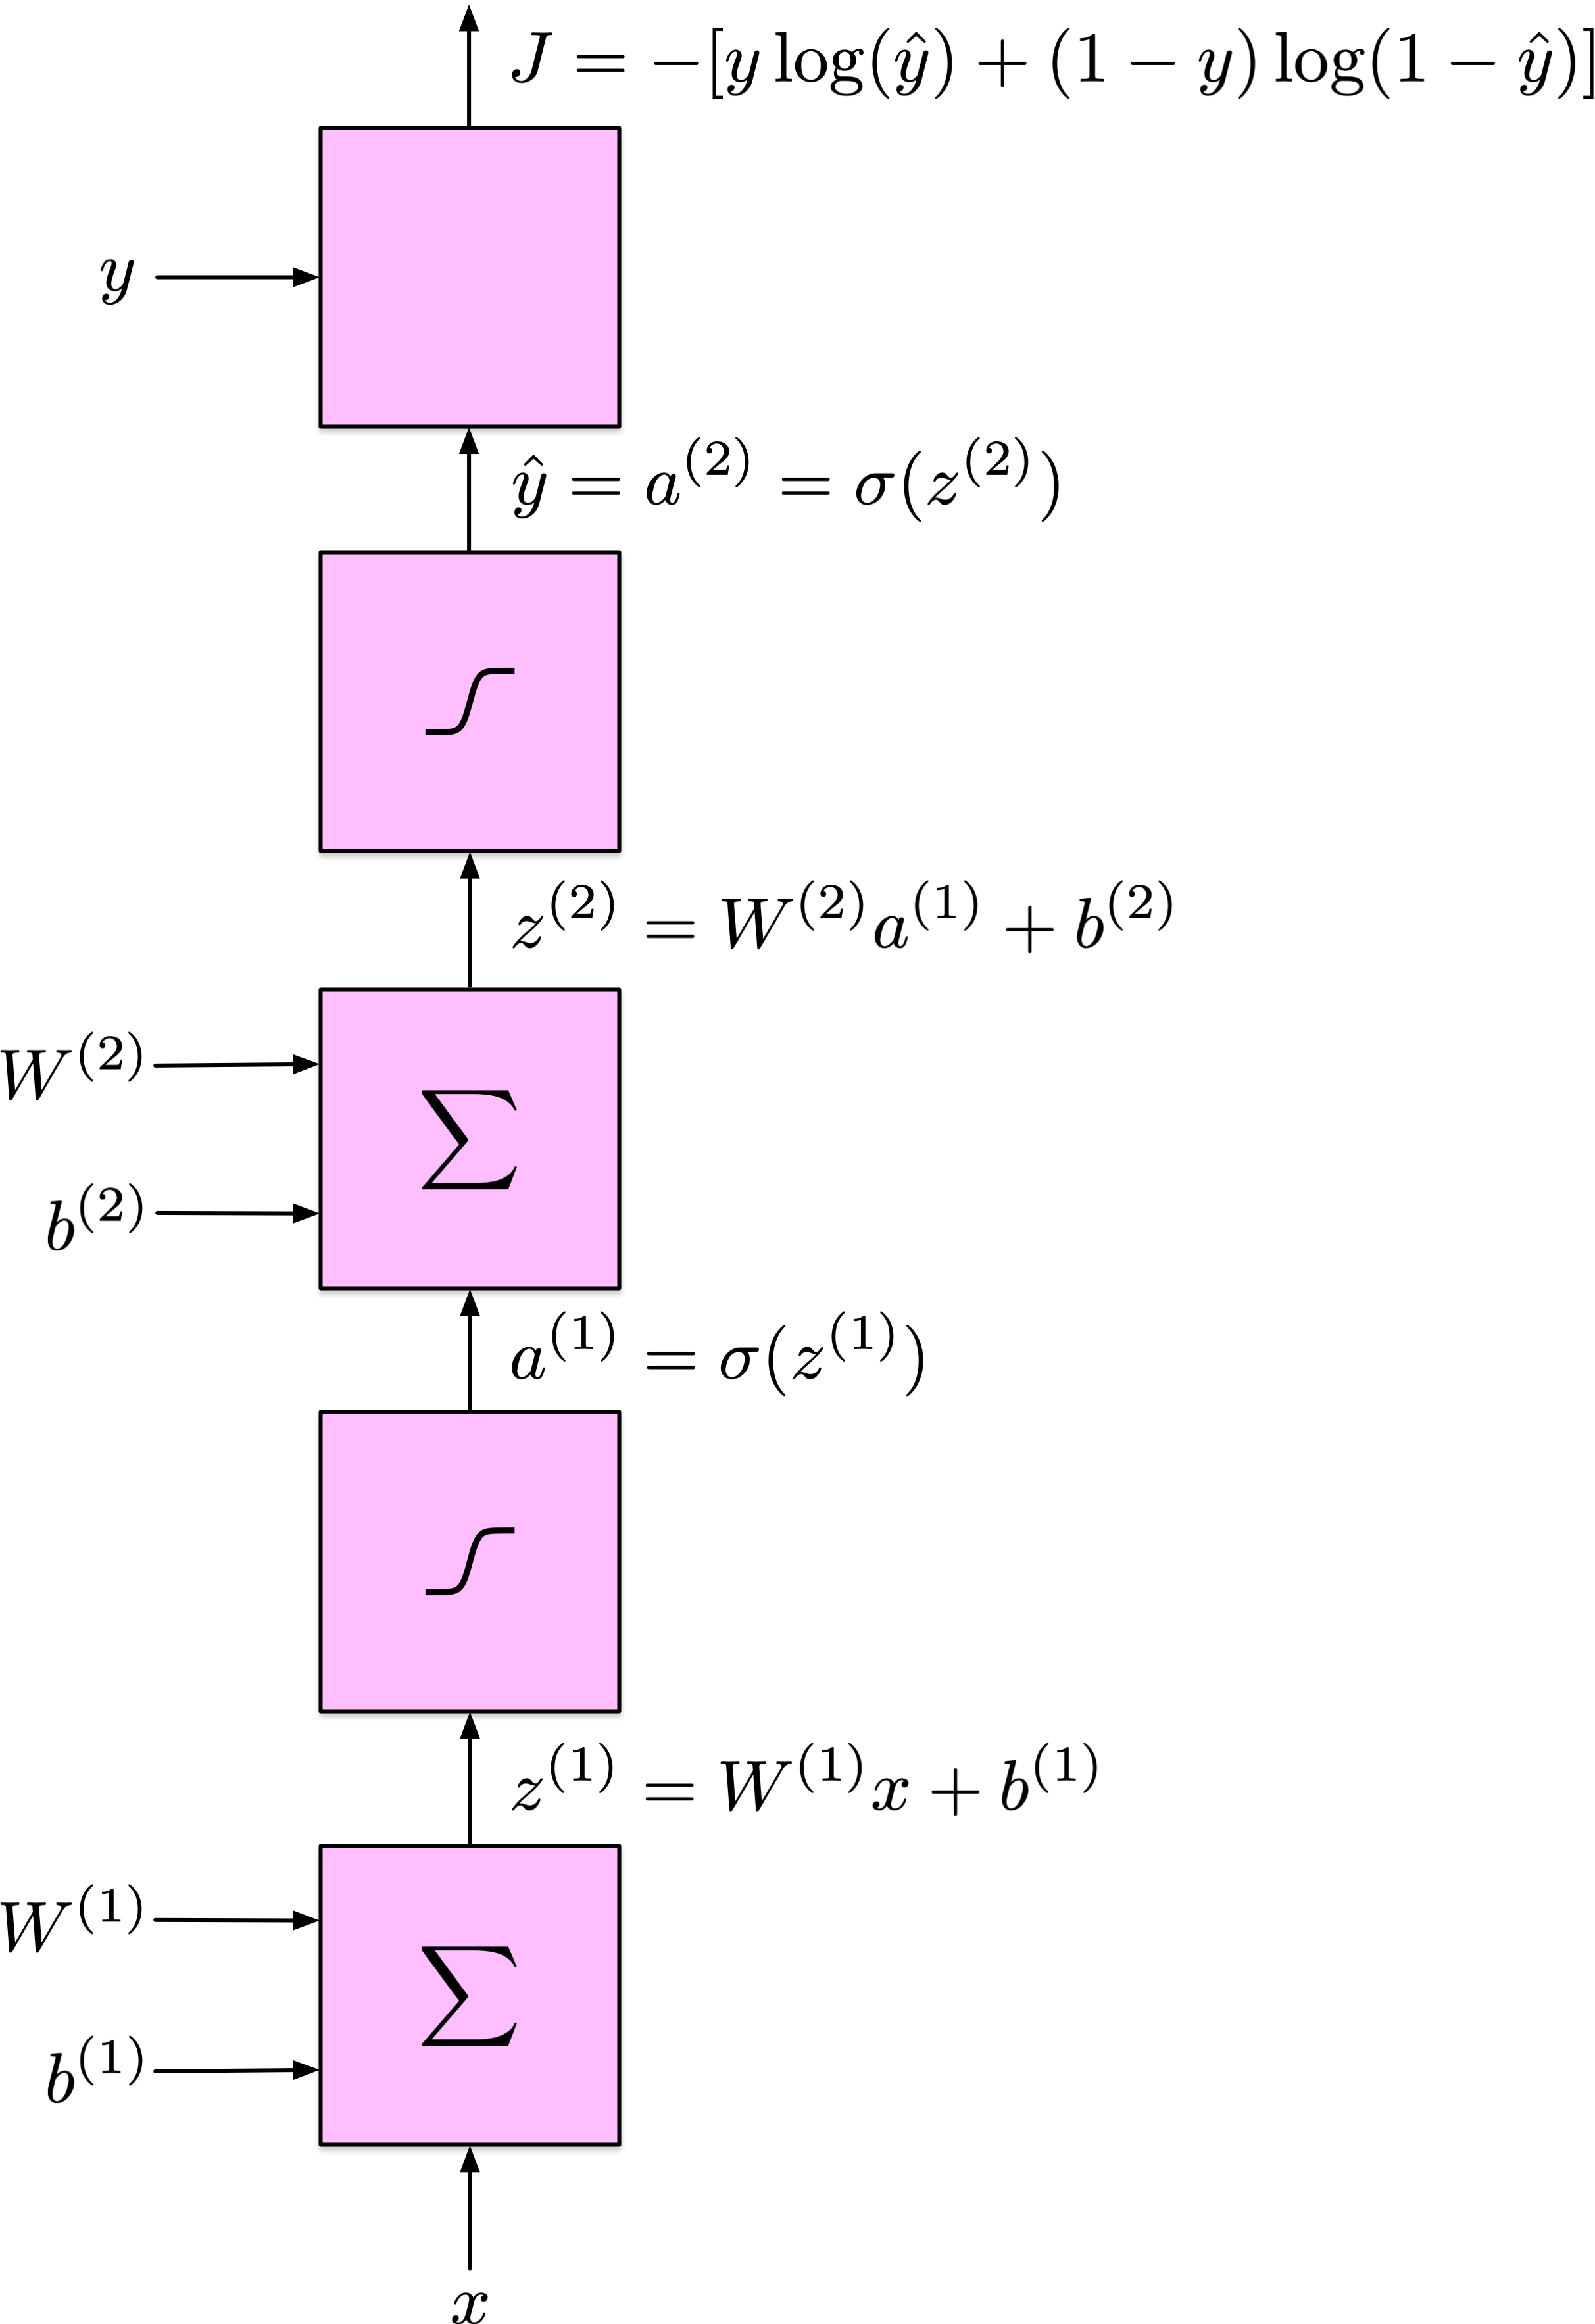

## Dérivées combinées

Pour $w_1$ :

$$
    \frac{\partial J}{\partial w_1}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}
$$

Substituer :

$$
   =\left[-\left(\frac{y}{\hat{y}}-\frac{1-y}{1-\hat{y}}\right)\right] \cdot(\hat{y}(1-\hat{y})) \cdot w_2 \cdot\left(a_1\left(1-a_1\right)\right) \cdot x
$$

Se simplifie à :

$$
  \frac{\partial J}{\partial w_1}=(\hat{y}-y) w_2\left(a_1\left(1-a_1\right)\right) x
$$

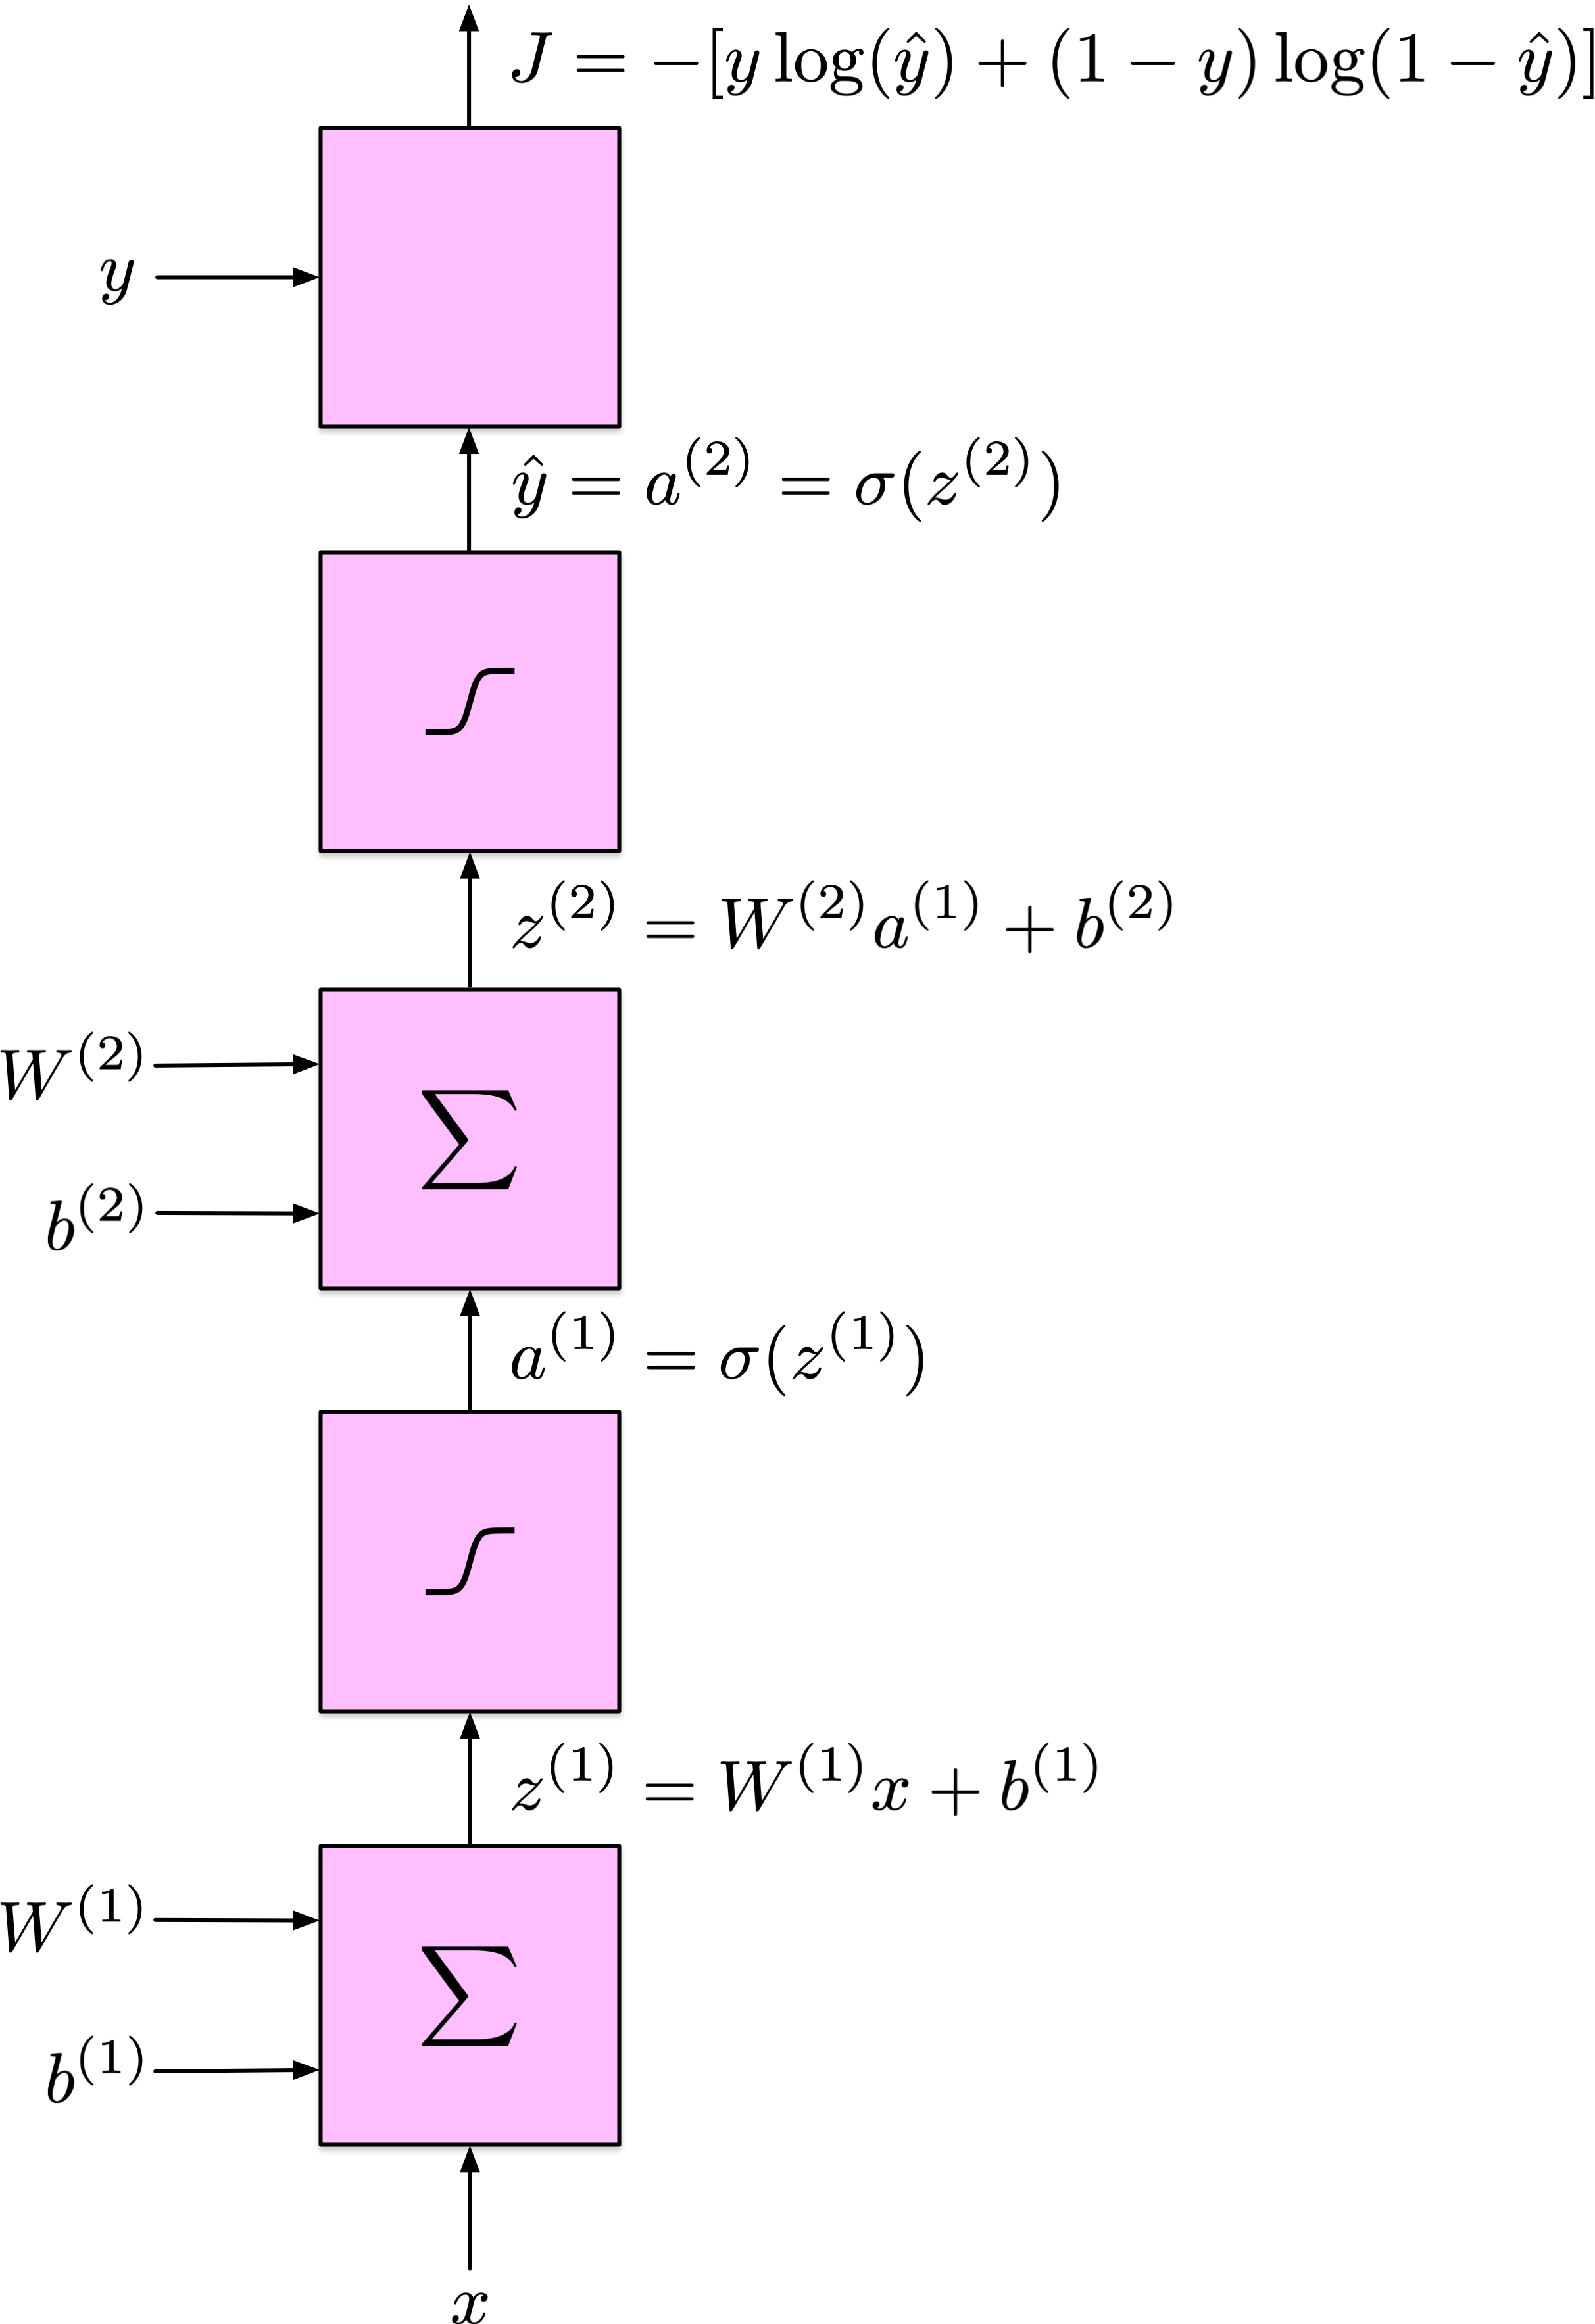

## Dérivées combinées

Pour $b_1$ :

$$
  \frac{\partial J}{\partial b_1}=\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial b_1}
$$

Substituer :

$$
=(\hat{y}-y) w_2\left(a_1\left(1-a_1\right)\right) \cdot 1
$$

Se simplifie à :

$$
  \frac{\partial J}{\partial b_1}=(\hat{y}-y) w_2\left(a_1\left(1-a_1\right)\right)
$$

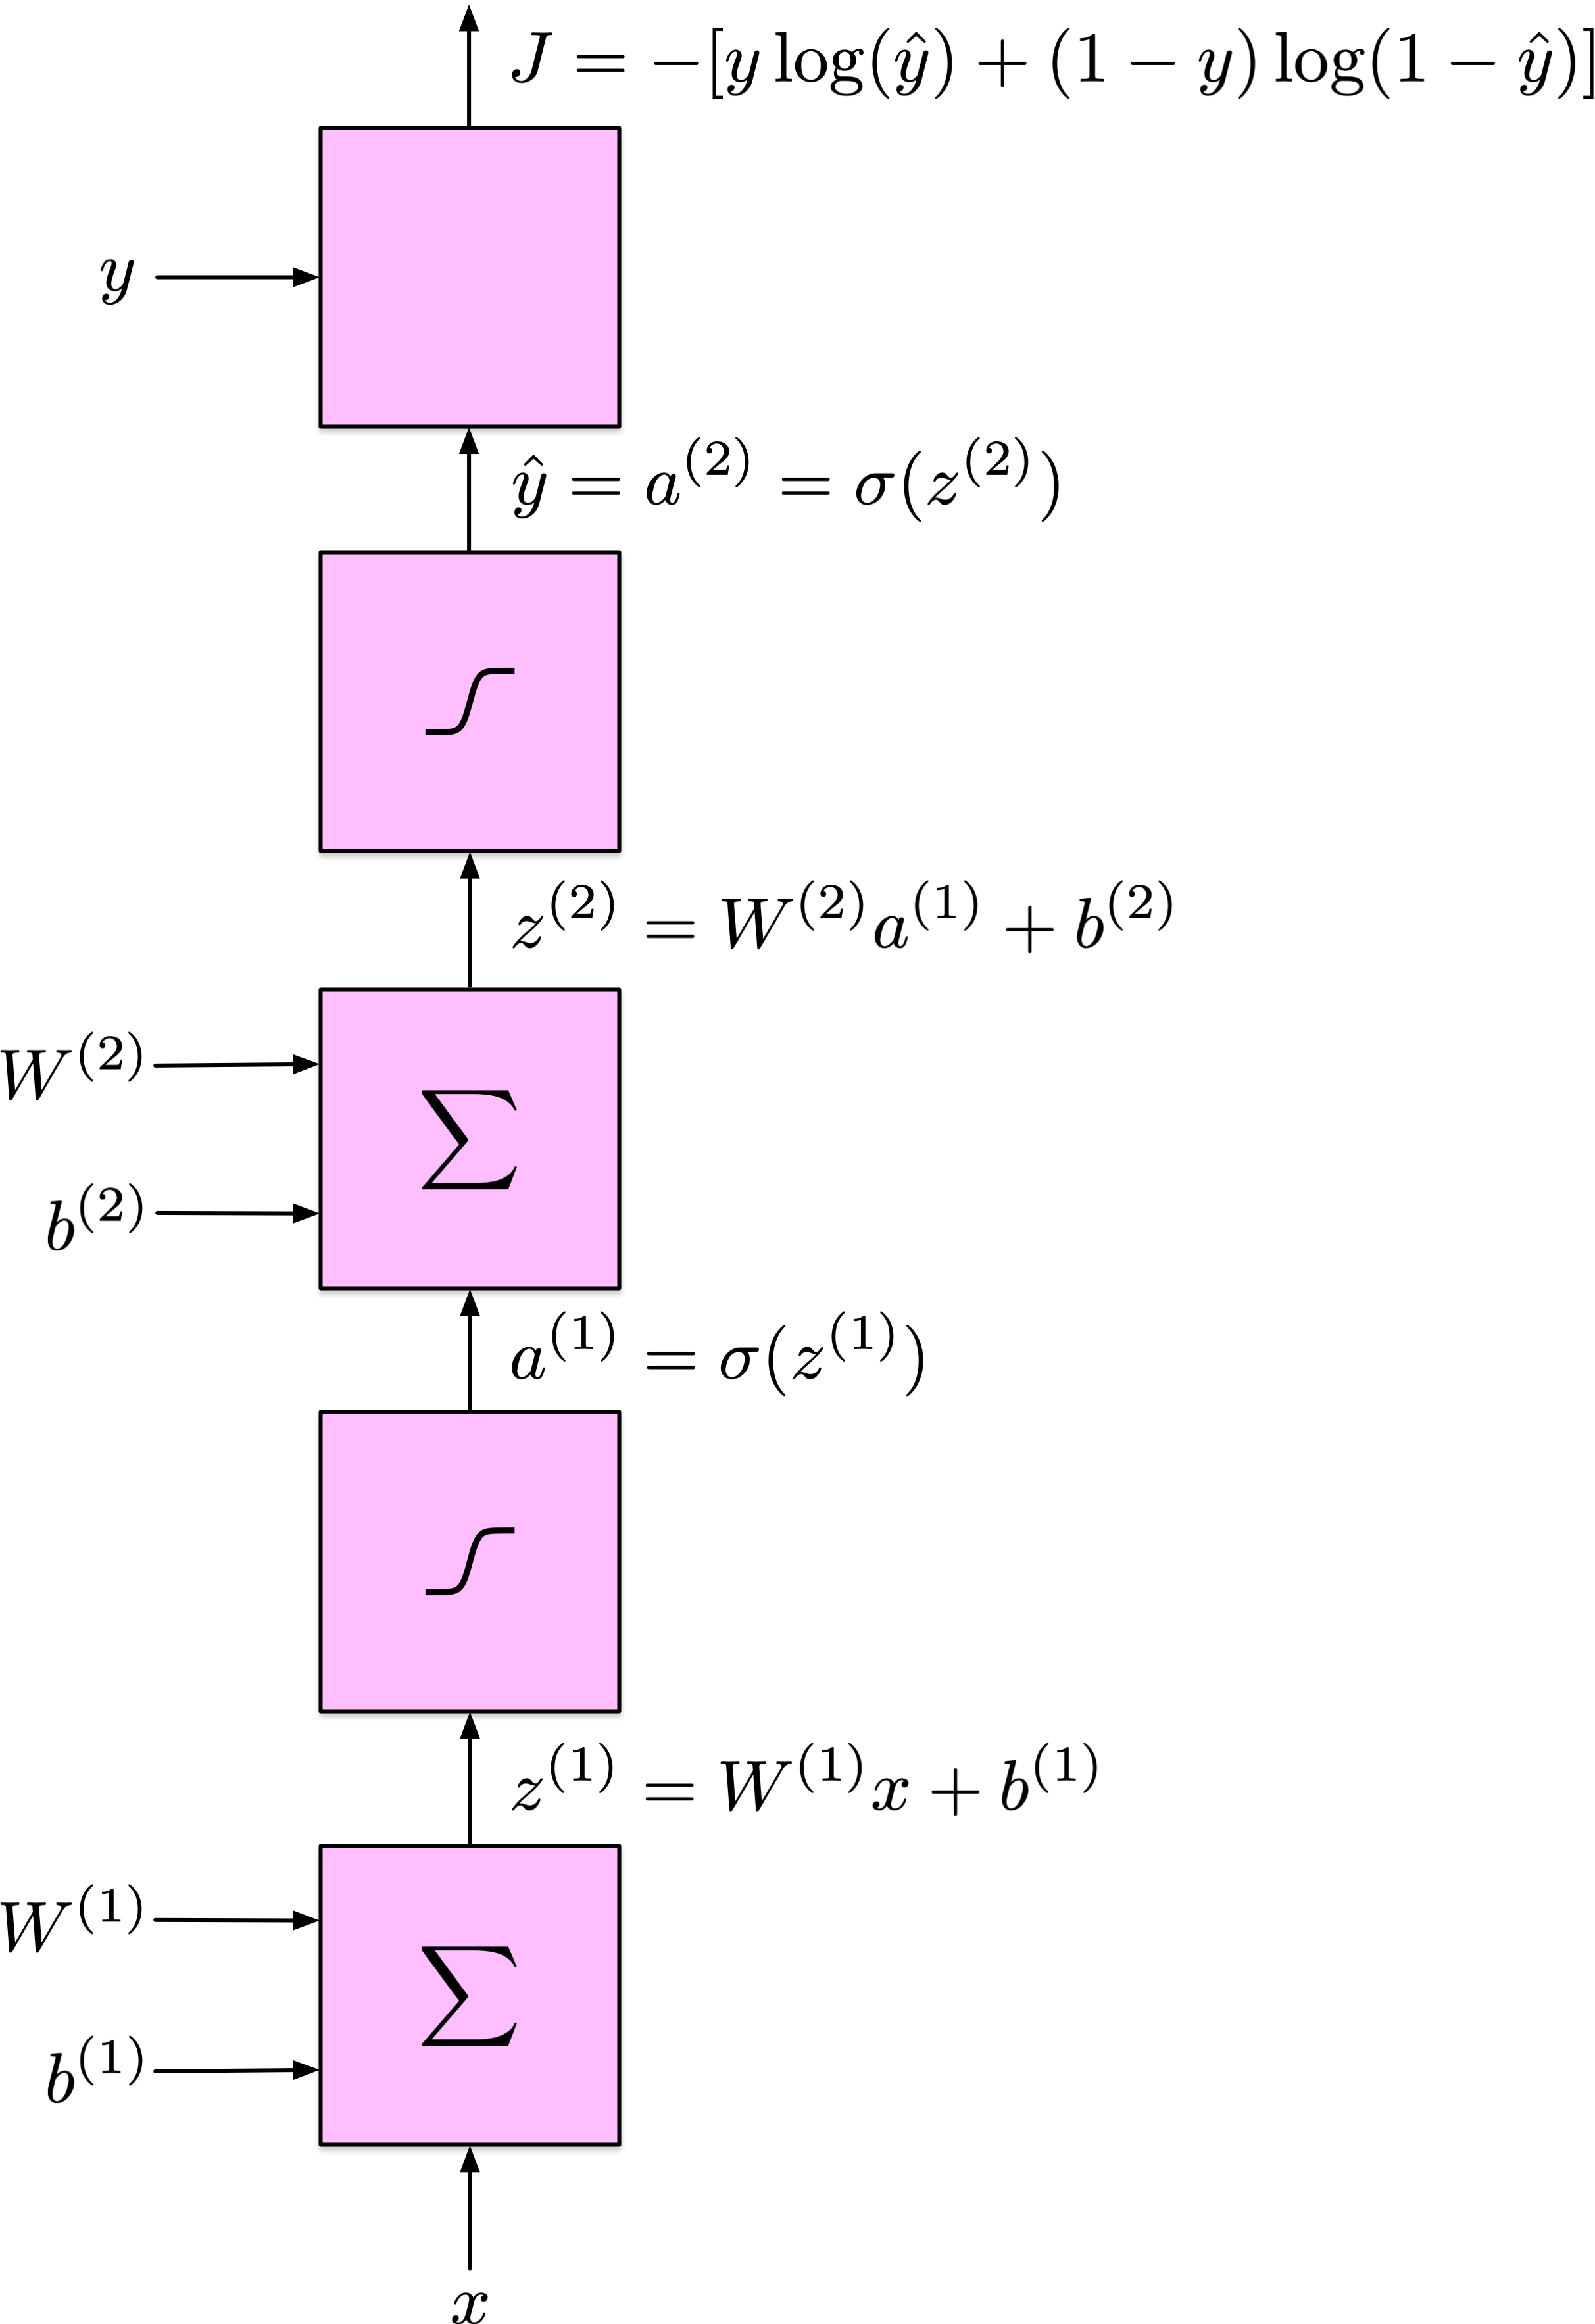

## Dérivées clés

$$
\begin{align}
  \frac{\partial J}{\partial w_2} & = (\hat{y}-y) a_1 \\
  \frac{\partial J}{\partial b_2} & = \hat{y}-y \\
  \frac{\partial J}{\partial w_1} & = (\hat{y}-y) w_2\left(a_1\left(1-a_1\right)\right) x \\
  \frac{\partial J}{\partial b_1} & = (\hat{y}-y) w_2\left(a_1\left(1-a_1\right)\right) \\
\end{align}
$$

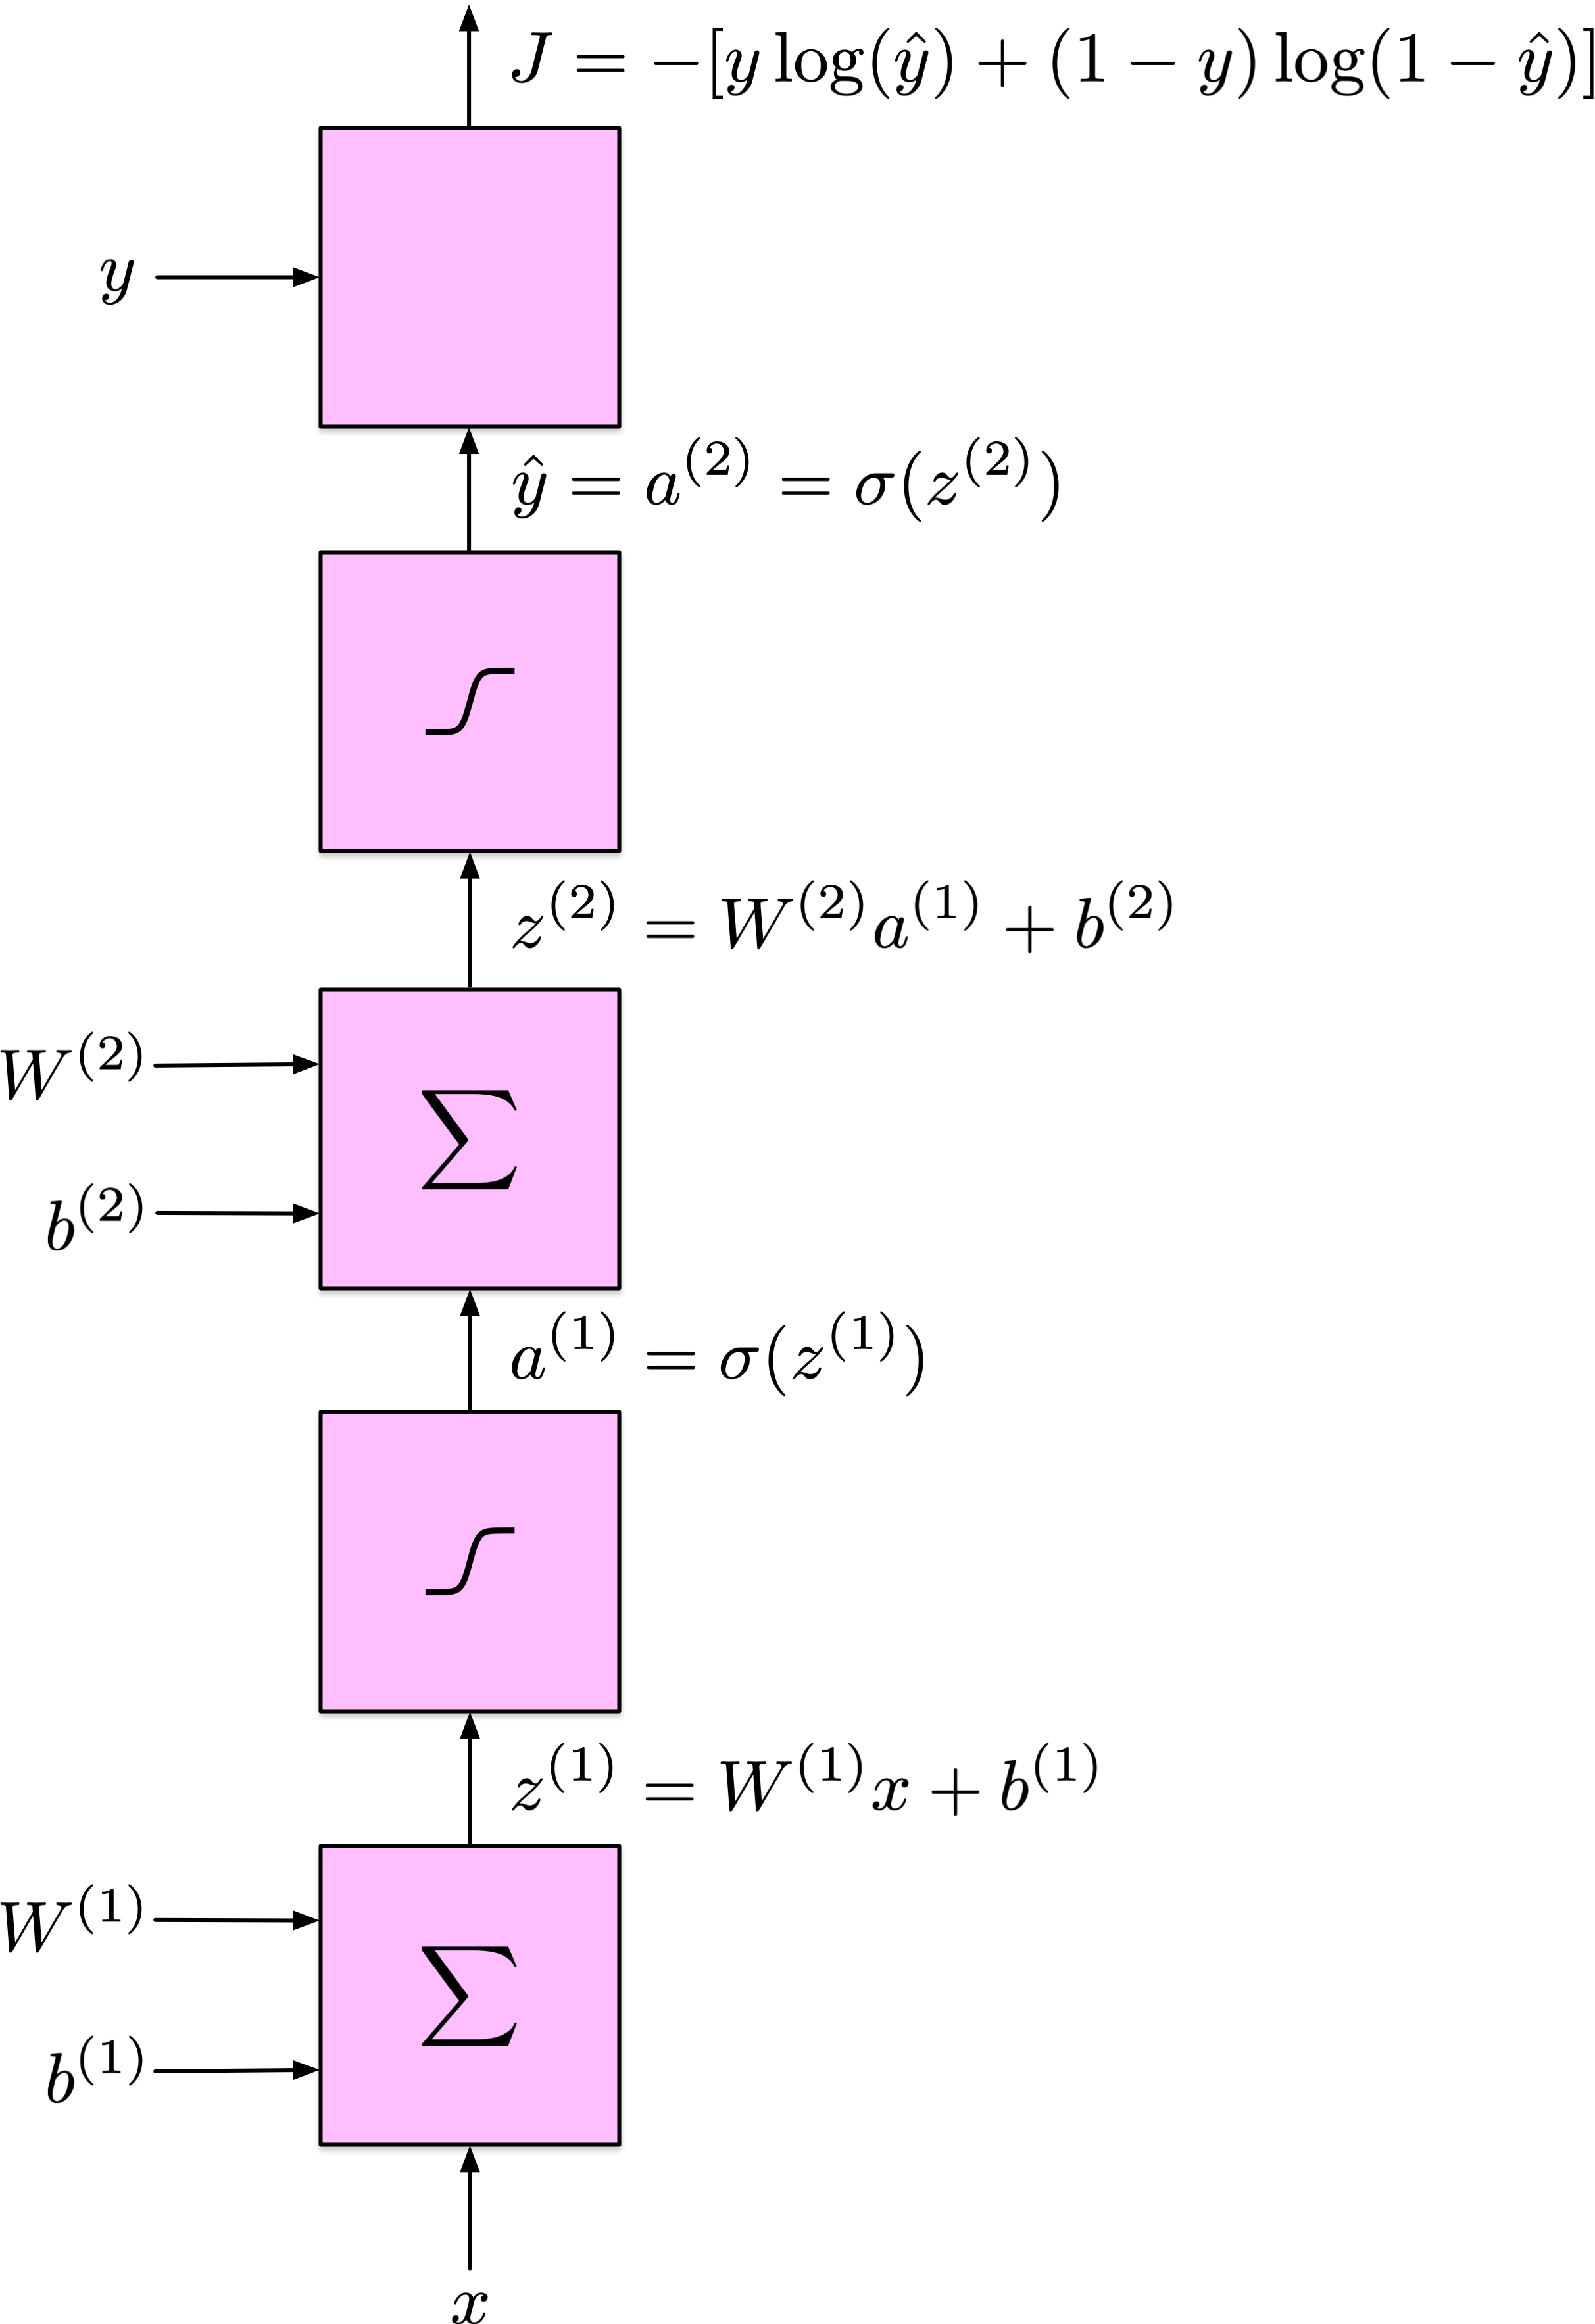

**Observation 1 :** Le calcul des gradients clés nécessite les valeurs
d’activation de toutes les couches, spécifiquement $a_1$ et
$\hat{y} = a_2$.

## Exploration

In [3]:
import math
import random

random.seed(42)

def sigma(x):
    return 1 / (1 + math.exp(-x))

alpha = 0.1

def init():

    global w1, w2, b1, b2

    w1 = random.random()
    w2 = random.random()
    b1 = 0
    b2 = 0

Nous considérons un modèle de réseau de neurones simple. Il accepte une
seule entrée scalaire, notée $x$, et comprend un seul nœud caché
caractérisé par un poids $w_1$ et un biais $b_1$. Il inclut également un
nœud de sortie avec un poids $w_2$ et un biais $b_2$. Au total, le
réseau contient quatre paramètres entraînables.

## Forward

In [4]:
def forward():

    global z1, w1, x, b1, a1, z2, J, y_hat

    z1 = w1 * x + b1
    a1 = sigma(z1)

    z2 = w2 * a1 + b2
    a2 = sigma(z2)

    y_hat = a2

    J = -(y * math.log(y_hat) + (1-y) * math.log(1 - y_hat))

Lors du passage en avant, les calculs progressent de manière
séquentielle à travers chaque couche, en calculant les valeurs de
préactivation et d’activation, notées `z1`, `a1`, `z2` et `a2`. La
valeur `a2` représente la sortie du modèle, qui est ensuite utilisée
pour déterminer la perte.

## Rétropropagation

In [5]:
def backward():

    global alpha, w1, b1, w2, b2, a1, z1, z2, y, y_hat

    grad_J_w2 = (y_hat - y) * a1
    grad_J_b2 = y_hat - y

    grad_J_w1 = (y_hat - y) * w2 * (a1 * (1-a1)) * x
    grad_J_b1 = (y_hat - y) * w2 * (a1 * (1-a1))

    w2 = w2 - alpha * grad_J_w2
    b2 = b2 - alpha * grad_J_b2

    w1 = w1 - alpha * grad_J_w1
    b1 = b1 - alpha * grad_J_b1

Lors de la rétropropagation, les dérivées partielles, ou gradients, sont
calculées pour chacun des quatre paramètres. Ensuite, ces gradients sont
utilisés pour mettre à jour les poids correspondants par un processus
appelé mise à jour par gradient.

## Entraînement

In [6]:
init()

x = 3.14
y = 1

forward()
print(f"Avant : y_hat = {y_hat:.2}, loss = {J:.2}")

for i in range(500):
    forward()
    backward()

forward()
print(f"Après : y_hat = {y_hat:.2}, loss = {J:.2}")

Avant : y_hat = 0.51, loss = 0.68
Après : y_hat = 0.99, loss = 0.01

Le processus d’entraînement que nous avons mis en œuvre est basé sur une
seule instance de données. En l’état actuel, notre architecture de
réseau de base est limitée au traitement de cet unique exemple,
principalement en raison de la nature codée en dur de la fonction de
perte, qui est spécifiquement conçue pour un seul input. Cependant, vous
pouvez expérimenter avec divers paramètres pour observer leurs effets
sur la performance du modèle. Ces paramètres incluent la définition de
`y=0`, l’ajustement de la valeur d’entrée `x`, la modification du taux
d’apprentissage `alpha`, ou le changement du nombre d’époques
d’entraînement.

## Dérivées clés

$$
\begin{align}
  \frac{\partial J}{\partial w_2} & =  \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial w_2}\\
  \frac{\partial J}{\partial b_2} & =  \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial b_2}\\
  \frac{\partial J}{\partial w_1} & =  \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial w_1}\\
  \frac{\partial J}{\partial b_1} & =  \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1} \cdot \frac{\partial z_1}{\partial b_1}\\
\end{align}
$$

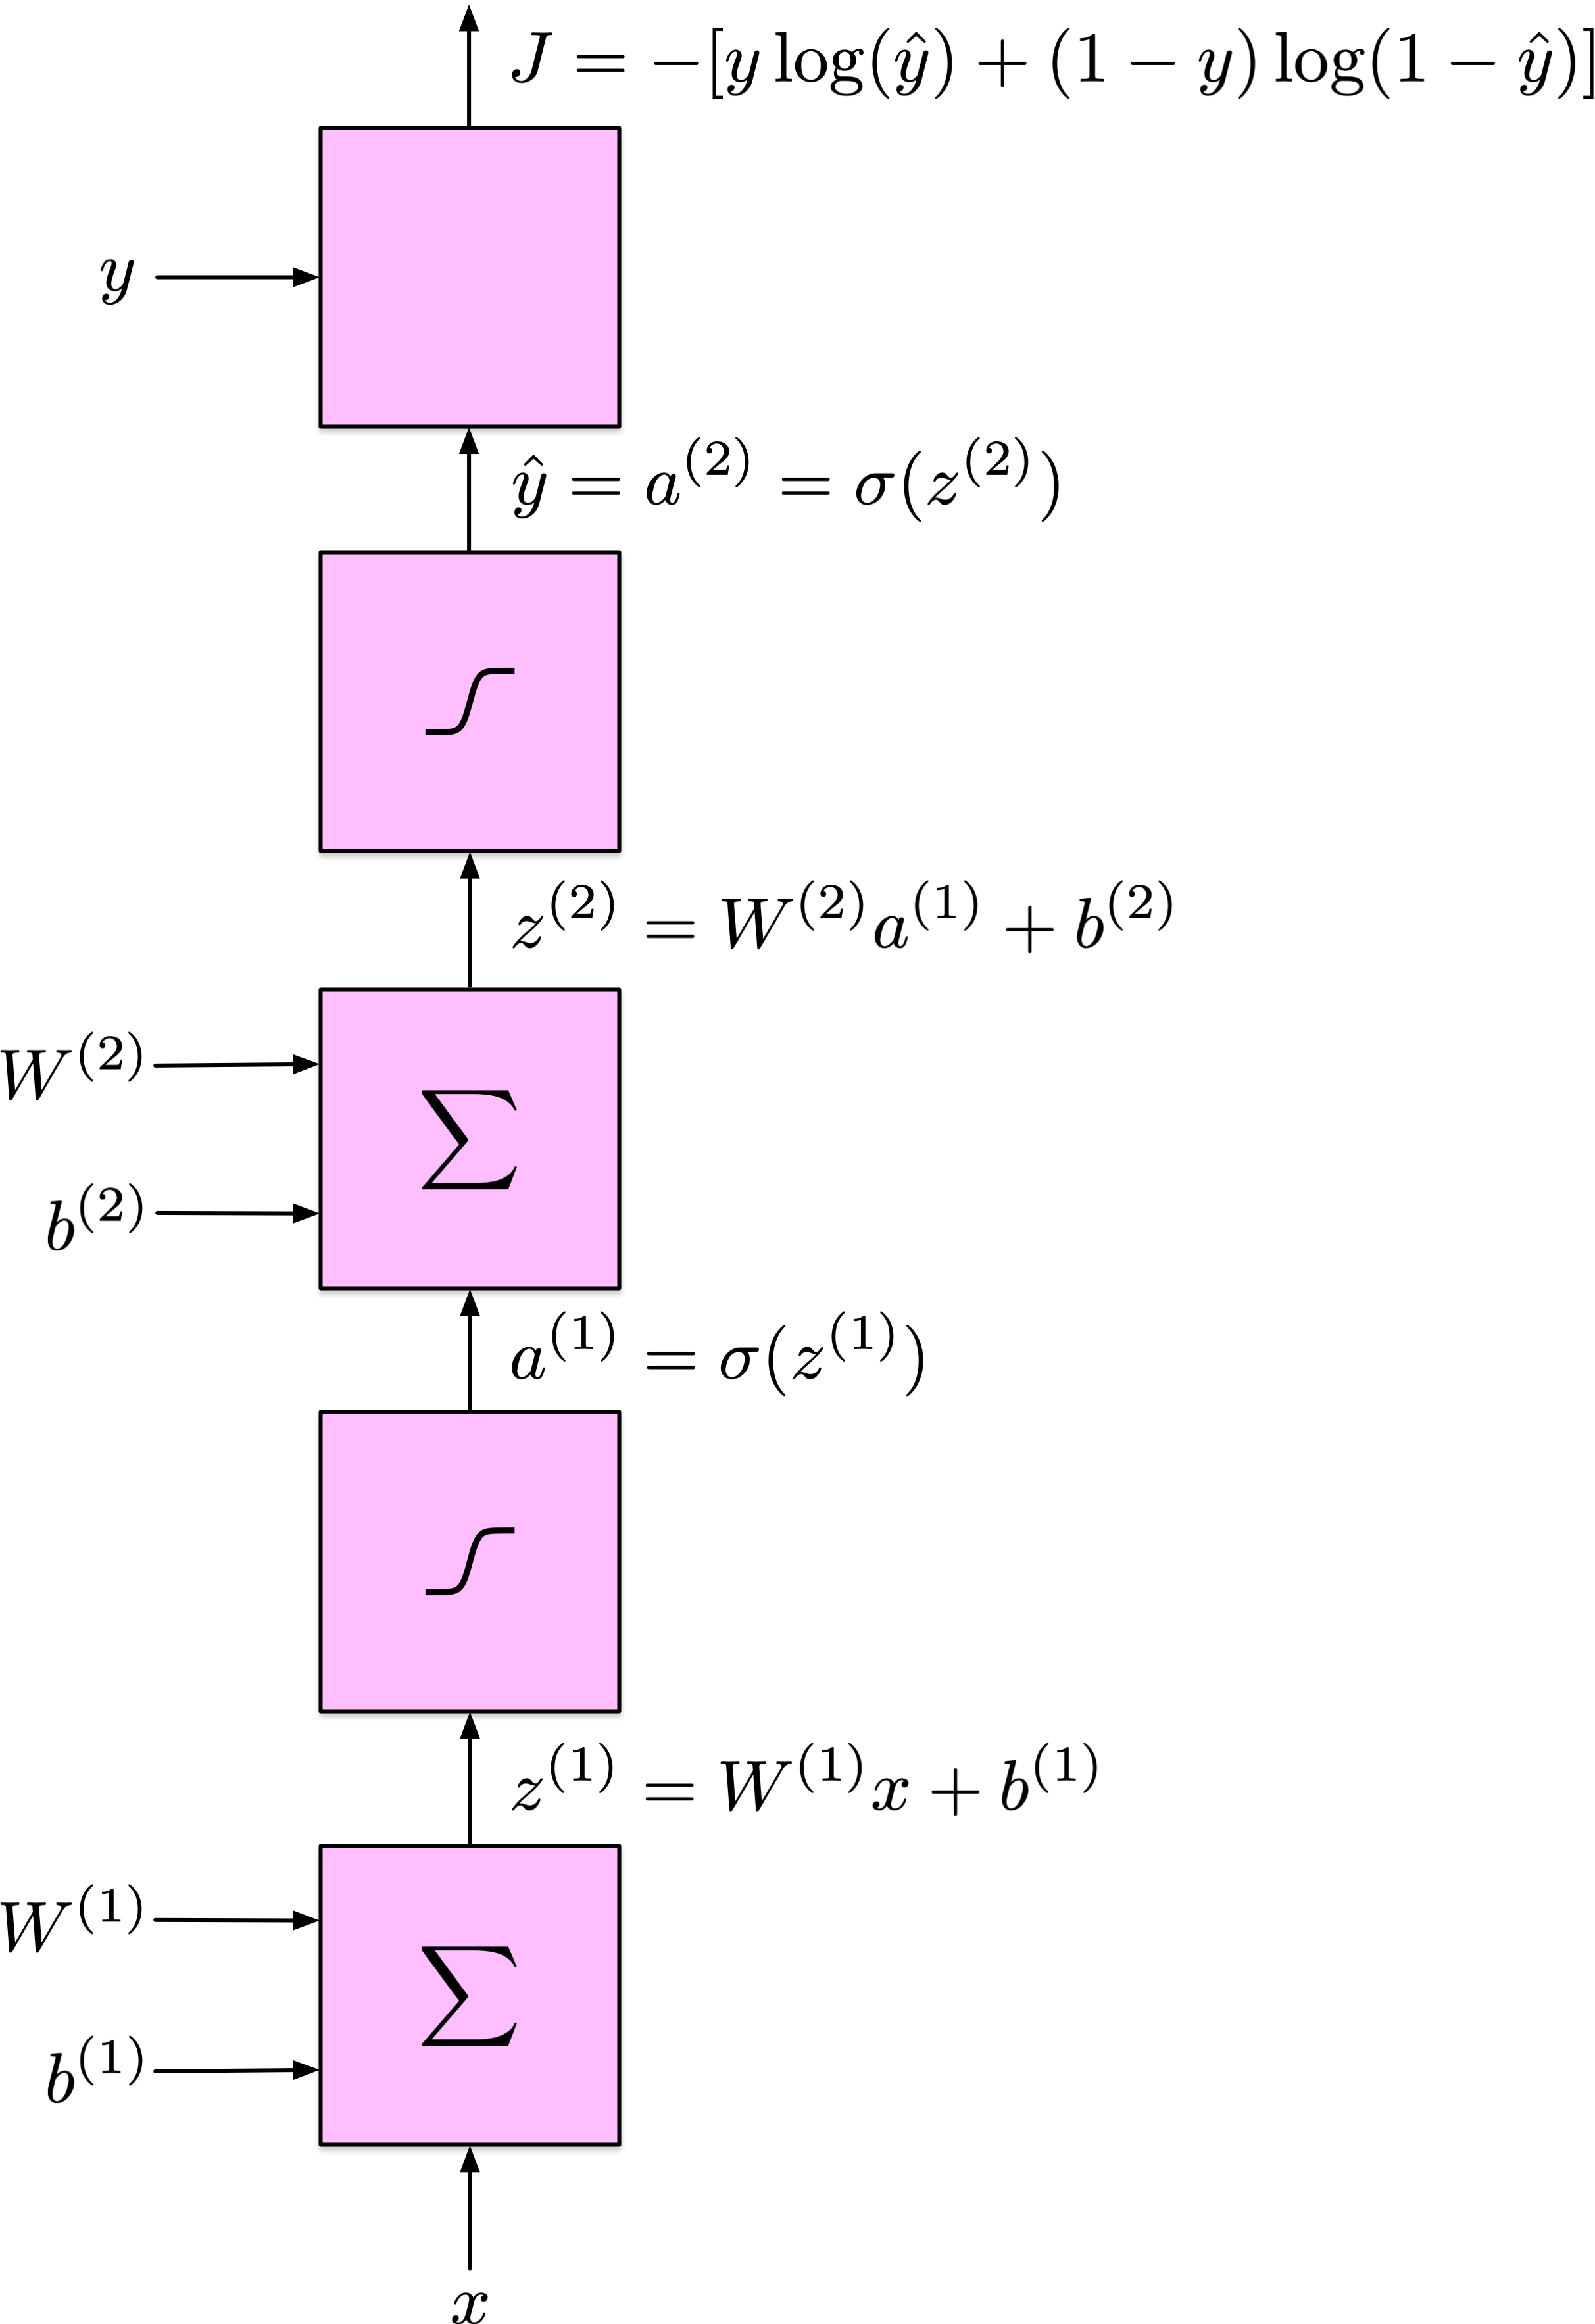

**Observation 2 :** Remarquez comment certaines dérivées, telles que
$\frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2}$,
sont calculées plusieurs fois.

Il n’est guère surprenant, étant donné que ces chaînes suivent le même
chemin dans le graphe computationnel.

## Dérivées clés

Soit $$
\begin{align}
\delta_1 & = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2} \\
\delta_2 & = \delta_1 \cdot \frac{\partial z_2}{\partial a_1} \cdot \frac{\partial a_1}{\partial z_1}
\end{align}
$$

Réécrire $$
\begin{align}
  \frac{\partial J}{\partial w_2} & =  \delta_1 \cdot \frac{\partial z_2}{\partial w_2}\\
  \frac{\partial J}{\partial b_2} & =  \delta_1 \cdot \frac{\partial z_2}{\partial b_2}\\
  \frac{\partial J}{\partial w_1} & =  \delta_2 \cdot \frac{\partial z_1}{\partial w_1}\\
  \frac{\partial J}{\partial b_1} & =  \delta_2 \cdot \frac{\partial z_1}{\partial b_1}\\
\end{align}
$$

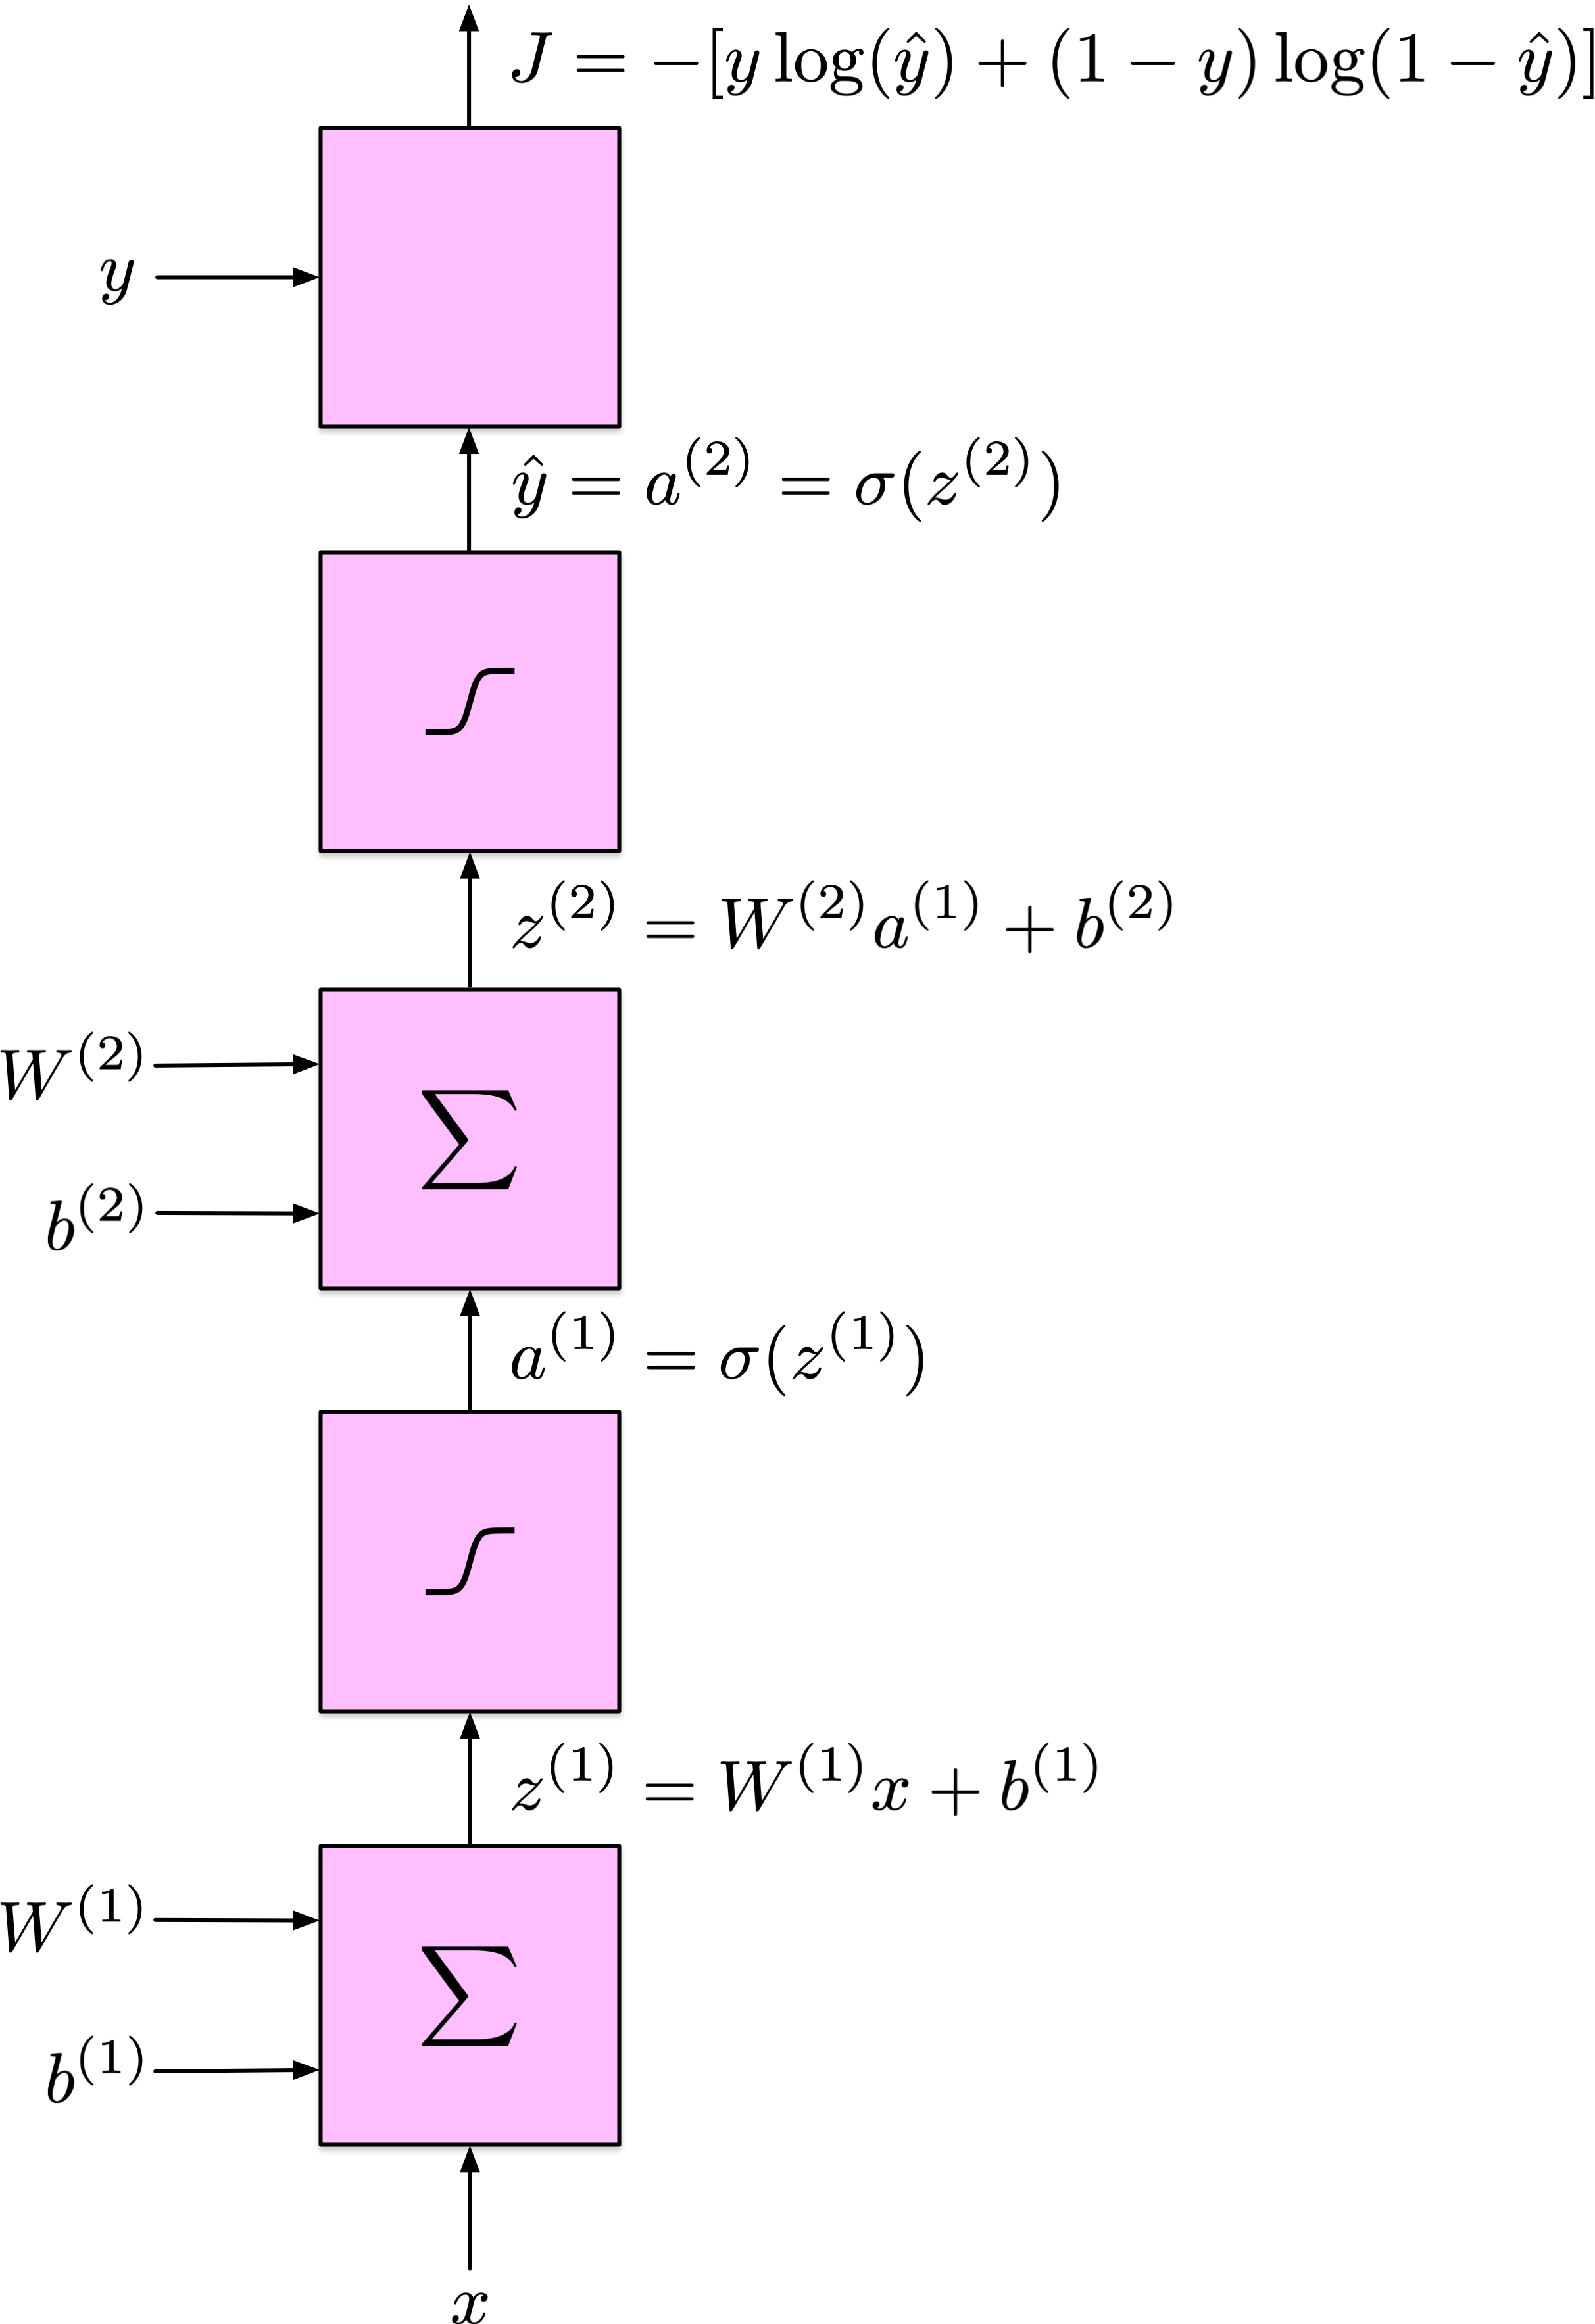

Dans la rétropropagation, le processus progresse de la couche de sortie
vers la couche d’entrée, calculant et **stockant systématiquement les
dérivées partielles intermédiaires**.

Dans notre discussion initiale, nous avons combiné et simplifié les
dérivées partielles. Pour simplifier ce processus, nous pouvons étendre
la règle de la chaîne en multipliant la dérivée locale par la dérivée
partielle pré-calculée qui trace le chemin de la couche de sortie vers
l’unité de traitement locale au sein du graphe de calcul. Cette approche
simplifie non seulement le processus, mais facilite également
l’automatisation.

Dans la présentation, nous avons simplifié le modèle de réseau en
utilisant une seule entrée scalaire et deux unités de traitement,
chacune équipée d’un poids et d’un biais individuels. À des fins de
démonstration, nous avons entraîné ce modèle avec un seul exemple.
L’élargissement du modèle pour inclure des entrées et des nœuds de
traitement supplémentaires transforme les poids ($w$) en matrices et les
biais ($b$) en vecteurs, tandis que la mécanique sous-jacente passe au
calcul vectoriel. De même, l’incorporation de couches supplémentaires
dans le réseau n’augmente pas intrinsèquement la complexité de
l’algorithme. Cela ne fait qu’étendre la boucle de rétropropagation, car
les opérations pour chaque couche restent cohérentes. En fait, notre
représentation du graphe de calcul est déjà exprimée en notation
vectorielle.

## Rétropropagation : à haut niveau

1.  (**Création du Graphe computationnel**)

2.  **Initialisation**

3.  **Passage avant**

4.  **Calcul de la perte**

5.  **Passage arrière (Rétropropagation)**

6.  **Mettre à jour les paramètres et répéter de 3 à 6**.

L’algorithme **s’arrête** soit après un **nombre prédéfini d’époques**,
soit lorsque les **critères de convergence sont satisfaits**.

Les outils modernes comme TensorFlow et PyTorch construisent un graphe
computationnel pour représenter les opérations et le flux de données au
sein d’un réseau de neurones. En revanche, notre implémentation
simplifiée n’utilisera pas cette approche.

## Rétropropagation : détaillé

1.  (Créer le **graphe computationnel**.)

2.  Initialiser les **poids** et **biais**.

3.  **Passage avant :** en partant de l’entrée, calculer la sortie de
    chaque opération dans le graphe et stocker ces valeurs.

4.  **Calculer la perte**.

5.  **Passage arrière :** en partant de la sortie et en revenant en
    arrière, pour chaque opération.

<!-- -->

1.  Calculer la dérivée de la sortie par rapport à chacune des entrées.

2.  Pour chaque entrée $u$,

$$
  \delta_u = \frac{\partial J}{\partial u} = \frac{\partial z}{\partial u} \cdot \frac{\partial J}{\partial z}
$$

1.  **Mettre à jour** les paramètres et **répéter de 3 à 6**.

## Rétropropagation : 2. Initialisation

Initialiser les **poids** et **biais** du réseau de neurones.

1.  **~~Initialisation à zéro~~**
    - Tous les poids sont **initialisés à zéro**.
    - Problèmes de symétrie, **tous les neurones produisent des sorties
      identiques**, empêchant un apprentissage efficace.
2.  **Initialisation aléatoire**
    - Les poids sont initialisés **aléatoirement**, souvent en utilisant
      une distribution **uniforme** ou **normale**.
    - **Brise la symétrie entre les neurones**, leur permettant
      d’apprendre.
    - Si mal échelonné, conduit à une **convergence lente** ou à des
      **gradients qui disparaissent/explosent**.

**Voir aussi** : Initialisation de Xavier/Glorot et He (plus tard)

L’initialisation des poids et biais à zéro fonctionne pour la régression
logistique car c’est un modèle linéaire avec une seule couche. Dans la
régression logistique, le poids de chaque attribut est ajusté
indépendamment pendant l’entraînement, et le processus d’optimisation
peut converger correctement indépendamment des poids initiaux, à
condition que les données soient linéairement séparables.

Cependant, l’initialisation à zéro ne fonctionne pas bien pour les
réseaux de neurones en raison de leur structure à plusieurs couches.
Voici pourquoi :

1.  **Rupture de symétrie** : Les réseaux de neurones nécessitent de
    rompre la symétrie entre les neurones dans chaque couche afin qu’ils
    puissent apprendre différentes caractéristiques. Si tous les poids
    sont initialisés à zéro, chaque neurone d’une couche calculera la
    même sortie et recevra le même gradient lors de la rétropropagation.
    Cela entraîne une mise à jour identique des neurones, les empêchant
    d’apprendre des caractéristiques distinctes et rendant effectivement
    plusieurs neurones redondants.

2.  **Non-linéarité** : Les réseaux de neurones reposent sur des
    transformations non linéaires entre les couches pour modéliser des
    relations complexes dans les données. L’initialisation à zéro inhibe
    la capacité des neurones à s’activer différemment, entravant la
    capacité du réseau à capturer des motifs non linéaires.

## Rétropropagation : 3. Propagation Avant

**Pour chaque exemple** dans le jeu d’entraînement (ou dans un mini-lot)
:

- **Couche d’Entrée** : Transmettre les attributs d’entrée à la première
  couche.

- **Couches Cachées** : Pour chaque couche cachée, calculer les
  **activations** (sortie) en appliquant la **somme pondérée des entrées
  plus le biais**, suivie d’une **fonction d’activation** (par exemple,
  sigmoïde, ReLU).

- **Couche de Sortie** : Même processus que pour les couches cachées.
  Les activations de la couche de sortie représentent les valeurs
  prédites.

La propagation avant est presque identique à l’application du réseau
pour la prédiction (`.predict()`), à l’exception que les résultats
intermédiaires (activation) sont sauvegardés, car ils sont nécessaires
pour la propagation arrière.

En pratique, c’est la version mini-lot de cet algorithme qui est
utilisée.

## Rétropropagation : 4. Calculer la Perte

Calculez la **perte** (**erreur**) en utilisant une fonction de perte
appropriée en comparant les **valeurs prédites** aux **valeurs cibles
réelles**.

Plus d’informations sur les différentes fonctions de perte seront
fournies plus tard : **erreur quadratique moyenne** pour les tâches de
régression ou perte de **log-vraisemblance** pour les tâches de
classification.

Une perte plus faible indique que les valeurs prédites sont plus proches
des valeurs cibles réelles.

La valeur de la fonction de perte peut servir de critère d’arrêt, la
rétropropagation s’arrêtant lorsque la perte est suffisamment petite.

Il est crucial que la dérivée de la fonction de perte fournisse des
informations essentielles pour ajuster les poids et les biais du réseau.

## Rétropropagation : 5. Passage en arrière

- **Couche de sortie** : Calculer le **gradient de la perte** par
  rapport aux **poids** et **biais** de la couche de sortie en utilisant
  la **règle de chaîne du calcul différentiel**.

- **Couches cachées** : **Propager l’erreur en arrière** à travers le
  réseau, **couche par couche**. Pour chaque couche, calculer le
  gradient de la perte par rapport aux poids et biais. Utiliser la
  dérivée de la fonction d’activation pour aider à calculer ces
  gradients.

- **Mettre à jour les poids et biais** : Ajuster les poids et biais en
  utilisant les gradients calculés et un taux d’apprentissage, qui
  détermine la taille de chaque mise à jour.

Des techniques d’optimisation courantes comme la **descente de
gradient** ou ses variantes (par exemple, Adam) sont employées.

À la fin de la présentation, des liens sont fournis vers une série de
vidéos par Herman Kamper. Ces vidéos expliquent les complexités de
l’algorithme de rétropropagation à travers diverses architectures, avec
et sans bifurcations, utilisant des approches de composition de
fonctions et de calcul graphique.

Bien que l’algorithme soit complexe en raison des nombreux cas qu’il
comporte, sa structure régulière le rend adapté à l’automatisation. Plus
précisément, des algorithmes comme la différentiation automatique
(autodiff) facilitent ce processus.

En 1970, [Seppo Ilmari
Linnainmaa](https://en.wikipedia.org/wiki/Seppo_Linnainmaa) a introduit
l’algorithme connu sous le nom de différentiation automatique en mode
inverse dans son mémoire de maîtrise. Bien qu’il n’ait pas appliqué cet
algorithme aux réseaux neuronaux, il est plus général que la
rétropropagation.

## Rétropropagation - Objectif

- Algorithme pour **entraîner les perceptrons multicouches (MLPs)** en
  **minimisant une fonction de perte**.
- Permet aux **couches cachées** d’apprendre des **représentations
  internes utiles** en ajustant les **poids et biais**.

## Rétropropagation - Idée Principale

- Ajuster itérativement les paramètres pour **réduire la différence**
  entre les sorties prédites et réelles.

- Utilise la **descente de gradient** sur la **fonction de perte** :

  $$
  \theta \leftarrow \theta - \alpha \nabla_\theta J(\theta)
  $$

  où $\alpha$ est le taux d’apprentissage.

## Rétropropagation - Résumé

1.  **Créer** le graphe computationnel

2.  **Initialiser** les poids et biais

3.  **Passage avant :** calculer les activations et la perte.

4.  **Passage arrière :** calculer les gradients en utilisant la règle
    de la chaîne.

5.  **Mettre à jour les paramètres :**

    $W^{(\ell)} \leftarrow W^{(\ell)} - \alpha \frac{\partial J}{\partial W^{(\ell)}}$

    $b^{(\ell)} \leftarrow b^{(\ell)} - \alpha \frac{\partial J}{\partial b^{(\ell)}}$

6.  **Répéter** jusqu’à convergence.

# Implémentation

## Rétropropagation - Passage Avant

- Calculer les activations couche par couche :

  $z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)}$,

  $a^{(\ell)} = \phi(z^{(\ell)})$.

- Obtenir la prédiction $\hat{y}$ et calculer la perte $J(\hat{y}, y)$.

## Rétropropagation - Passage Arrière

- Appliquer la **règle de la chaîne** pour calculer les **dérivées
  partielles** de la perte par rapport à chaque paramètre de manière
  efficace.
- Propager les gradients **des couches de sortie vers les couches
  d’entrée** :

$$
     \delta^{(\ell)} = (W^{(\ell+1)} \delta^{(\ell+1)}) \odot \phi'(z^{(\ell)})
$$

Où $\odot$ est le produit élément par élément (de Hadamard).

- $\delta^{(\ell)}$ — le **terme d’erreur** (ou gradient local) pour la
  couche $\ell$, défini comme
  $\displaystyle \delta^{(\ell)} = \frac{\partial J}{\partial z^{(\ell)}}$,
  la sensibilité de la perte $J$ à la préactivation $z^{(\ell)}$.

- $\delta^{(\ell+1)}$ — le **terme d’erreur** de la **couche suivante**
  (plus proche de la sortie). Ceci est déjà connu à partir de l’étape
  précédente dans la rétropropagation.

- $W^{(\ell+1)} \delta^{(\ell+1)}$ — propage l’erreur de la couche
  suivante **en arrière à travers les poids** de la couche $\ell+1$.
  Chaque neurone de la couche $\ell$ reçoit une somme pondérée des
  erreurs en aval.

- $\phi'(z^{(\ell)})$ — la **dérivée de la fonction d’activation** à la
  couche $\ell$. Elle ajuste l’erreur en fonction de la sensibilité de
  l’activation du neurone aux changements de son entrée.

## SimpleMLP

L’implémentation complète est présentée ci-dessous et sera examinée dans
les diapositives suivantes.

In [7]:
import numpy as np

# Activations & perte

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def relu(z):
    return np.maximum(0.0, z)

def relu_prime(z):
    return (z > 0).astype(z.dtype)

def bce_loss(y_true, y_prob, eps=1e-9):

    """Entropie croisée binaire moyennée sur les échantillons (avec découpage pour la stabilité)."""

    y_prob = np.clip(y_prob, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

# Initialisateurs

def he_init(rng, fan_in, fan_out):

    # He normal : bon pour ReLU

    std = np.sqrt(2.0 / fan_in)
    return rng.normal(0.0, std, size=(fan_in, fan_out))

def xavier_init(rng, fan_in, fan_out):

    # Glorot/Xavier normal : bon pour sigmoid/tanh

    std = np.sqrt(2.0 / (fan_in + fan_out))
    return rng.normal(0.0, std, size=(fan_in, fan_out))

# SimpleMLP (API imite NaiveMLP)

class SimpleMLP:

    """
    MLP minimal pour la classification binaire.

    - Caché : ReLU (par défaut) avec He init ; ou 'sigmoid' avec Xavier init
    - Sortie : Sigmoid + BCE (δ_L = a_L - y)
    - API : forward -> probas (N,), predict_proba, predict, loss, train
    """

    def __init__(self, layer_sizes, lr=0.1, seed=None, l2=0.0,
                 hidden_activation="relu", lr_decay=None):
        """
        layer_sizes : par ex., [2, 4, 4, 1]
        lr : taux d'apprentissage
        l2 : force de régularisation L2 (0 désactive)
        hidden_activation : 'relu' (par défaut) ou 'sigmoid'
        lr_decay : flottant optionnel dans (0,1) ; multiplie lr par cela à chaque époque (par ex., 0.9)
        """
        self.sizes = list(layer_sizes)
        self.lr = float(lr)
        self.base_lr = float(lr)
        self.lr_decay = lr_decay
        self.l2 = float(l2)
        self.hidden_activation = hidden_activation
        rng = np.random.default_rng(seed)

        # Initialiser poids/biais par couche
        self.W = []
        for din, dout in zip(self.sizes[:-1], self.sizes[1:]):
            if hidden_activation == "relu":
                Wk = he_init(rng, din, dout)
            else:
                Wk = xavier_init(rng, din, dout)
            self.W.append(Wk)
        self.b = [np.zeros(dout) for dout in self.sizes[1:]]

    # activations (cachée vs sortie)

    def _act(self, z, last=False):
        if last:
            return sigmoid(z)  # couche de sortie
        return relu(z) if self.hidden_activation == "relu" else sigmoid(z)

    def _act_prime(self, z, last=False):
        if last:
            return sigmoid_prime(z)  # rarement nécessaire avec BCE+sigmoid
        return relu_prime(z) if self.hidden_activation == "relu" else sigmoid_prime(z)

    # forward (public) : retourne probabilités (N,)

    def forward(self, X):
        a = X
        L = len(self.W)
        for ell, (W, b) in enumerate(zip(self.W, self.b), start=1):
            a = self._act(a @ W + b, last=(ell == L))
        return a.ravel()

    # Alias pour correspondre à NaiveMLP

    def predict_proba(self, X):
        return self.forward(X)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def loss(self, X, y):

        # BCE + L2 optionnel
        p = self.predict_proba(X)
        base = bce_loss(y, p)
        if self.l2 > 0:
            reg = 0.5 * self.l2 * sum((W**2).sum() for W in self.W)
            # Normaliser reg par le nombre d'échantillons pour être cohérent avec la perte moyenne
            base += reg / max(1, X.shape[0])
        return base

    # interne : forward caches pour rétropropagation

    def _forward_full(self, X):
        a = X
        activations = [a]
        zs = []
        L = len(self.W)
        for ell, (W, b) in enumerate(zip(self.W, self.b), start=1):
            z = a @ W + b
            a = self._act(z, last=(ell == L))
            zs.append(z)
            activations.append(a)
        return activations, zs

    # entraînement : descente de gradient par mini-lots avec rétropropagation

    def train(self, X, y, epochs=30, batch_size=None, verbose=True, shuffle=True):

        """
        X : (N, d), y : (N,) dans {0,1}
        batch_size : None -> lot complet ; sinon int
        """

        N = X.shape[0]
        idx = np.arange(N)
        B = N if batch_size is None else int(batch_size)

        for ep in range(1, epochs + 1):
            if shuffle:
                np.random.shuffle(idx)
            if self.lr_decay:
                self.lr = self.base_lr * (self.lr_decay ** (ep - 1))

            base_loss = self.loss(X, y)

            for start in range(0, N, B):
                sl = idx[start:start+B]
                Xb = X[sl]
                yb = y[sl].reshape(-1, 1)  # (B,1)

                # Forward caches
                activations, zs = self._forward_full(Xb)
                A_L = activations[-1]          # (B,1)
                Bsz = Xb.shape[0]

                # Rétropropagation
                # Couche de sortie : BCE + sigmoid => delta_L = (A_L - y)

                delta = (A_L - yb)             # (B,1)

                grads_W = [None] * len(self.W)
                grads_b = [None] * len(self.b)

                # Gradients de la dernière couche

                grads_W[-1] = activations[-2].T @ delta / Bsz   # (n_{L-1}, 1)
                grads_b[-1] = delta.mean(axis=0)                # (1,)

                # Couches cachées : l = L-1 à 1

                for l in range(2, len(self.sizes)):
                    z = zs[-l]                                  # (B, n_l)
                    sp = self._act_prime(z, last=False)         # (B, n_l)
                    delta = (delta @ self.W[-l+1].T) * sp       # (B, n_l)
                    grads_W[-l] = activations[-l-1].T @ delta / Bsz  # (n_{l-1}, n_l)
                    grads_b[-l] = delta.mean(axis=0)                 # (n_l,)

                # Régularisation L2 (ajouter aux gradients)

                if self.l2 > 0:
                    for k in range(len(self.W)):
                        grads_W[k] = grads_W[k] + self.l2 * self.W[k]

                # Étape de gradient

                for k in range(len(self.W)):
                    self.W[k] -= self.lr * grads_W[k]
                    self.b[k] -= self.lr * grads_b[k]

            new_loss = self.loss(X, y)
            if verbose:
                print(f"Époque {ep:3d} | perte {base_loss:.5f} → {new_loss:.5f} | Δ={base_loss - new_loss:.5f} | lr={self.lr:.4f}")

## Fonctions d’activation

In [8]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_prime(z):
    s = sigmoid(z)
    return s * (1.0 - s)

def relu(z):
    return np.maximum(0.0, z)

def relu_prime(z):
    return (z > 0).astype(z.dtype)

Comme indiqué dans un cours précédent, la dérivée de la fonction
sigmoïde s’exprime commodément comme le produit de la fonction sigmoïde
elle-même et de un moins la fonction sigmoïde.

Nous incluons également ReLU.

## Perte

In [9]:
def bce_loss(y_true, y_prob, eps=1e-9):

    """Entropie croisée binaire moyenne sur les échantillons (avec découpage pour la stabilité)."""

    y_prob = np.clip(y_prob, eps, 1 - eps)

    return -np.mean(y_true * np.log(y_prob) + (1 - y_true) * np.log(1 - y_prob))

## Initialisateurs

In [10]:
def he_init(rng, fan_in, fan_out):

    # He normal : bon pour ReLU

    std = np.sqrt(2.0 / fan_in)
    return rng.normal(0.0, std, size=(fan_in, fan_out))

def xavier_init(rng, fan_in, fan_out):

    # Glorot/Xavier normal : bon pour sigmoid/tanh

    std = np.sqrt(2.0 / (fan_in + fan_out))
    return rng.normal(0.0, std, size=(fan_in, fan_out))

Dans le prochain cours, nous explorerons le problème du gradient
évanescent, un défi commun rencontré dans les réseaux neuronaux
profonds. Une approche pour atténuer ce problème consiste à modifier les
fonctions d’activation et à ajuster les méthodes d’initialisation des
poids.

## Définition de classe + constructeur

In [11]:
class SimpleMLP:

    def __init__(self, layer_sizes, lr=0.1, seed=None, l2=0.0,
                 hidden_activation="relu", lr_decay=None):

        self.sizes = list(layer_sizes)
        self.lr = float(lr)
        self.base_lr = float(lr)
        self.lr_decay = lr_decay
        self.l2 = float(l2)
        self.hidden_activation = hidden_activation
        rng = np.random.default_rng(seed)

        # Initialiser les poids/biais par couche
        self.W = []
        for din, dout in zip(self.sizes[:-1], self.sizes[1:]):
            if hidden_activation == "relu":
                Wk = he_init(rng, din, dout)
            else:
                Wk = xavier_init(rng, din, dout)
            self.W.append(Wk)
        self.b = [np.zeros(dout) for dout in self.sizes[1:]]

Le constructeur est similaire à celui de `NaiveMLP`, avec la différence
majeure qu’il conserve un taux d’apprentissage plutôt qu’une valeur de
pas. De plus, l’initialisation des poids varie en fonction des fonctions
d’activation spécifiques utilisées.

## Forward (public)

In [12]:
    def forward(self, X):
        a = X
        L = len(self.W)
        for ell, (W, b) in enumerate(zip(self.W, self.b), start=1):
            a = self._act(a @ W + b, last=(ell == L))
        return a.ravel()

. . .

où `_act` est défini comme suit :

In [13]:
    def _act(self, z, last=False):
        if last:
            return sigmoid(z)  # output layer
        return relu(z) if self.hidden_activation == "relu" else sigmoid(z)

Le modèle `SimpleMLP` intègre deux implémentations distinctes de la
méthode `forward` : l’une adaptée aux tâches de prédiction et l’autre
pour l’entraînement du modèle.

## Forward (privé)

In [14]:
    def _forward_full(self, X):
        a = X
        activations = [a]
        zs = []
        L = len(self.W)
        for ell, (W, b) in enumerate(zip(self.W, self.b), start=1):
            z = a @ W + b
            a = self._act(z, last=(ell == L))
            zs.append(z)
            activations.append(a)
        return activations, zs

La méthode privée `forward` diffère en ce qu’elle conserve à la fois les
valeurs de préactivation (`zs`) et les valeurs d’activation
(`activations`). Cette conservation est importante, car ces valeurs sont
nécessaires lors de la phase de rétropropagation.

## Entraînement

In [15]:
    def train(self, X, y, epochs=30, batch_size=None, verbose=True, shuffle=True):

        """
        X: (N, d), y: (N,) dans {0,1}
        batch_size: None -> plein lot; sinon int
        """

        N = X.shape[0]
        idx = np.arange(N)
        B = N if batch_size is None else int(batch_size)

        for ep in range(1, epochs + 1):
            if shuffle:
                np.random.shuffle(idx)
            if self.lr_decay:
                self.lr = self.base_lr * (self.lr_decay ** (ep - 1))

            base_loss = self.loss(X, y)

            for start in range(0, N, B):
                sl = idx[start:start+B]
                Xb = X[sl]
                yb = y[sl].reshape(-1, 1)  # (B,1)

                # Caches avant
                activations, zs = self._forward_full(Xb)
                A_L = activations[-1]          # (B,1)
                Bsz = Xb.shape[0]

                # Rétropropagation
                # Couche de sortie : BCE + sigmoïde => delta_L = (A_L - y)

                delta = (A_L - yb)             # (B,1)

                grads_W = [None] * len(self.W)
                grads_b = [None] * len(self.b)

                # Gradients de la dernière couche

                grads_W[-1] = activations[-2].T @ delta / Bsz   # (n_{L-1}, 1)
                grads_b[-1] = delta.mean(axis=0)                # (1,)

                # Couches cachées : l = L-1 jusqu'à 1

                for l in range(2, len(self.sizes)):
                    z = zs[-l]                                  # (B, n_l)
                    sp = self._act_prime(z, last=False)         # (B, n_l)
                    delta = (delta @ self.W[-l+1].T) * sp       # (B, n_l)
                    grads_W[-l] = activations[-l-1].T @ delta / Bsz  # (n_{l-1}, n_l)
                    grads_b[-l] = delta.mean(axis=0)                 # (n_l,)

                # Régularisation L2 (ajouter aux gradients)

                if self.l2 > 0:
                    for k in range(len(self.W)):
                        grads_W[k] = grads_W[k] + self.l2 * self.W[k]

                # Étape de gradient

                for k in range(len(self.W)):
                    self.W[k] -= self.lr * grads_W[k]
                    self.b[k] -= self.lr * grads_b[k]

            new_loss = self.loss(X, y)
            if verbose:
                print(f"Époque {ep:3d} | perte {base_loss:.5f} → {new_loss:.5f} | Δ={base_loss - new_loss:.5f} | lr={self.lr:.4f}")

Notre implémentation réplique avec succès plusieurs caractéristiques
clés des cadres contemporains. Elle offre des options pour définir la
taille de lot et décider s’il faut mélanger les données.

En général, vous devriez mélanger les données avant (et généralement au
début de chaque époque pendant) l’entraînement du réseau de neurones.

1.  **Brise le biais d’ordre :** Si le jeu de données a un ordre
    sous-jacent (par exemple, trié par classe, temps ou difficulté),
    l’entraînement séquentiel pourrait amener le modèle à surapprendre
    les premiers lots et à mal généraliser.

2.  **Améliore la stochasticité :** Le mélange garantit que chaque
    mini-lot fournit un mélange représentatif de la distribution des
    données, stabilisant les mises à jour de la descente de gradient
    stochastique (SGD) et améliorant la convergence.

3.  **Prévient les motifs périodiques :** Sans mélange, l’optimiseur
    pourrait voir des échantillons similaires de manière répétée dans le
    même ordre, conduisant à des oscillations ou à une convergence plus
    lente.

**Exception :**

- **Données temporelles ou séquentielles :**

  Si l’ordre a une signification (structure temporelle ou causale), **ne
  pas** mélanger au travers du temps.

Notre méthode intègre un programme d’entraînement dynamique qui réduit
progressivement le taux d’apprentissage à mesure que le nombre d’époques
d’entraînement augmente.

## Test

In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X, y = make_circles(n_samples=200, factor=0.5, noise=0.08, random_state=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SimpleMLP([2, 4, 4, 1], lr=0.3, seed=42, hidden_activation="relu", l2=0.0, lr_decay=0.95)

model.train(X_train, y_train, epochs=150, batch_size=32, verbose=False)

print("Exactitude de l'entraînement :", accuracy_score(y_train, model.predict(X_train)))
print("Exactitude du test :", accuracy_score(y_test, model.predict(X_test)))

Exactitude de l'entraînement : 0.9428571428571428
Exactitude du test : 0.9166666666666666

## Différentiation automatique

**La différentiation automatique (autodiff)** applique systématiquement
la règle de la chaîne pour calculer des dérivées exactes des fonctions
exprimées sous forme de programmes informatiques. Elle propage les
dérivées à travers des opérations élémentaires, soit en avant (des
entrées vers les sorties) soit en arrière (des sorties vers les
entrées), permettant un calcul de gradient efficace et précis essentiel
pour les algorithmes d’optimisation et d’apprentissage.

Baydin et al. (2017)

# Entraînement

## Gradients évanescents

- **Problème de gradient évanescent**: Les gradients deviennent trop
  petits, **entravant la mise à jour des poids**.

- La recherche sur les réseaux neuronaux a **stagné** (à nouveau) au
  début des années 2000.

- **Sigmoïde** et sa dérivée (plage : 0 à 0,25) étaient des facteurs
  clés.

- **Initialisation courante**: Poids/biais issus de $\mathcal{N}(0, 1)$
  ont contribué au problème.

Glorot et Bengio (2010) a mis en lumière les problèmes.

Le problème de gradient évanescent survient souvent avec des fonctions
d’activation comme la sigmoïde et la tangente hyperbolique (tanh),
entraînant des difficultés dans l’entraînement des réseaux neuronaux
profonds en raison de gradients qui diminuent, ralentissant ainsi
l’apprentissage.

En revanche, le problème de gradient explosif, qui implique des
gradients devenant excessivement grands, est généralement observé dans
des architectures comme les réseaux neuronaux récurrents (RNNs).

Les deux problèmes peuvent affecter de manière significative la
stabilité et la convergence des techniques d’optimisation basées sur le
gradient, entravant ainsi l’entraînement efficace des modèles profonds.

## Gradients évanescents : solutions

- **Fonctions d’activation alternatives** : Unité Linéaire Rectifiée
  (**ReLU**) et ses variantes (par exemple, **Leaky ReLU**, **Parametric
  ReLU**, et **Exponential Linear Unit**).

- **Initialisation des poids** : Initialisation Xavier (Glorot) ou He.

D’autres techniques existent pour atténuer le problème, y compris
celles-ci :

- **Normalisation par lots** : Implémentez la normalisation par lots
  pour standardiser les entrées de chaque couche, ce qui peut aider à
  stabiliser et accélérer l’entraînement en réduisant le décalage
  covariant interne et en maintenant un flux de gradients efficace.

- **Réseaux Résiduels** : Utilisez des connexions résiduelles, comme on
  le voit dans les architectures ResNet, qui permettent aux gradients de
  circuler plus facilement à travers le réseau en fournissant des
  chemins de contournement qui passent outre une ou plusieurs couches.

## Glorot et Bengio

Figure 6

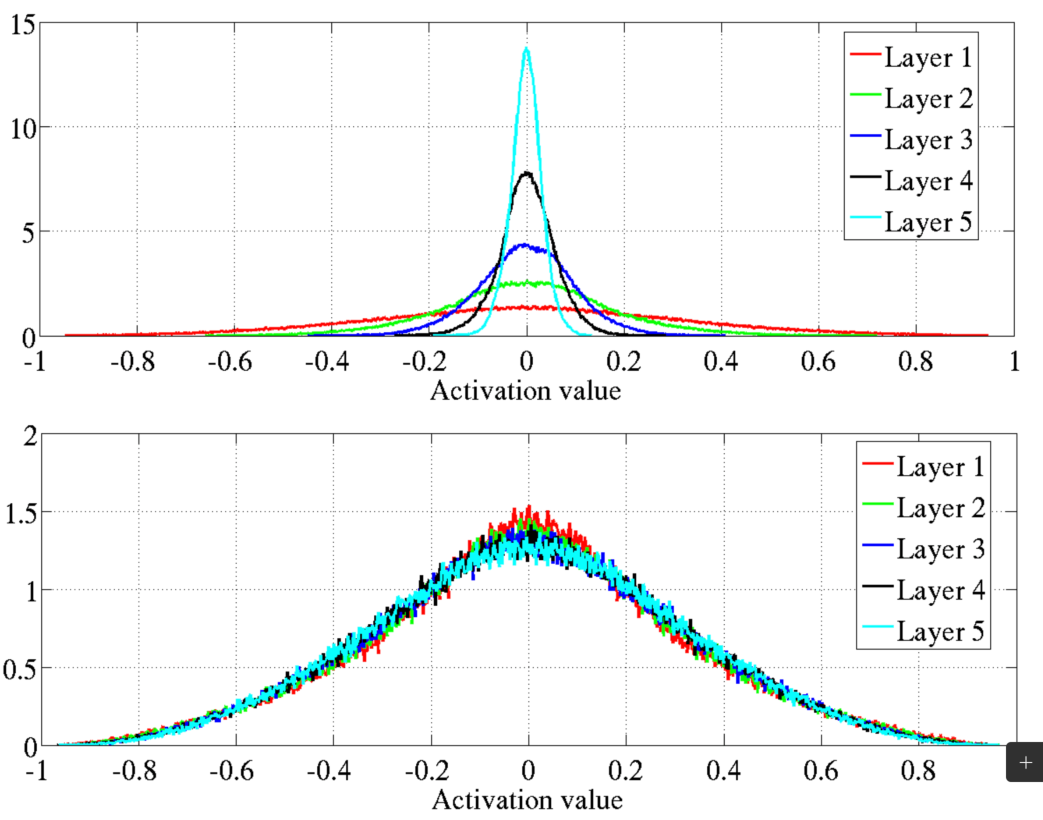

Figure 7

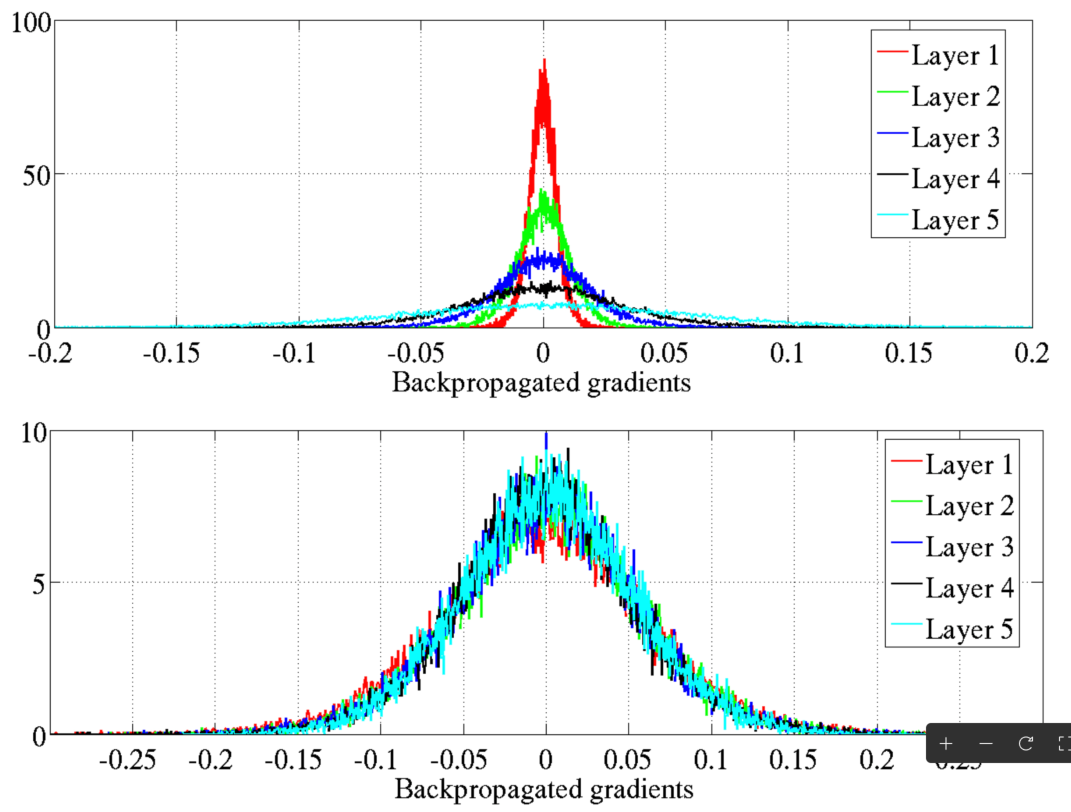

Glorot et Bengio (2010), page 254.

Les graphiques présentés illustrent les histogrammes normalisés des
valeurs d’activation et des gradients rétropropagés associés à la
fonction d’activation tangente hyperbolique.

Pour produire les diagrammes du haut, Glorot et Bengio ont utilisé une
méthode d’initialisation qui était populaire à l’époque, tandis que les
diagrammes du bas ont été produits en utilisant un nouveau schéma
(Glorot).

Dans Glorot & Bengio (2010), les couches sont numérotées de l’entrée
(couche 1) à la sortie (couche L).

Donc :

- Couches initiales = proches de l’entrée.
- Couches ultérieures = proches de la sortie.

Les figures 6 et 7 présentent des histogrammes représentant les valeurs
d’activation et les valeurs de gradient, respectivement, pour chaque
couche.

- **Activations :**

  Dans les réseaux souffrant du *problème de gradient évanescent*, les
  activations ont tendance à **diminuer** lorsque l’on passe de l’entrée
  à la sortie — c’est-à-dire une moyenne et une variance plus faibles
  dans les couches plus profondes. Plus on va en profondeur, plus le
  signal devient “plat”.

- **Gradients :**

  Inversement, les **gradients s’évanouissent** lorsque l’on passe de la
  couche de sortie vers l’entrée. Petits gradients dans les couches
  initiales (côté entrée), un peu plus grands près de la sortie.

Donc :

- Activations faibles en profondeur dans le réseau.
- Gradients faibles *vers l’entrée*.

Les principales contributions et messages de Glorot & Bengio :

1.  **Cause racine identifiée :**

    Ils ont analysé comment la *variance* des activations et des
    gradients évolue à travers les couches, montrant qu’une mauvaise
    initialisation cause le signal (à la fois en avant et en arrière) à
    soit s’évanouir, soit exploser exponentiellement avec la profondeur.

2.  **Condition analytique :**

    Pour un entraînement stable, la **variance des activations et des
    gradients** devrait rester à peu près constante à travers les
    couches.

    Cela a conduit à l’**initialisation Xavier** (maintenant standard) :

$$
   \text{Var}(W) = \frac{2}{n_\text{in} + n_\text{out}}
$$

qui maintient la variance du signal équilibrée dans les deux sens.

1.  **Vérification empirique :**

    Les figures 6 et 7 démontrent comment une mauvaise initialisation
    (par exemple, trop petite ou trop grande) cause des activations et
    des gradients évanescents/explosifs, tandis que l’initialisation
    Xavier les maintient stables.

2.  **Message plus large :**

    Le succès de l’apprentissage profond dépend crucialement de :

    - Une **initialisation des poids** appropriée (maintien du flux de
      signal).
    - Des **fonctions d’activation** appropriées (par exemple sigmoid vs
      tanh vs ReLU).
    - Un **équilibrage** adéquat des activations et des gradients lors
      des passages avant et arrière.

**Gradient évanescent**

- **Mécanisme :**

  Dans les réseaux profonds avec des non-linéarités saturantes (comme
  sigmoid/tanh), la rétropropagation multiplie de nombreuses petites
  dérivées (\<1), causant des gradients exponentiellement plus petits
  dans les couches antérieures.

- **Effet :**

  Les couches initiales apprennent très lentement, effectivement
  “gelées” — tandis que les couches ultérieures (plus proches de la
  sortie) continuent de s’adapter.

- **Solutions :**

  - Initialisation Xavier ou He (préservation de la variance).
  - Activations non saturantes (famille ReLU).

## Glorot et Bengio

**Objectif :** Atténuer le problème des gradients instables dans les
réseaux neuronaux profonds.

**Flux de signal :**

- **Direction avant :** Assurer une propagation stable du signal pour
  des prédictions précises.
- **Direction arrière :** Maintenir un flux de gradient constant pendant
  la rétropropagation.

Glorot et Bengio (2010) : faites attention au flux de signal dans les
deux directions !

## Glorot et Bengio

**Ajustement de la variance :**

- **Passage avant :** Assurer que la variance de la sortie de chaque
  couche correspond à sa variance d’entrée.

- **Passage arrière :** Maintenir une variance de gradient égale avant
  et après le passage dans chaque couche.

Keras utilise par défaut l’initialisation de Glorot, qui convient bien
aux fonctions d’activation telles que **sigmoïde**, **tanh** et
**softmax**.

## Initialisation He

Une méthode d’initialisation similaire mais légèrement différente conçue
pour fonctionner avec **ReLU**, ainsi que **Leaky ReLU**, **ELU**,
**GELU**, **Swish**, et **Mish**.

. . .

Assurez-vous que la méthode d’initialisation **correspond** à la
fonction d’activation choisie.

In [17]:
import tensorflow as tf
from tensorflow.python.keras.layers import Dense

dense = Dense(50, activation="relu", kernel_initializer="he_normal")

Aussi connu sous le nom d’initialisation Kaiming.

- **Initialisation Glorot (Initialisation Xavier) :** Cette méthode
  définit les poids initiaux en fonction du nombre d’unités d’entrée et
  de sortie pour chaque couche, visant à maintenir la variance des
  activations cohérente à travers les couches. Elle est particulièrement
  efficace pour les fonctions d’activation comme sigmoïde et tanh.

- **Initialisation He :** Cette approche ajuste l’initialisation des
  poids pour être adaptée aux couches utilisant ReLU et ses variantes,
  en adaptant la variance uniquement en fonction du nombre d’unités
  d’entrée.

## Remarque

L’initialisation aléatoire des poids[1] est suffisante pour **briser la
symétrie** dans un réseau de neurones, **permettant ainsi que les termes
de biais soient fixés à zéro** sans nuire à la capacité d’apprentissage
du réseau.

## Fonction d’Activation : Leaky ReLU

[1] Une bonne initialisation des poids, comme l’utilisation de
l’initialisation Xavier/Glorot ou He, est essentielle et doit être
alignée avec le choix de la fonction d’activation pour assurer des
performances optimales du réseau.

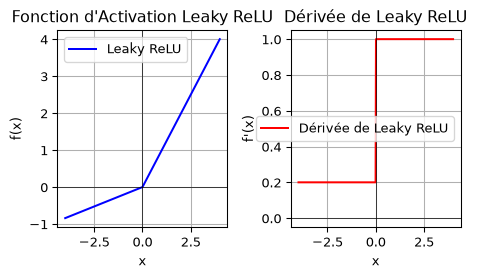

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Définir la fonction Leaky ReLU
def leaky_relu(x, alpha=0.21):
    return np.where(x > 0, x, alpha * x)

# Définir la dérivée de la fonction Leaky ReLU
def leaky_relu_derivative(x, alpha=0.2):
    return np.where(x > 0, 1, alpha)

# Générer une gamme de valeurs d'entrée
x_values = np.linspace(-4, 4, 400)

# Calculer le Leaky ReLU et sa dérivée
leaky_relu_values = leaky_relu(x_values)
leaky_relu_derivative_values = leaky_relu_derivative(x_values)

# Créer le graphique
plt.figure(figsize=(5, 3))

# Tracer le Leaky ReLU
plt.subplot(1, 2, 1)
plt.plot(x_values, leaky_relu_values, label='Leaky ReLU', color='blue')
plt.title('Fonction d\'Activation Leaky ReLU')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()

# Tracer la dérivée du Leaky ReLU
plt.subplot(1, 2, 2)
plt.plot(x_values, leaky_relu_derivative_values, label='Dérivée de Leaky ReLU', color='red')
plt.title('Dérivée de Leaky ReLU')
plt.xlabel('x')
plt.ylabel("f'(x)")
plt.grid(True)
plt.axhline(0, color='black',linewidth=0.5)
plt.axvline(0, color='black',linewidth=0.5)
plt.legend()

# Afficher les graphiques
plt.tight_layout()
plt.show()

Le Leaky ReLU, une variante de la fonction d’activation ReLU standard,
atténue efficacement le problème des *neurones ReLU morts*. Pour les
valeurs d’entrée négatives, il introduit une composante linéaire avec
une pente gouvernée par le paramètre `negative_slope`.

Lorsque l’entrée de la fonction d’activation ReLU, la somme pondérée
plus le biais, est négative pour tous les exemples d’entraînement, la
valeur de sortie de ReLU est zéro. De plus, sa dérivée est 0, ce qui
désactive effectivement le neurone. Le Leaky ReLU, ou d’autres
variantes, atténue efficacement ce problème.

``` python
import tensorflow as tf
from tensorflow.python.keras.layers import Dense

leaky_relu = tf.keras.layers.LeakyReLU(negative_slope=0.2)
dense = tf.keras.layers.Dense(50, activation=leaky_relu, kernel_initializer="he_normal")
```

Keras propose 18 [fonctions d’activation des
couches](https://keras.io/api/layers/activations/#available-activations)
au moment de la rédaction.

# Prologue

## Résumé

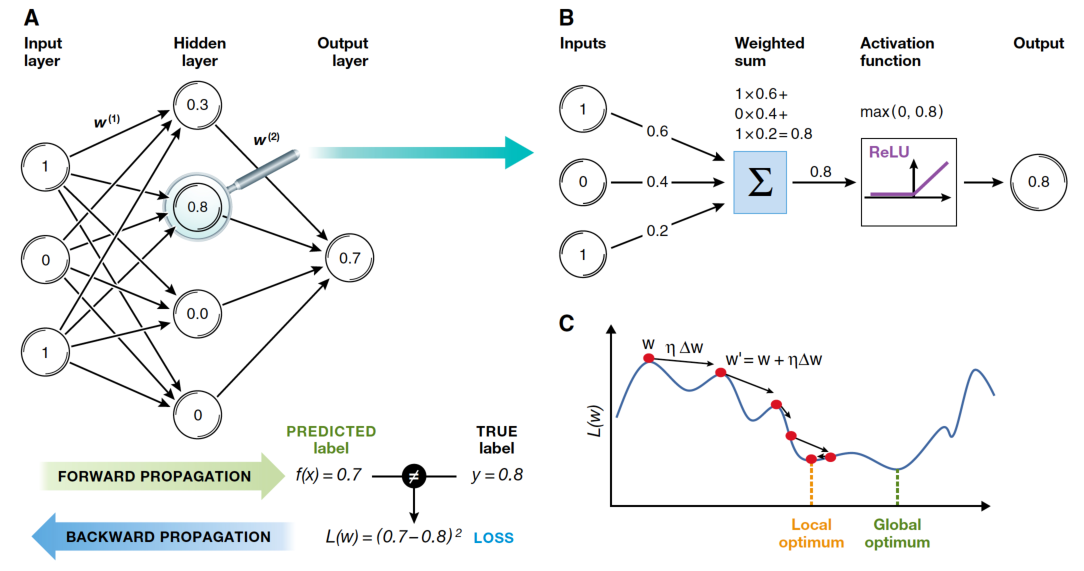

**Attribution**: Angermueller et al. (2016)

## Résumé

| Concept | Rôle |
|-----------------------|-------------------------------------------------|
| **Fonctions d’activation** | Introduisent la non-linéarité (par exemple, Sigmoïde, ReLU). |
| **Fonction de perte** | Mesure l’erreur de prédiction (par exemple, Entropie Croisée Binaire). |
| **Taux d’apprentissage (α)** | Contrôle la taille des pas dans les mises à jour des paramètres. |
| **Descente de gradient** | Méthode d’optimisation pour l’ajustement des poids. |
| **Règle de chaîne** | Mécanisme pour propager les dérivées en arrière. |
| **Différentiation automatique** | Implémentation logicielle de la rétropropagation (par exemple, TensorFlow, PyTorch). |

## Résumé

- **Réseaux neuronaux artificiels (ANNs)** :
  - Inspirés des réseaux neuronaux biologiques.
  - Composés de neurones interconnectés organisés en couches.
  - Applicables à l’apprentissage supervisé, non supervisé, et par
    renforcement.
- **Réseaux neuronaux à propagation directe (FNNs)** :
  - L’information circule unidirectionnellement de l’entrée à la sortie.
  - Composés de couches d’entrée, cachées et de sortie.
  - Le nombre de couches et de neurones par couche peut varier.
- **Fonctions d’activation** :
  - Introduisent de la non-linéarité pour permettre l’apprentissage de
    modèles complexes.
  - Fonctions courantes : Sigmoid, Tanh, ReLU, Leaky ReLU.
  - Le choix de la fonction d’activation affecte le flux de gradient et
    les performances du réseau.
- **Théorème de l’approximation universelle** :
  - Un réseau neuronal avec une seule couche cachée peut approximer
    toute fonction continue.
- **Algorithme de rétropropagation** :
  - L’entraînement implique une passe avant, un calcul de perte, une
    passe arrière et une mise à jour des poids.
  - Utilise la descente de gradient pour minimiser la fonction de perte.
  - Permet l’entraînement des perceptrons multicouches en ajustant les
    poids internes.
- **Problème du gradient qui disparaît** :
  - Les gradients deviennent trop petits lors de la rétropropagation, ce
    qui freine l’entraînement.
  - Stratégies de mitigation : utilisation de fonctions d’activation
    ReLU et d’une initialisation correcte des poids (Glorot ou He).
- **Initialisation des poids** :
  - L’initialisation aléatoire brise la symétrie et permet un
    apprentissage efficace.
  - L’initialisation Glorot convient aux activations sigmoid et tanh.
  - L’initialisation He est optimale pour ReLU et ses variantes.

## 3Blue1Brown

Une série de vidéos, avec animations, fournissant l’**intuition**
derrière l’**algorithme de rétropropagation**.

- [Réseaux
  neuronaux](https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi)
  (playlist)

  - [Que fait vraiment la rétropropagation
    ?](https://www.youtube.com/watch?v=Ilg3gGewQ5U&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=3&t=212s)
    (12m 47s)
  - [Calculus de la
    rétropropagation](https://www.youtube.com/watch?v=tIeHLnjs5U8&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=4)
    (10m 18s)

Prérequis : [Descente de gradient, comment les réseaux neuronaux
apprennent-ils
?](https://www.youtube.com/watch?v=IHZwWFHWa-w&list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi&index=2)
(20m 33s)

## StatQuest

- [Réseaux Neuronaux Pt. 2 : Idées principales de la
  rétropropagation](https://youtu.be/IN2XmBhILt4) (17m 34s)
- [Détails de la rétropropagation Pt. 1 : Optimisation de 3 paramètres
  simultanément](https://youtu.be/iyn2zdALii8) (18m 32s)
- [Détails de la rétropropagation Pt. 2 : S’amuser avec la règle de
  chaîne](https://youtu.be/GKZoOHXGcLo) (13m 9s)

Prérequis : [La règle de chaîne](https://youtu.be/wl1myxrtQHQ) (18m 24s)
& [Descente de Gradient, étape par étape](https://youtu.be/sDv4f4s2SB8)
(23m 54s)

## Herman Kamper

Une des séries de **vidéos** les plus complètes sur l’**algorithme de
rétropropagation**.

- [Introduction aux réseaux
  neuronaux](https://www.youtube.com/playlist?list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn)
  (playlist)

  - [Rétropropagation (sans
    fourches)](https://www.youtube.com/watch?v=6SW1oUztmzg&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=7&t=680s)
    (31m 1s)
  - [Rétropropagation pour un réseau neuronal à propagation avant
    multicouche](https://www.youtube.com/watch?v=dTupaVdrz1k&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=8)
    (4m 2s)
  - [Graphes computationnels et différentiation automatique pour les
    réseaux
    neuronaux](https://www.youtube.com/watch?v=fBSm5ElvJEg&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=9)
    (6m 56s)
  - [Dérivées communes pour les réseaux
    neuronaux](https://www.youtube.com/watch?v=aqnjXWxiT0o&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=10)
    (7m 18s)
  - [Une notation générale pour les dérivées (dans les réseaux
    neuronaux)](https://www.youtube.com/watch?v=Sa5_Gl_sYoI&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=11)
    (7m 56s)
  - [Fourches dans les réseaux
    neuronaux](https://www.youtube.com/watch?v=6mmEw738MQo&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=12)
    (13m 46s)
  - [Rétropropagation en général (maintenant avec des
    fourches)](https://www.youtube.com/watch?v=aRkhgm2i4p0&list=PLmZlBIcArwhMHnIrNu70mlvZOwe6MqWYn&index=13)
    (3m 42s)

## Livre gratuit avec implémentation

Dans son livre, [*Neural Networks and Deep
Learning*](http://neuralnetworksanddeeplearning.com/index.html), Michael
Nielsen fournit une implémentation complète d’un réseau neuronal en
Python.

## Prochaine leçon

- Nous introduirons différentes architectures de réseaux neuronaux
  artificiels.

## Références

Angermueller, Christof, Tanel Pärnamaa, Leopold Parts, et Oliver Stegle.
2016. « Deep learning for computational biology ». *Mol Syst Biol* 12
(7): 878. <https://doi.org/10.15252/msb.20156651>.

Baydin, Atılım Günes, Barak A. Pearlmutter, Alexey Andreyevich Radul, et
Jeffrey Mark Siskind. 2017. « Automatic differentiation in machine
learning: a survey ». *J. Mach. Learn. Res.* 18 (1): 5595‑637.

Glorot, Xavier, et Yoshua Bengio. 2010. « Understanding the difficulty
of training deep feedforward neural networks ». In *Proceedings of the
Thirteenth International Conference on Artificial Intelligence and
Statistics*, édité par Yee Whye Teh et Mike Titterington, vol. 9.
Proceedings of Machine Learning Research. PMLR.
<https://proceedings.mlr.press/v9/glorot10a.html>.

Rumelhart, David E., Geoffrey E. Hinton, et Ronald J. Williams. 1986.
« Learning representations by back-propagating errors ». *Nature* 323
(6088): 533‑36. <https://doi.org/10.1038/323533a0>.

Russell, Stuart, et Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4ᵉ éd. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

École de **science informatique** et de génie électrique (**SI**GE)

Université d’Ottawa